In [45]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from IPython.display import Image, display
from matplotlib.colors import LogNorm

import gc
import itertools
import hist

plt.rcParams['font.size'] = 16

```python
"""
Paths:
Chunk0950                    /Chunk0950/001_007/AO2Dtree.root
Chunk1000                    [ /Chunk1000/001_005/AO2Dtree.root, /Chunk1000/006_009/AO2Dtree.root ]
Chunk1010                    [ /Chunk1010/001_005/AO2Dtree.root, /Chunk1010/006_010/AO2Dtree.root ]
Chunk1020                    /Chunk1020/001_007/AO2Dtree.root
Chunk1030                    [ /Chunk1030/001_005/AO2Dtree.root, /Chunk1030/006_011/AO2Dtree.root ]
Chunk1040                    /Chunk1040/001_007/AO2Dtree.root
Chunk1050                    [ /Chunk1050/001_005/AO2Dtree.root, /Chunk1050/006_010/AO2Dtree.root ]
Chunk1100                    [ /Chunk1100/001_005/AO2Dtree.root, /Chunk1100/006_009/AO2Dtree.root ]
Chunk1110                    /Chunk1110/001_005/AO2Dtree.root
Chunk1120                    [ /Chunk1120/001_005/AO2Dtree.root, /Chunk1120/006_011/AO2Dtree.root ]
Chunk1130                    /Chunk1130/001_008/AO2Dtree.root
Chunk1140                    [ /Chunk1140/001_006/AO2Dtree.root, /Chunk1120/007_011/AO2Dtree.root ]
Chunk1150                    /Chunk1150/001_007/AO2Dtree.root
Chunk1200                    [ /Chunk1200/001_006/AO2Dtree.root, /Chunk1120/007_011/AO2Dtree.root ]
Chunk1210                    /Chunk1210/001_008/AO2Dtree.root
Chunk1220                    /Chunk1220/001_008/AO2Dtree.root
Chunk1300                    [ /Chunk1300/001_006/AO2Dtree.root, /Chunk1300/003/AO2Dtree.root, /Chunk1300/007_010/AO2Dtree.root ]
"""
```

In [3]:
#base_path = "../../mnt/SingleTrackTrees/Data/alice_data_2023_LHC23f_535087_apass4_1300_Thinner/Output/Run535087"
base_path = "~/Downloads"
which_chunk = "Chunk0950"
which_number = "001_007"
which_file = "AO2Dtree.root"
path = base_path + "/".join(["/", which_chunk, which_number, which_file])
#path = "~/Downloads/AO2Dtree.root"
file = uproot.open(path)
results = uproot.open(base_path + "/".join(["/", which_chunk, which_number, "AnalysisResults.root"]))

### Odd stuff

In [3]:
results.classnames()

{'bc-selection-task;1': 'TDirectory',
 'bc-selection-task/hCounterTVX;1': 'TH1D',
 'bc-selection-task/hCounterTCE;1': 'TH1D',
 'bc-selection-task/hCounterZEM;1': 'TH1D',
 'bc-selection-task/hCounterZNC;1': 'TH1D',
 'bc-selection-task/hCounterTVXafterBCcuts;1': 'TH1D',
 'bc-selection-task/hCounterTCEafterBCcuts;1': 'TH1D',
 'bc-selection-task/hCounterZEMafterBCcuts;1': 'TH1D',
 'bc-selection-task/hCounterZNCafterBCcuts;1': 'TH1D',
 'bc-selection-task/hCounterInvalidBCTimestamp;1': 'TH1D',
 'bc-selection-task/hLumiTVX;1': 'TH1D',
 'bc-selection-task/hLumiTCE;1': 'TH1D',
 'bc-selection-task/hLumiZEM;1': 'TH1D',
 'bc-selection-task/hLumiZNC;1': 'TH1D',
 'bc-selection-task/hLumiTVXafterBCcuts;1': 'TH1D',
 'bc-selection-task/hLumiTCEafterBCcuts;1': 'TH1D',
 'bc-selection-task/hLumiZEMafterBCcuts;1': 'TH1D',
 'bc-selection-task/hLumiZNCafterBCcuts;1': 'TH1D',
 'event-selection-task;1': 'TDirectory',
 'event-selection-task/hColCounterAll;1': 'TH1D',
 'event-selection-task/hColCounterTVX;1': 'T

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x724eb588c910>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

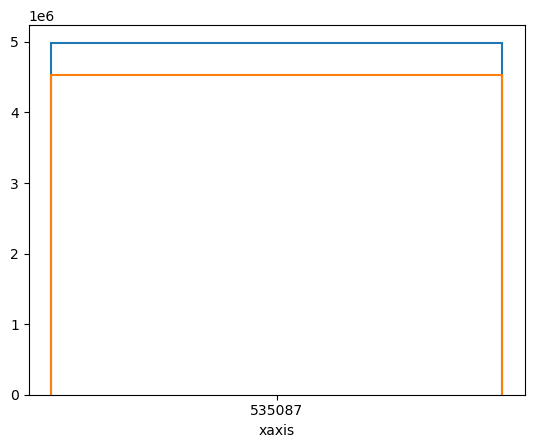

In [5]:
results["bc-selection-task/hCounterTVX"].to_hist().plot()
results["bc-selection-task/hCounterTVXafterBCcuts"].to_hist().plot()

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x724eb5573c50>, cbar=<matplotlib.colorbar.Colorbar object at 0x724eb57c7250>, text=[])

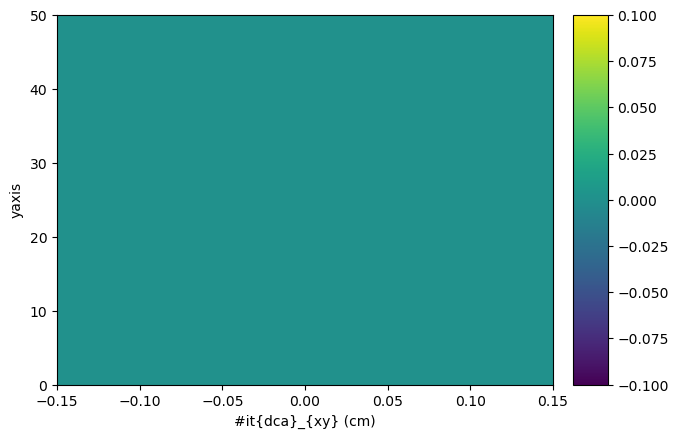

In [8]:
results["track-propagation/hDCAxyVsPtRec"].to_hist().plot()

In [14]:
results["tof-signal"].keys()

[]

# Data analysis

In [5]:
names_track_extr = file.keys(filter_name=r"*O2filtertrackextr")

bucket = []

for i in range(len(names_track_extr)):
    
    df_trackextr = file[ names_track_extr[i] ].arrays(["fPt", "fEta", "fCharge", "fDcaXY", "fNsigmaTPCpi", "fNsigmaTPCka", "fNsigmaTPCpr",
                                                       "fNsigmaTOFpi", "fNsigmaTOFka", "fNsigmaTOFpr"], library="pd" )
    bucket.append(df_trackextr)

real_data = pd.concat(bucket, ignore_index=True)
real_data.head(5)

,fPt,fEta,fCharge,fDcaXY,fNsigmaTPCpi,fNsigmaTPCka,fNsigmaTPCpr,fNsigmaTOFpi,fNsigmaTOFka,fNsigmaTOFpr
0,0.471111,0.086615,-1,0.004583,1.296971,-6.567831,-14.216860,5.796030,-34.445034,-77.350662
1,0.537510,0.539420,1,0.011716,9.544146,1.979263,-9.118285,47.058315,2.731402,-34.971691
2,0.311392,0.052986,1,-0.005521,-1.248399,-12.175531,-12.922401,-999.000000,-999.000000,-999.000000
3,0.884602,-0.032689,-1,-0.001190,0.343225,-1.040863,-6.603751,-999.000000,-999.000000,-999.000000
4,0.371757,-0.593066,-1,0.003221,-1.047941,-8.668435,-15.893881,-999.000000,-999.000000,-999.000000


## Real data: TOFka and TPCka

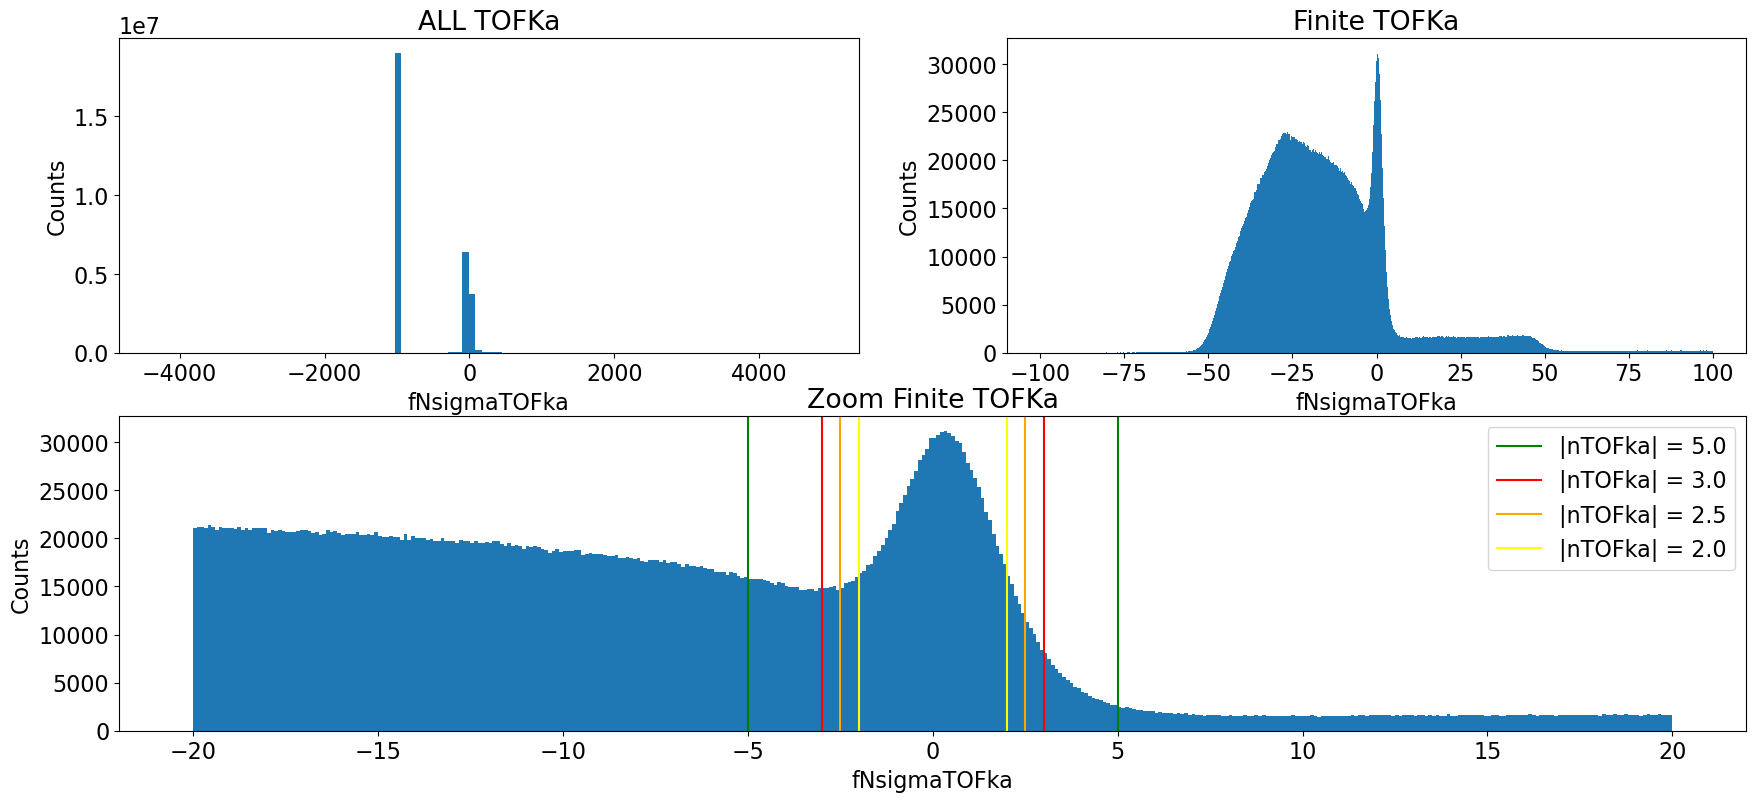

Unavailable TOFka: 64.42%
TOFka distribution in % (These are referred to the portion of data whose TOFka is not -999)


,"[-0.5, 0.5]","[-1, 1]","[-1.5, 1.5]","[-2.0, 2.0]","[-2.5, 2.5]","[-3.0, 3.0]","[-4.0, 4.0]","[-5, 5]","[-7, 7]","[-10, 10]"
% of Finite TOFKa,2.83,5.4,7.55,9.29,10.7,11.88,13.85,15.65,19.21,24.84
% of Total,1.01,1.92,2.69,3.31,3.81,4.23,4.93,5.57,6.84,8.84


In [66]:
N_BINS = 100
bin_width = 0.1

mosaic = [
    ["ALL TOFKa", "Finite TOFKa"],
    ["Finite ZOOM TOFKa", "Finite ZOOM TOFKa"]
]


fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))

NA_TOFKa_mask = real_data["fNsigmaTOFka"] == -999

axes["ALL TOFKa"].hist(real_data["fNsigmaTOFka"], bins=N_BINS)
axes["ALL TOFKa"].set_title("ALL TOFKa")
axes["ALL TOFKa"].set_xlabel("fNsigmaTOFka")
axes["ALL TOFKa"].set_ylabel("Counts")

axes["Finite TOFKa"].hist(real_data[~NA_TOFKa_mask]["fNsigmaTOFka"], range=(-100,100), bins=np.arange(-100, 100+bin_width, bin_width))
axes["Finite TOFKa"].set_title("Finite TOFKa")
axes["Finite TOFKa"].set_xlabel("fNsigmaTOFka")
axes["Finite TOFKa"].set_ylabel("Counts")

axes["Finite ZOOM TOFKa"].hist(real_data[~NA_TOFKa_mask]["fNsigmaTOFka"], range=(-20,20), bins=np.arange(-20,20+bin_width, bin_width))
axes["Finite ZOOM TOFKa"].set_title("Zoom Finite TOFKa")
axes["Finite ZOOM TOFKa"].axvline(x=-5, color="green", label="|nTOFka| = 5.0")
axes["Finite ZOOM TOFKa"].axvline(x=+5, color="green")
axes["Finite ZOOM TOFKa"].axvline(x=-3, color="red", label="|nTOFka| = 3.0")
axes["Finite ZOOM TOFKa"].axvline(x=+3, color="red")
axes["Finite ZOOM TOFKa"].axvline(x=-2.5, color="orange", label="|nTOFka| = 2.5")
axes["Finite ZOOM TOFKa"].axvline(x=+2.5, color="orange")
axes["Finite ZOOM TOFKa"].axvline(x=-2.0, color="yellow", label="|nTOFka| = 2.0")
axes["Finite ZOOM TOFKa"].axvline(x=+2.0, color="yellow")
axes["Finite ZOOM TOFKa"].set_xlabel("fNsigmaTOFka")
axes["Finite ZOOM TOFKa"].set_ylabel("Counts")
plt.legend()

plt.show()

tot = len(real_data)
tot_NA_TOFKA = np.sum(NA_TOFKa_mask)
tot_finite_TOFKA = tot - tot_NA_TOFKA
print(f"Unavailable TOFka: {tot_NA_TOFKA/tot*100:.2f}%")

TOFka_slice = [ [-0.5,0.5], [-1, 1], [-1.5,1.5], [-2.0,2.0], [-2.5, 2.5], [-3.0, 3.0], [-4.0, 4.0], [-5, 5], [-7,7], [-10,10] ]
TOFka_bucket = []
for i in range (len(TOFka_slice)):
    TOFka_lim = TOFka_slice[i]
    TOFka_bucket.append( np.sum(real_data["fNsigmaTOFka"].between(TOFka_lim[0], TOFka_lim[1]))/tot_finite_TOFKA )
TOFka_recap = pd.DataFrame(columns=[str(item) for item in TOFka_slice], index=["% of Finite TOFKa", "% of Total"])
TOFka_recap.loc["% of Finite TOFKa"] = TOFka_bucket
TOFka_recap.loc["% of Total"] = np.array(TOFka_bucket)*tot_finite_TOFKA/tot
pd.set_option("display.precision", 2)
print("TOFka distribution in % (These are referred to the portion of data whose TOFka is not -999)")
TOFka_recap*100

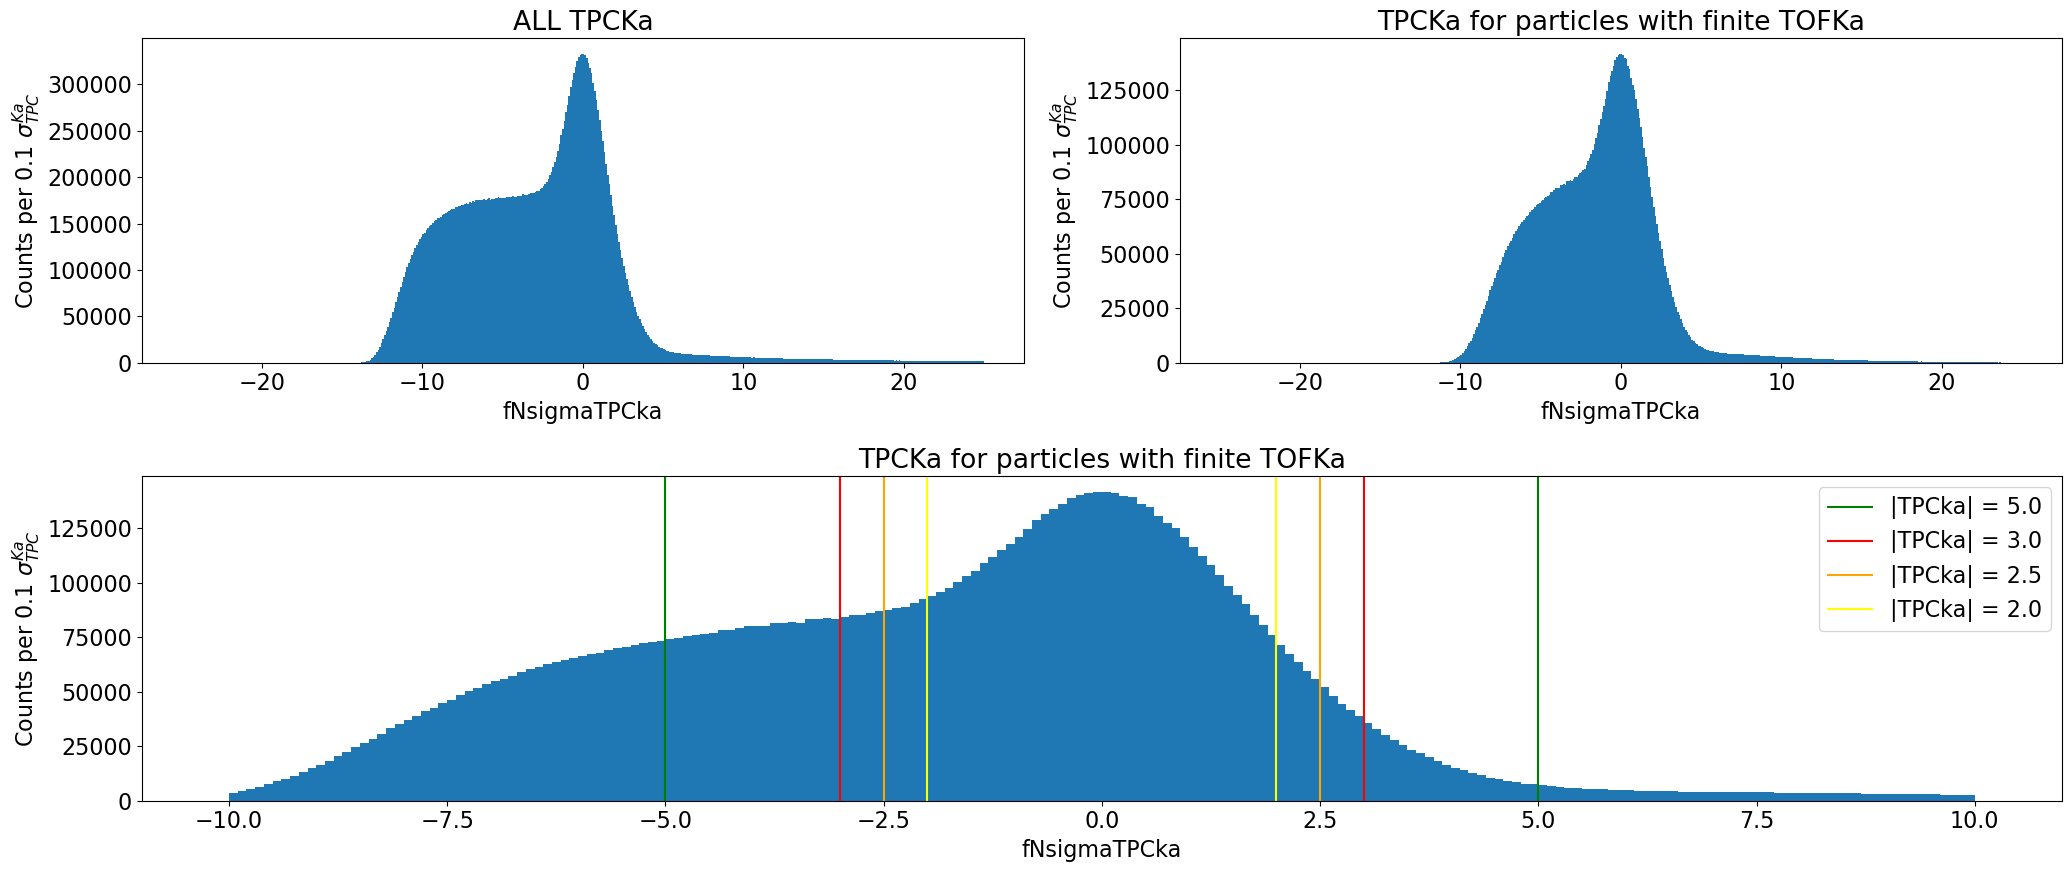

TPCka distribution in %


,"[-0.5, 0.5]","[-1, 1]","[-1.5, 1.5]","[-2.0, 2.0]","[-2.5, 2.5]","[-3.0, 3.0]","[-4.0, 4.0]","[-5, 5]","[-7, 7]","[-10, 10]"
% of Total,11.08,21.04,29.35,36.07,41.6,46.28,54.1,60.89,73.53,90.51


In [51]:
# I fix the bin width instead of number of bins for an easier comparison between the various graphs
bin_width = 0.1

mosaic = [
    ["ALL TPCKa", "Finite TPCKa"],
    ["ZOOM TPCKa", "ZOOM TPCKa"]
]

fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))

axes["ALL TPCKa"].hist(real_data["fNsigmaTPCka"],range=(-25,25), bins=np.arange(-25,25+bin_width, bin_width ) )
axes["ALL TPCKa"].set_title("ALL TPCKa")
axes["ALL TPCKa"].set_xlabel("fNsigmaTPCka")
axes["ALL TPCKa"].set_ylabel(f"Counts per {bin_width} " + r"$\sigma_{TPC}^{ka}$")

axes["Finite TPCKa"].hist(real_data[~NA_TOFKa_mask]["fNsigmaTPCka"], range=(-25,25), bins=np.arange(-25,25+bin_width, bin_width ))
axes["Finite TPCKa"].set_title("TPCKa for particles with finite TOFKa")
axes["Finite TPCKa"].set_xlabel("fNsigmaTPCka")
axes["Finite TPCKa"].set_ylabel(f"Counts per {bin_width} " + r"$\sigma_{TPC}^{ka}$")

axes["ZOOM TPCKa"].hist(real_data[~NA_TOFKa_mask]["fNsigmaTPCka"], range=(-10,10), bins=np.arange(-10,10+bin_width, bin_width ))
axes["ZOOM TPCKa"].set_title("nTPCKa for particles with finite nTOFKa")
axes["ZOOM TPCKa"].axvline(x=-5, color="green", label="|nTPCka| = 5.0")
axes["ZOOM TPCKa"].axvline(x=+5, color="green")
axes["ZOOM TPCKa"].axvline(x=-3, color="red", label="|nTPCka| = 3.0")
axes["ZOOM TPCKa"].axvline(x=+3, color="red")
axes["ZOOM TPCKa"].axvline(x=-2.5, color="orange", label="|nTPCka| = 2.5")
axes["ZOOM TPCKa"].axvline(x=+2.5, color="orange")
axes["ZOOM TPCKa"].axvline(x=-2.0, color="yellow", label="|nTPCka| = 2.0")
axes["ZOOM TPCKa"].axvline(x=+2.0, color="yellow")
axes["ZOOM TPCKa"].set_xlabel("fNsigmaTPCka")
axes["ZOOM TPCKa"].set_ylabel(f"Counts per {bin_width} " + r"$n\sigma_{TPC}^{ka}$")
plt.legend()

plt.tight_layout()
plt.show()

TPCka_slice = [ [-0.5,0.5], [-1, 1], [-1.5,1.5], [-2.0,2.0], [-2.5, 2.5], [-3.0, 3.0], [-4.0, 4.0], [-5, 5], [-7,7], [-10,10] ]
TPCka_bucket = []
for i in range (len(TPCka_slice)):
    TPCka_lim = TPCka_slice[i]
    TPCka_bucket.append( np.sum(real_data["fNsigmaTPCka"].between(TPCka_lim[0], TPCka_lim[1]))/tot)
TPCKa_recap = pd.DataFrame(columns=[str(item) for item in TOFka_slice], index=["% of Total"])
TPCKa_recap.loc["% of Total"] = TPCka_bucket
pd.set_option("display.precision", 2)
print("TPCka distribution in %")
TPCKa_recap*100

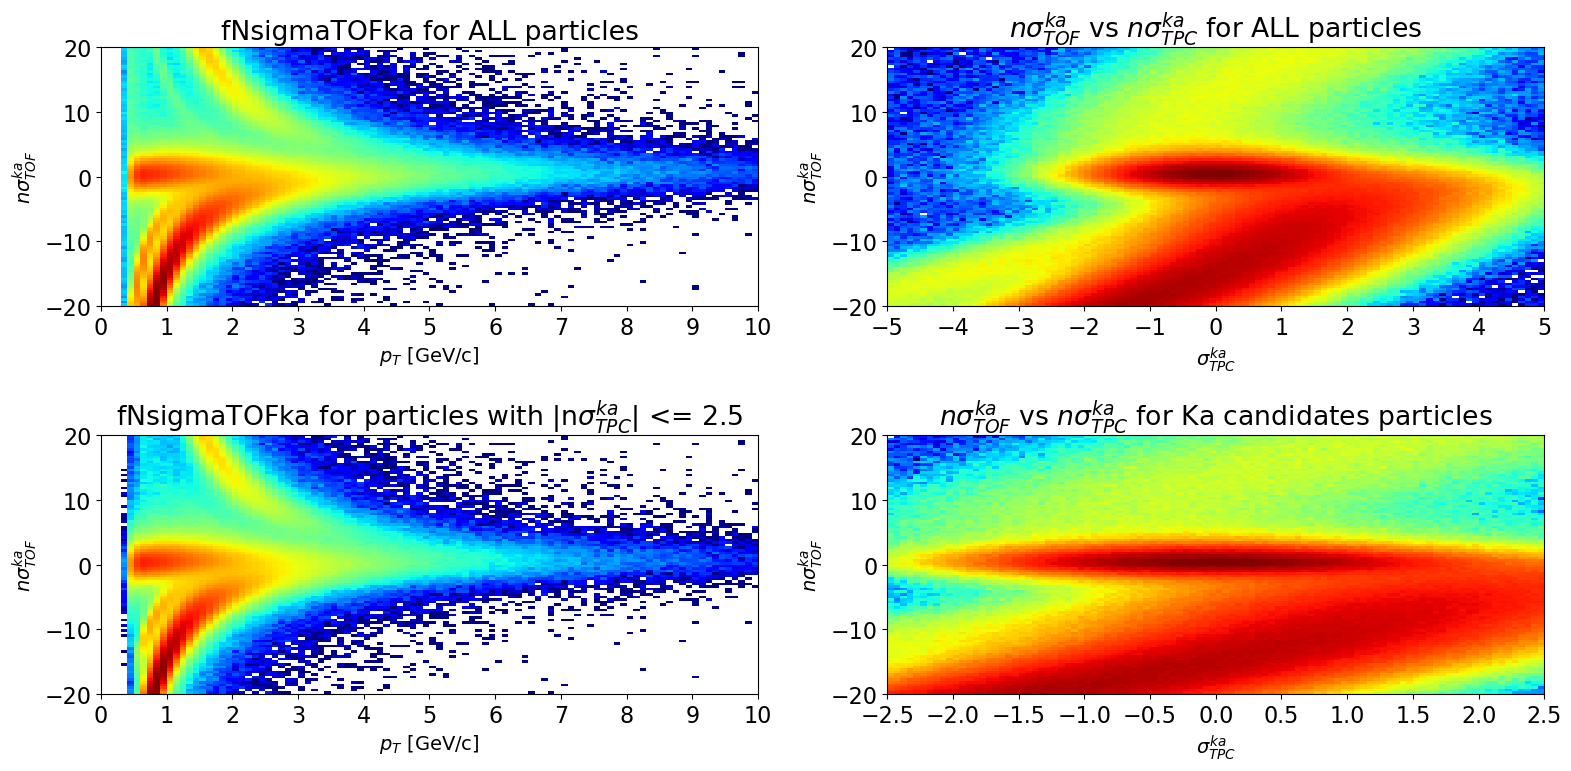

In [64]:
min_cut_TOF_KA, max_cut_TOF_KA = -20.0, 20.0
min_cut_TPC_KA, max_cut_TPC_KA = -5.0, 5.0
p_cut_lower, p_cut_upper = 0, 10

mosaic = [ ["top left", "top right"],
           ["bot left", "bot right"]
         ]

fs = 14
p_cut_lower = 0
p_cut_upper = 10
fig, axes = plt.subplot_mosaic(mosaic, figsize=(16, 8))
axes["top left"].hist2d(real_data["fPt"], real_data["fNsigmaTOFka"] , (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[min_cut_TOF_KA,max_cut_TOF_KA]]))
# plt.colorbar(ax=axes["top"])
axes["top left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top left"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["top left"].set_xlim(p_cut_lower, p_cut_upper )
axes["top left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top left"].set_title("fNsigmaTOFka for ALL particles")

axes["top right"].hist2d(real_data["fNsigmaTPCka"], real_data["fNsigmaTOFka"] , (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[min_cut_TPC_KA,max_cut_TPC_KA],[min_cut_TOF_KA,max_cut_TOF_KA]]))
# plt.colorbar(ax=axes["top"])
axes["top right"].set_xlabel(r"$\sigma^{ka}_{TPC}$", fontsize=fs)
axes["top right"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["top right"].set_xlim(min_cut_TPC_KA, max_cut_TPC_KA )
axes["top right"].set_xticks(np.arange(min_cut_TPC_KA, max_cut_TPC_KA+1, 1) )
axes["top right"].set_title(r"$n\sigma^{ka}_{TOF}$ vs $n\sigma^{ka}_{TPC}$ for ALL particles")

# Let's see for those that are more likely to be actual Kaons
TPCKa_cut = 2.5
TPC_Ka_mask = real_data["fNsigmaTPCka"].abs() <= TPCKa_cut

axes["bot left"].hist2d(real_data[TPC_Ka_mask]["fPt"], real_data[TPC_Ka_mask]["fNsigmaTOFka"] , (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[min_cut_TOF_KA,max_cut_TOF_KA]]))
# plt.colorbar(ax=axes["top"])
axes["bot left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["bot left"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["bot left"].set_xlim(p_cut_lower, p_cut_upper )
axes["bot left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["bot left"].set_title(r"fNsigmaTOFka for particles with |n$\sigma^{ka}_{TPC}$| <= " + f"{TPCKa_cut:.1f}")

axes["bot right"].hist2d(real_data[TPC_Ka_mask]["fNsigmaTPCka"], real_data[TPC_Ka_mask]["fNsigmaTOFka"] , (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[-TPCKa_cut,+TPCKa_cut],[min_cut_TOF_KA,max_cut_TOF_KA]]))
# plt.colorbar(ax=axes["top"])
axes["bot right"].set_xlabel(r"$\sigma^{ka}_{TPC}$", fontsize=fs)
axes["bot right"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["bot right"].set_xlim(-TPCKa_cut, +TPCKa_cut )
axes["bot right"].set_xticks(np.arange(-TPCKa_cut, TPCKa_cut+0.5, 0.5) )
axes["bot right"].set_title(r"$n\sigma^{ka}_{TOF}$ vs $n\sigma^{ka}_{TPC}$ for Ka candidates particles")
# axes["bot right"].axhline(y=-5, color="green", label="|nTOFka| = 5.0")
# axes["bot right"].axhline(y=+5, color="green")
# axes["bot right"].axhline(y=-3, color="red", label="|nTOFka| = 3.0")
# axes["bot right"].axhline(y=+3, color="red", label="|nTOFka| = 3.0")

plt.tight_layout()
plt.show()

## Real data: TOFka and TPCka, now in pt_slice (This is the pt of the unknown daughter particle)

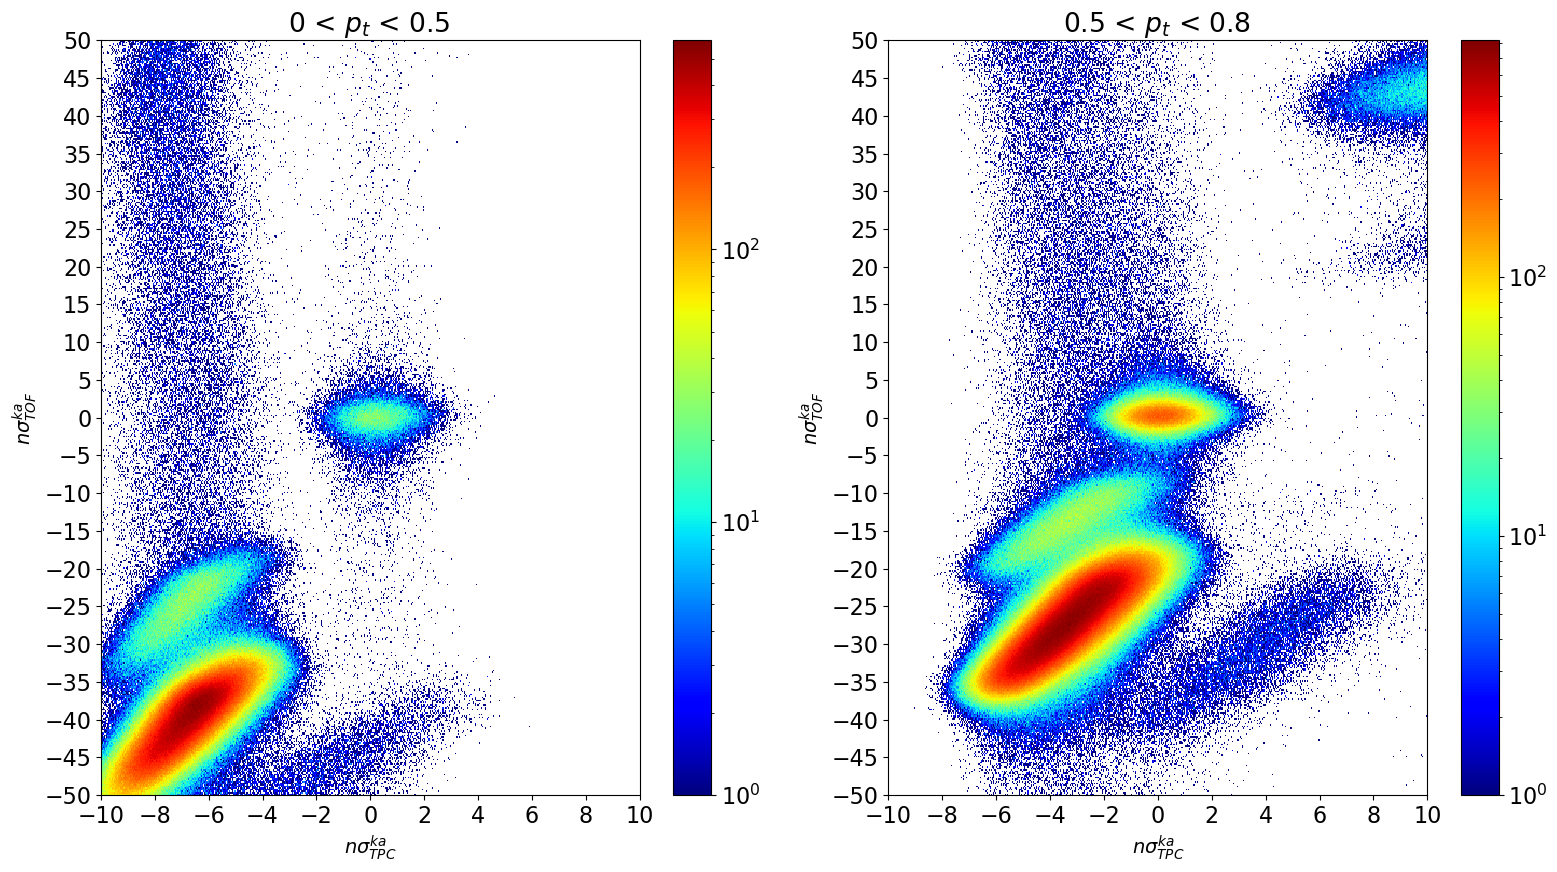

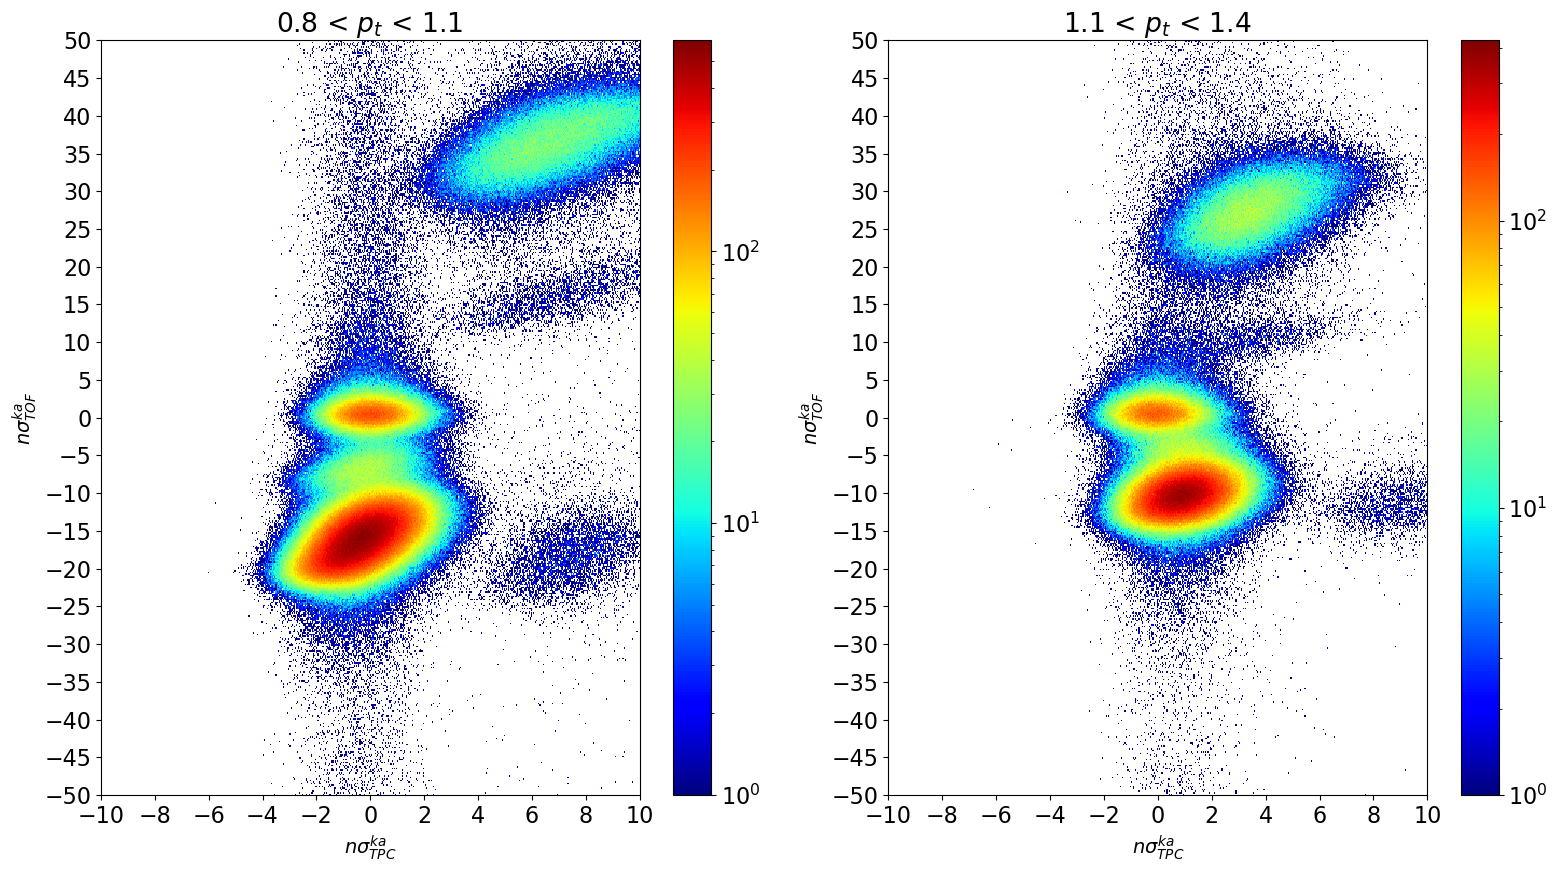

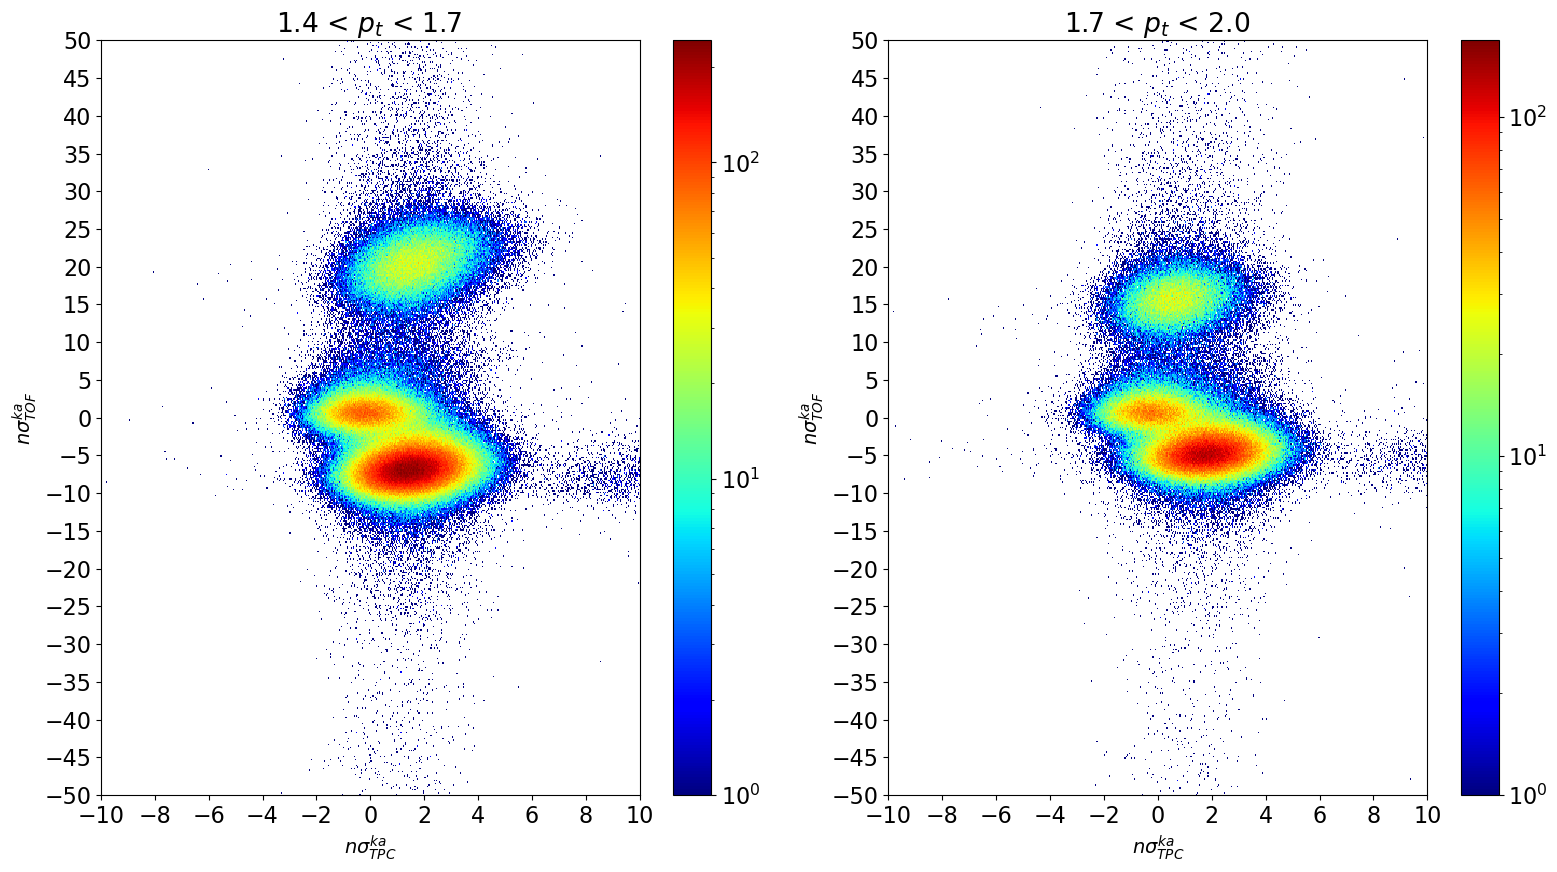

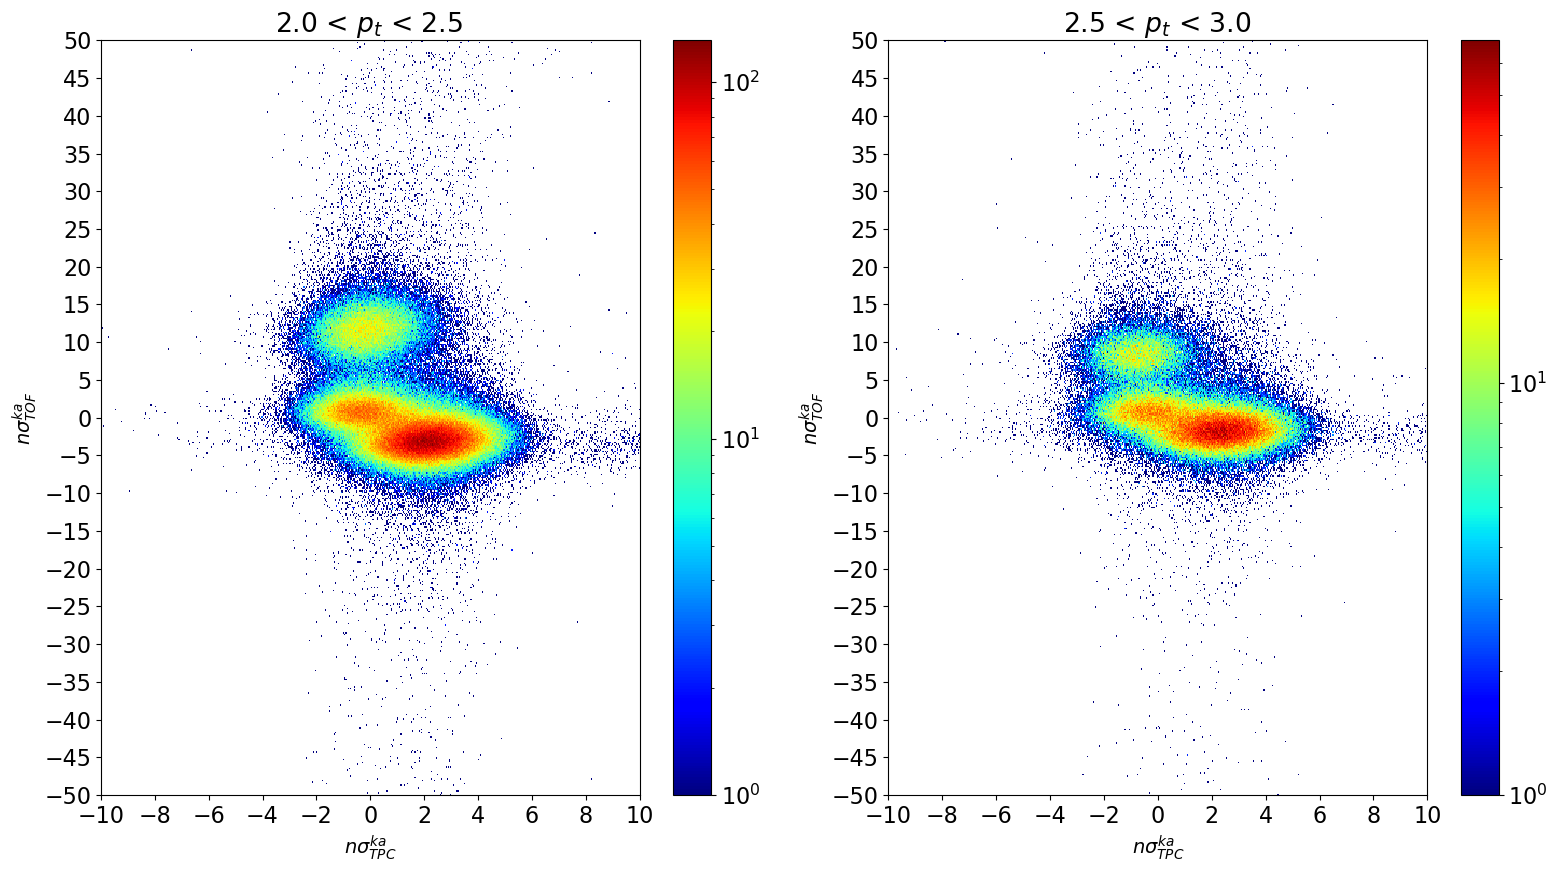

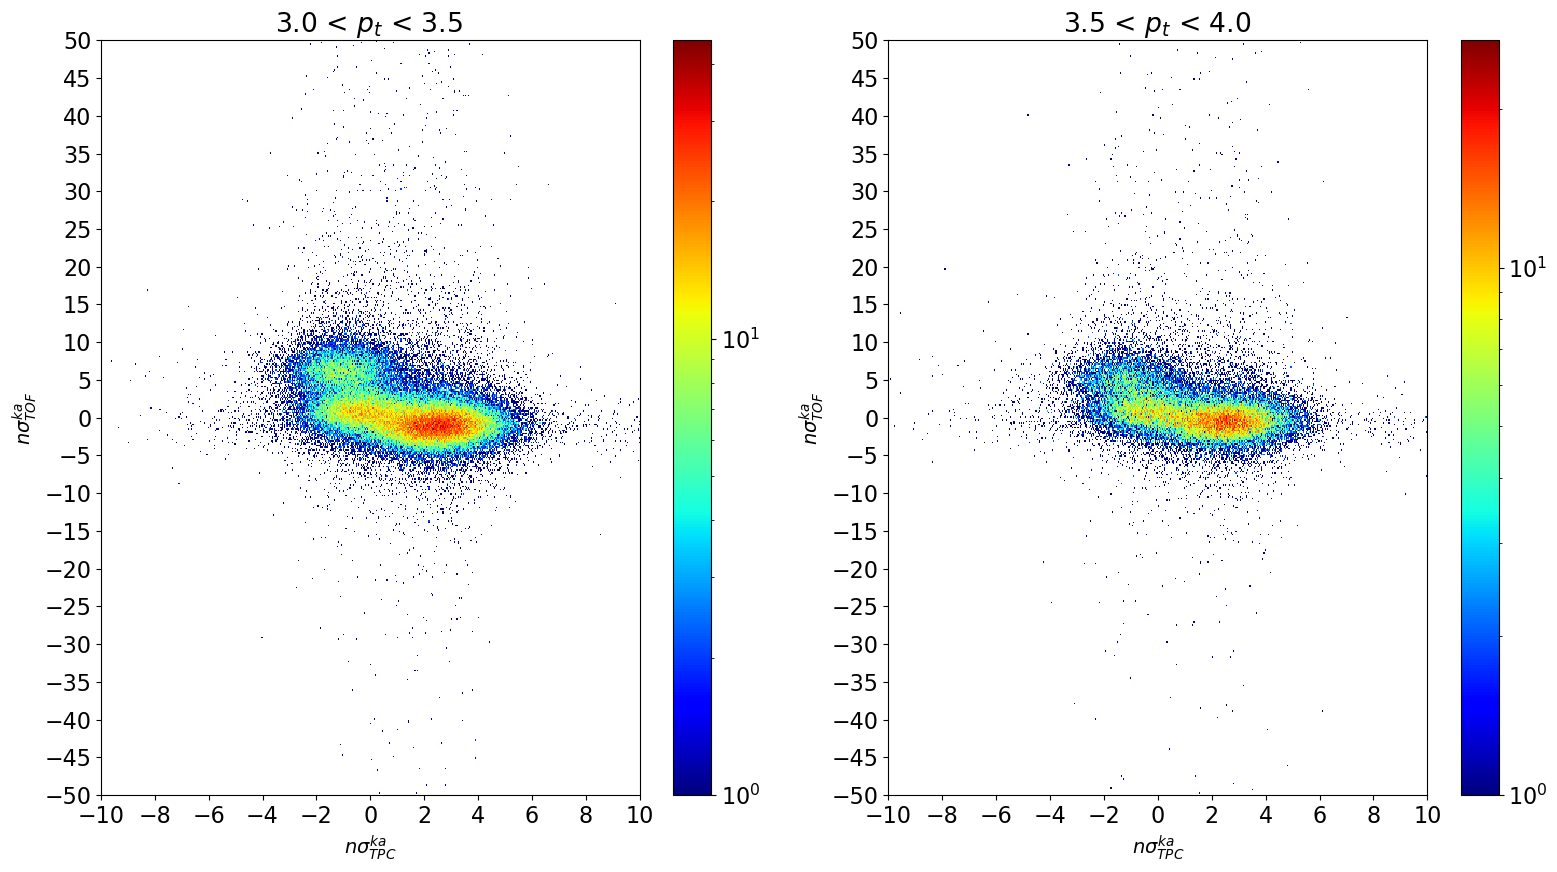

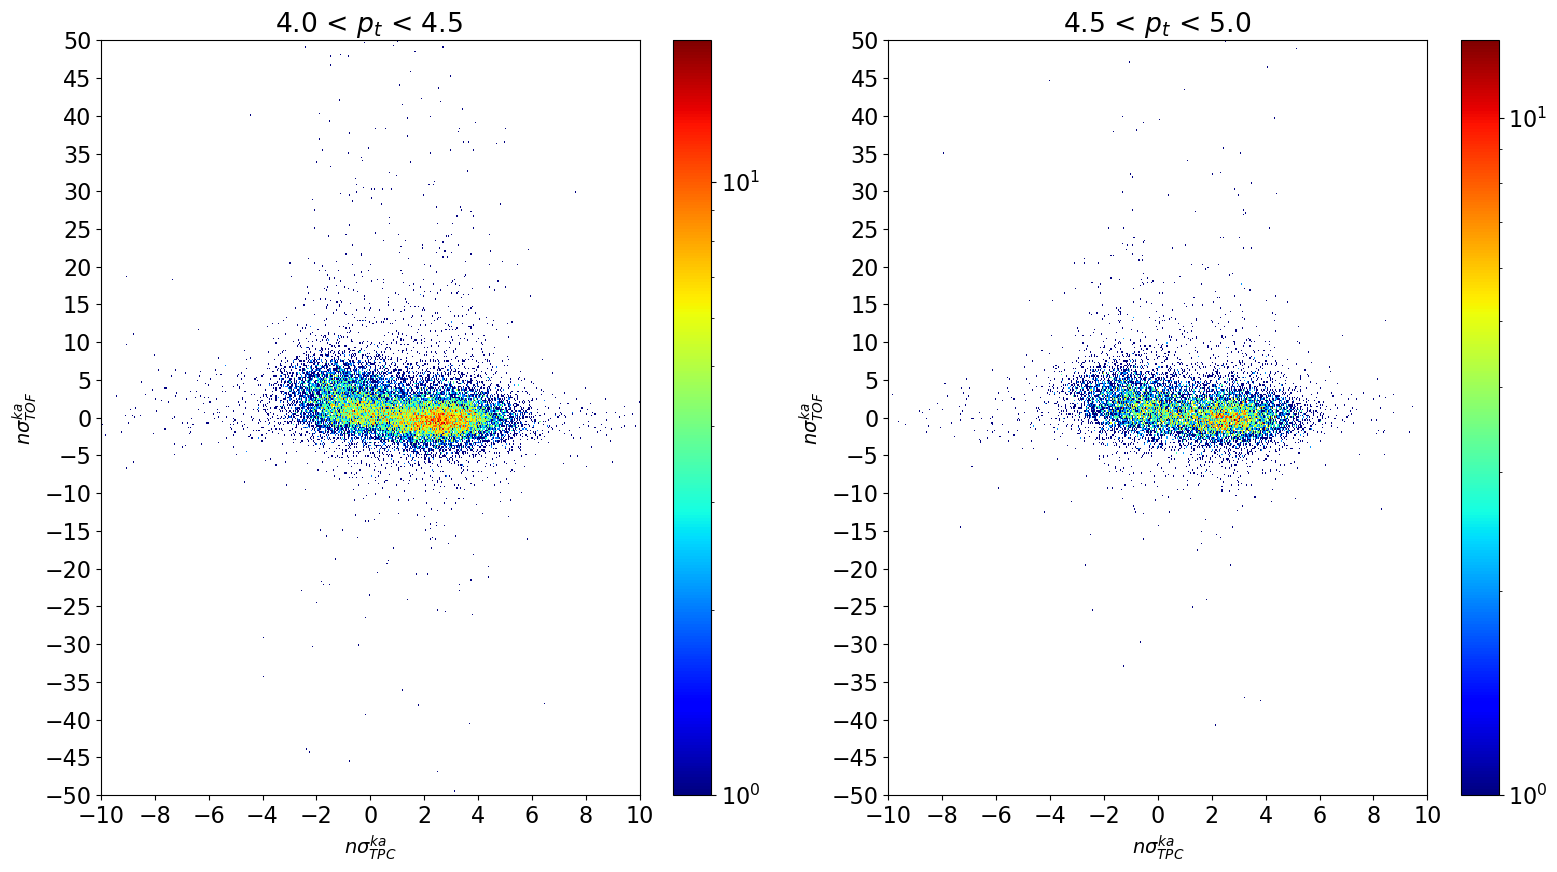

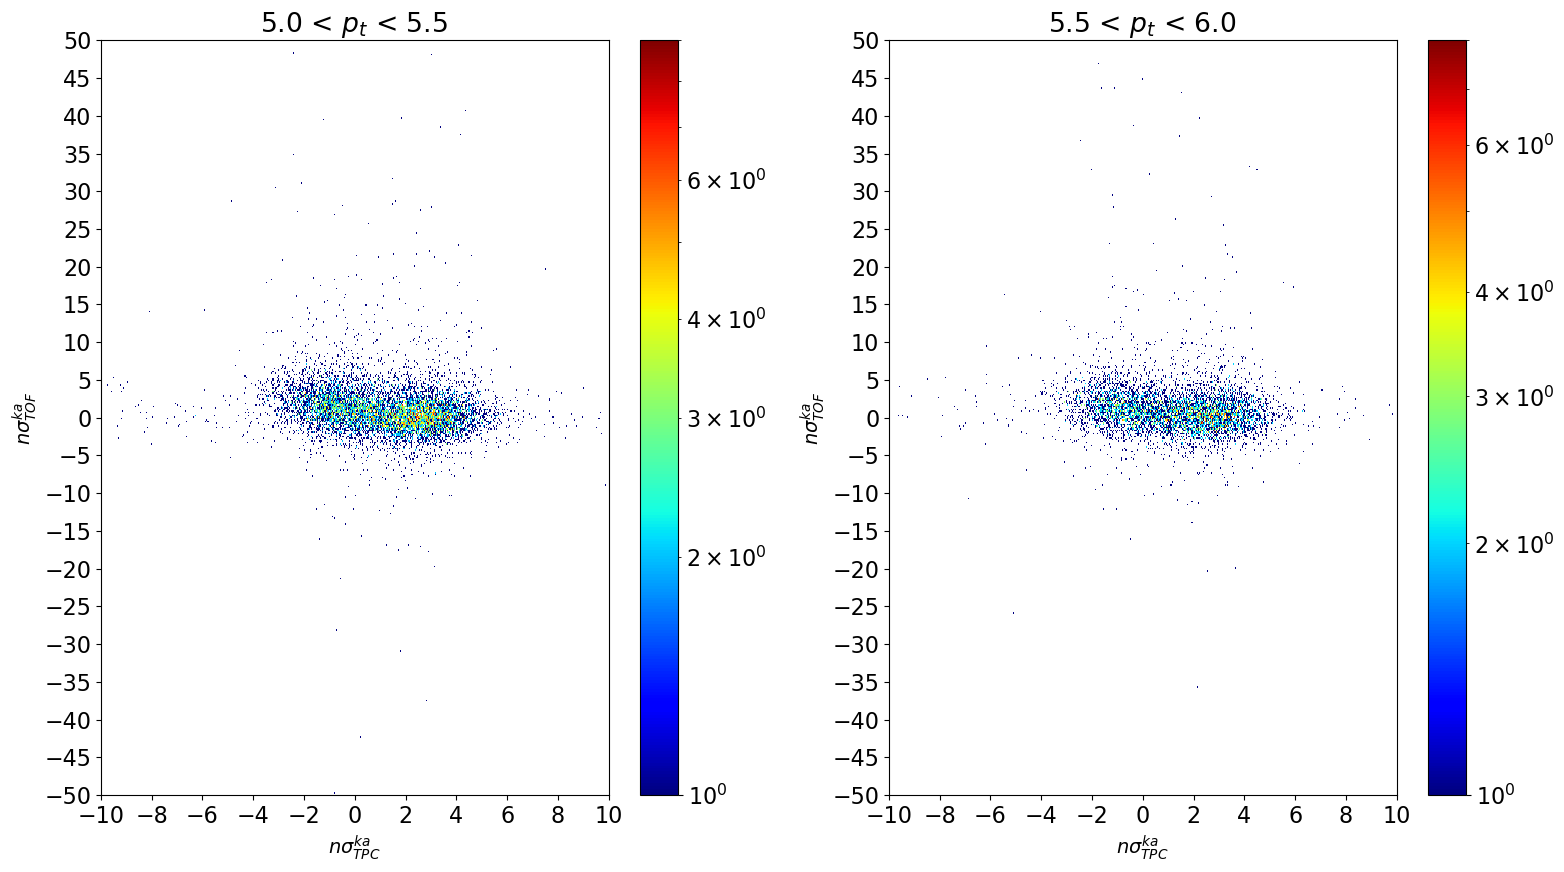

In [74]:
pt_slices = [ [0, 0.5], [0.5, 0.8], [0.8, 1.1], [1.1, 1.4], [1.4, 1.7], [1.7, 2.0], [2.0, 2.5], [2.5, 3.0], [3.0, 3.5], [3.5, 4.0],
              [4.0, 4.5], [4.5, 5.0], [5.0, 5.5], [5.5,6.0]
            ]
curr_item = 0
while (curr_item < len(pt_slices) ):
    data = real_data[ real_data["fPt"].between(pt_slices[curr_item][0], pt_slices[curr_item][1]) ]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,9))
    h = ax1.hist2d(data["fNsigmaTPCka"],data["fNsigmaTOFka"], (500, 500), cmap="jet", norm=LogNorm(), range=([[-10,10], [-50,50]]) )
    fig.colorbar(h[3], ax=ax1)
    ax1.set_xlabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
    ax1.set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
    ax1.set_xlim(-10,10)
    ax1.set_xticks(np.arange(-10,10+2,2))
    ax1.set_ylim(-50,50)
    ax1.set_yticks(np.arange(-50,50+5,5))
    ax1.set_title(f"{pt_slices[curr_item][0]} < $p_t$ < {pt_slices[curr_item][1]} ")

    data = real_data[ real_data["fPt"].between(pt_slices[curr_item+1][0], pt_slices[curr_item+1][1]) ]
     
    h2 = ax2.hist2d(data["fNsigmaTPCka"], data["fNsigmaTOFka"], (500, 500), cmap="jet", norm=LogNorm(), range=([[-10,10], [-50,50]]))
    fig.colorbar(h2[3], ax=ax2)
    ax2.set_xlabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
    ax2.set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
    ax2.set_xlim(-10,10)
    ax2.set_xticks(np.arange(-10,10+2,2))
    ax2.set_ylim(-50,50)
    ax2.set_yticks(np.arange(-50,50+5,5))
    ax2.set_title(f"{pt_slices[curr_item+1][0]} < $p_t$ < {pt_slices[curr_item+1][1]} ")

    curr_item += 2

    plt.tight_layout()
    plt.show()

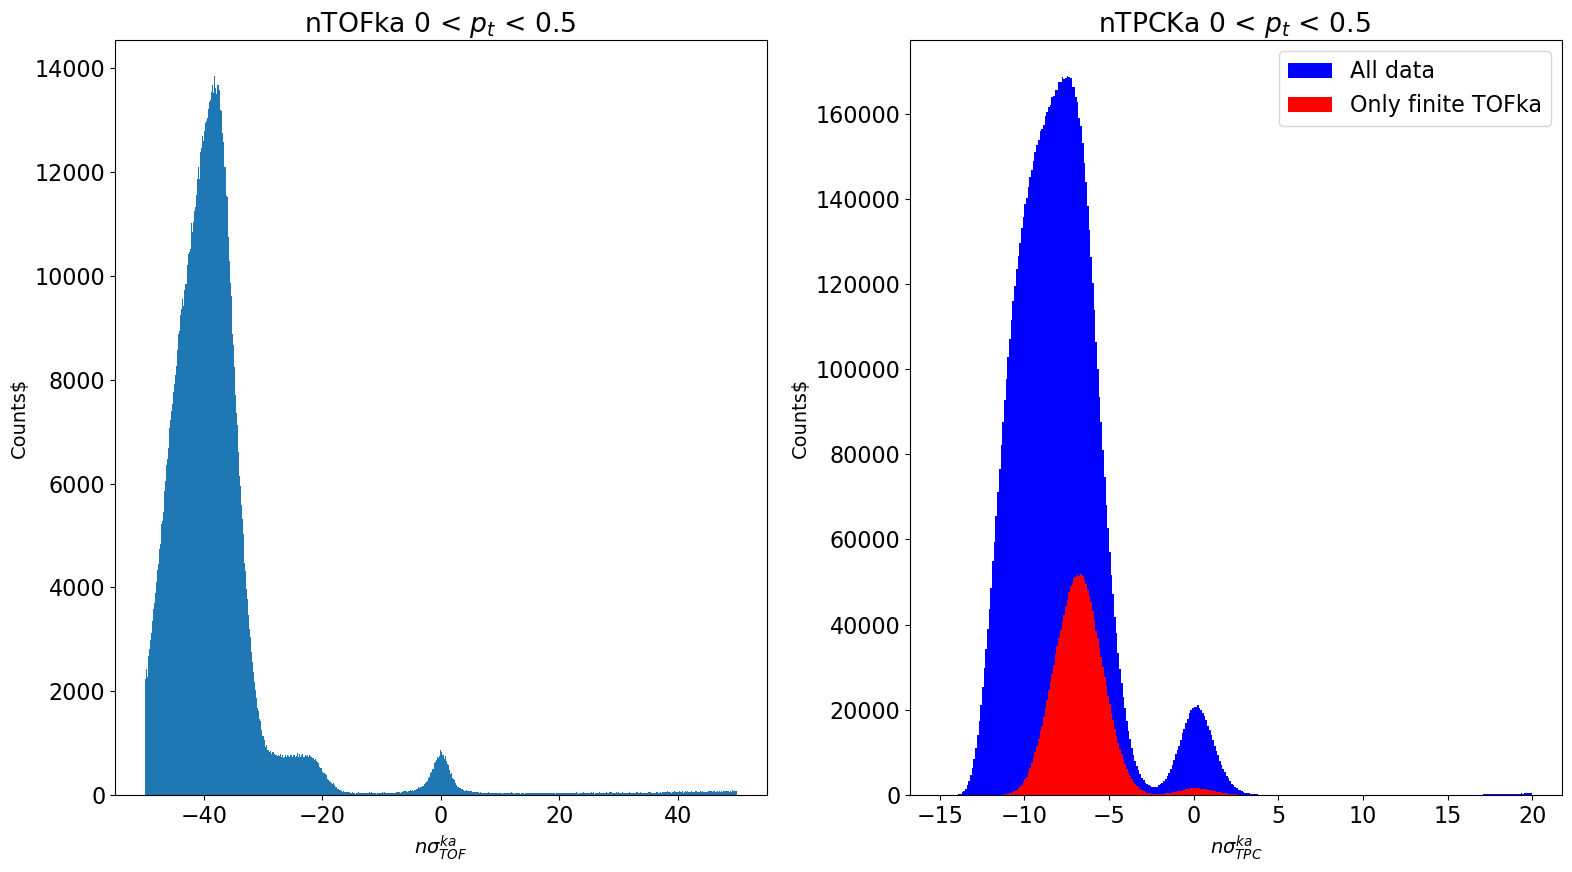

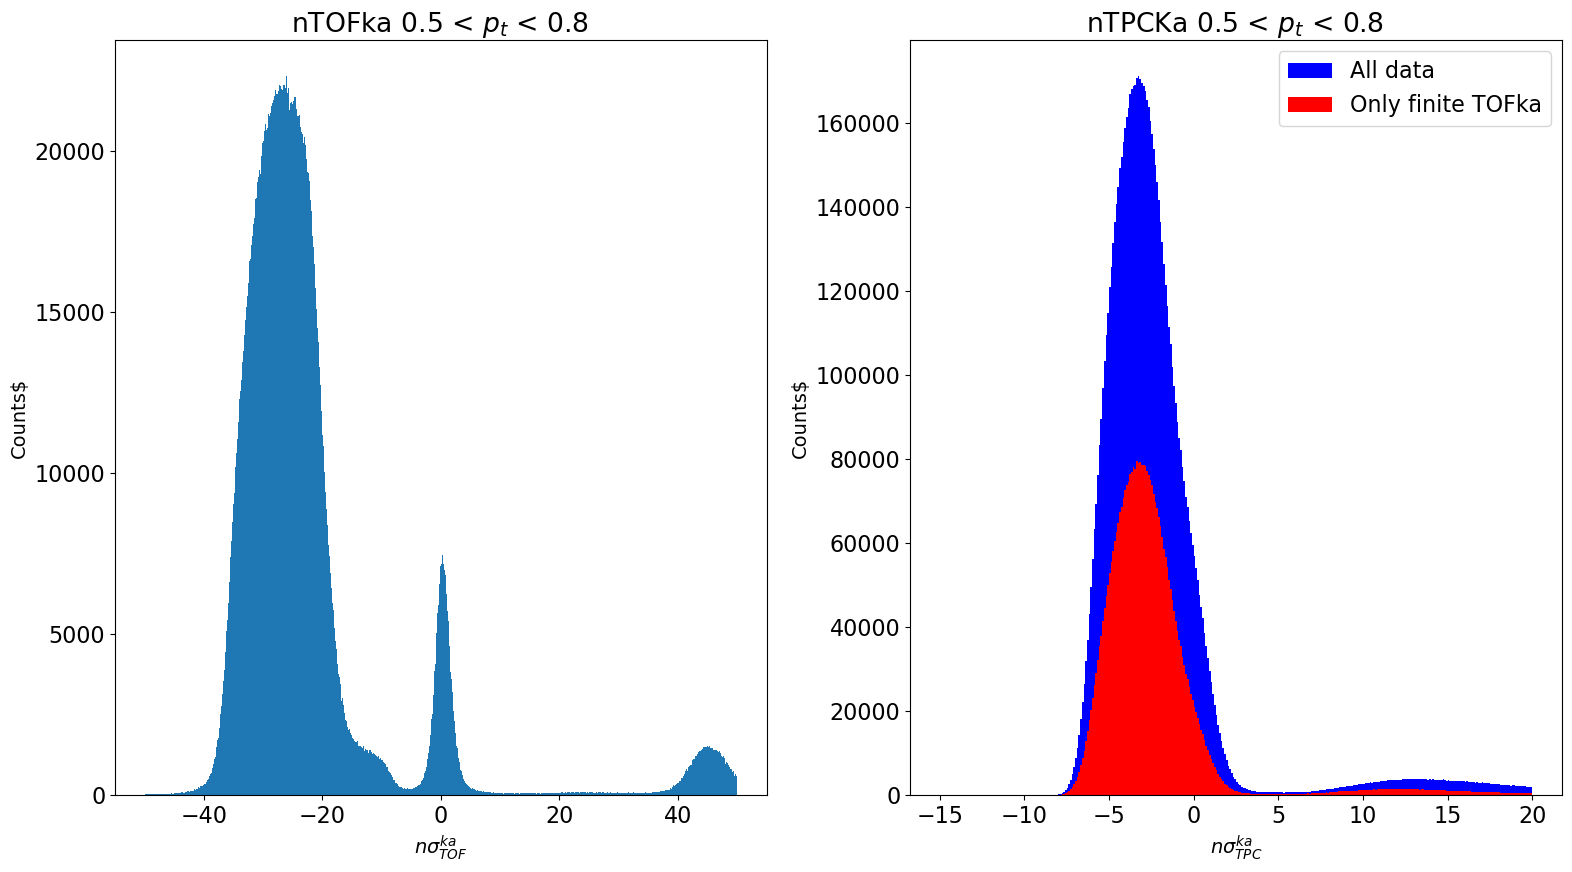

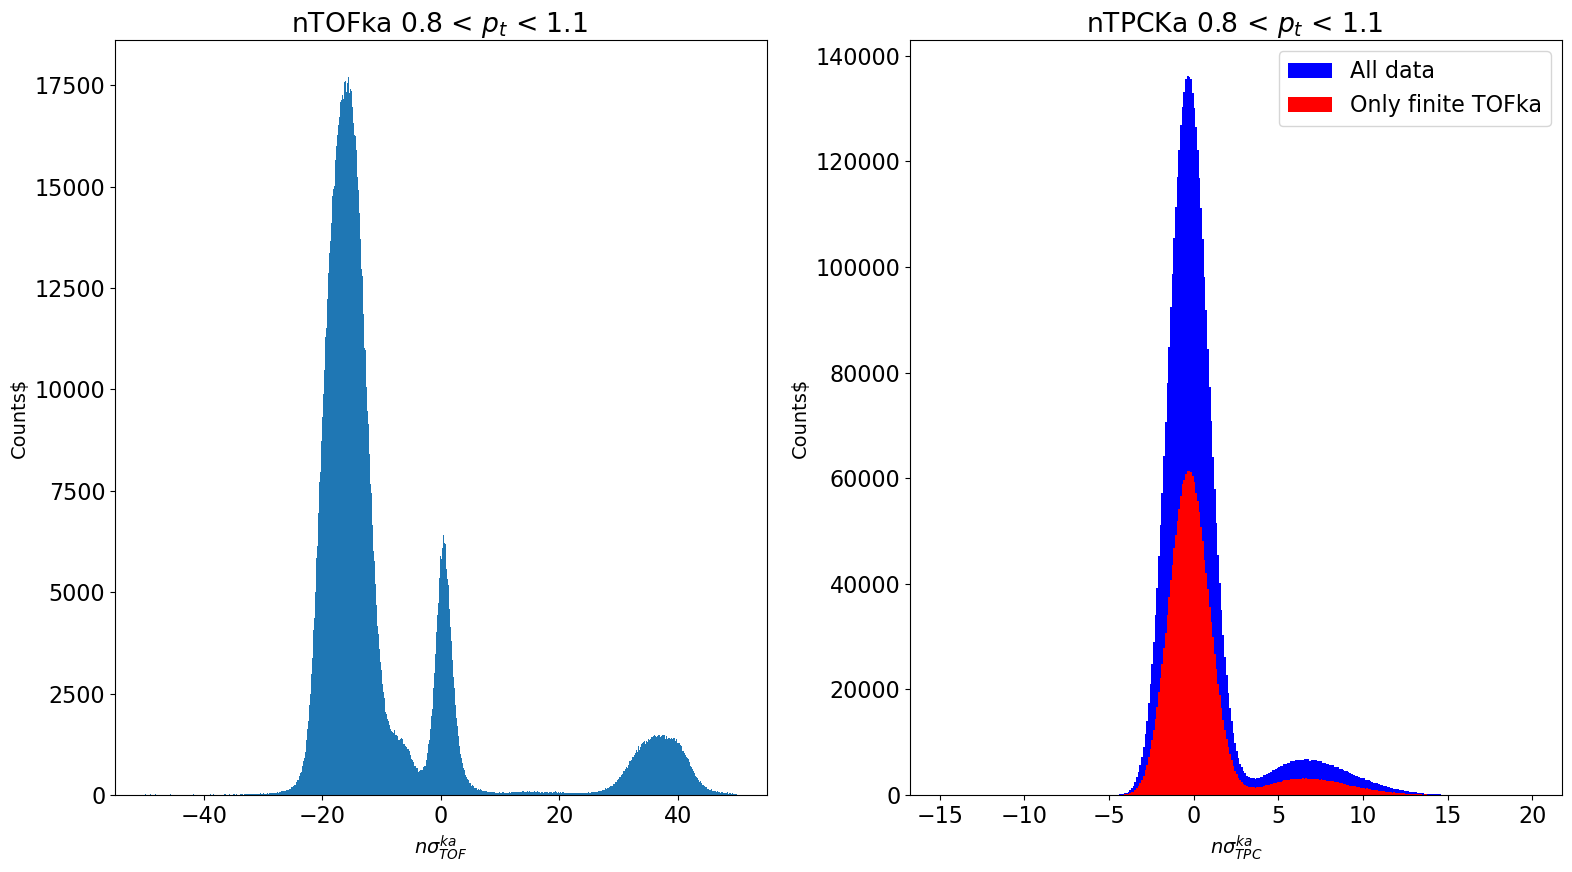

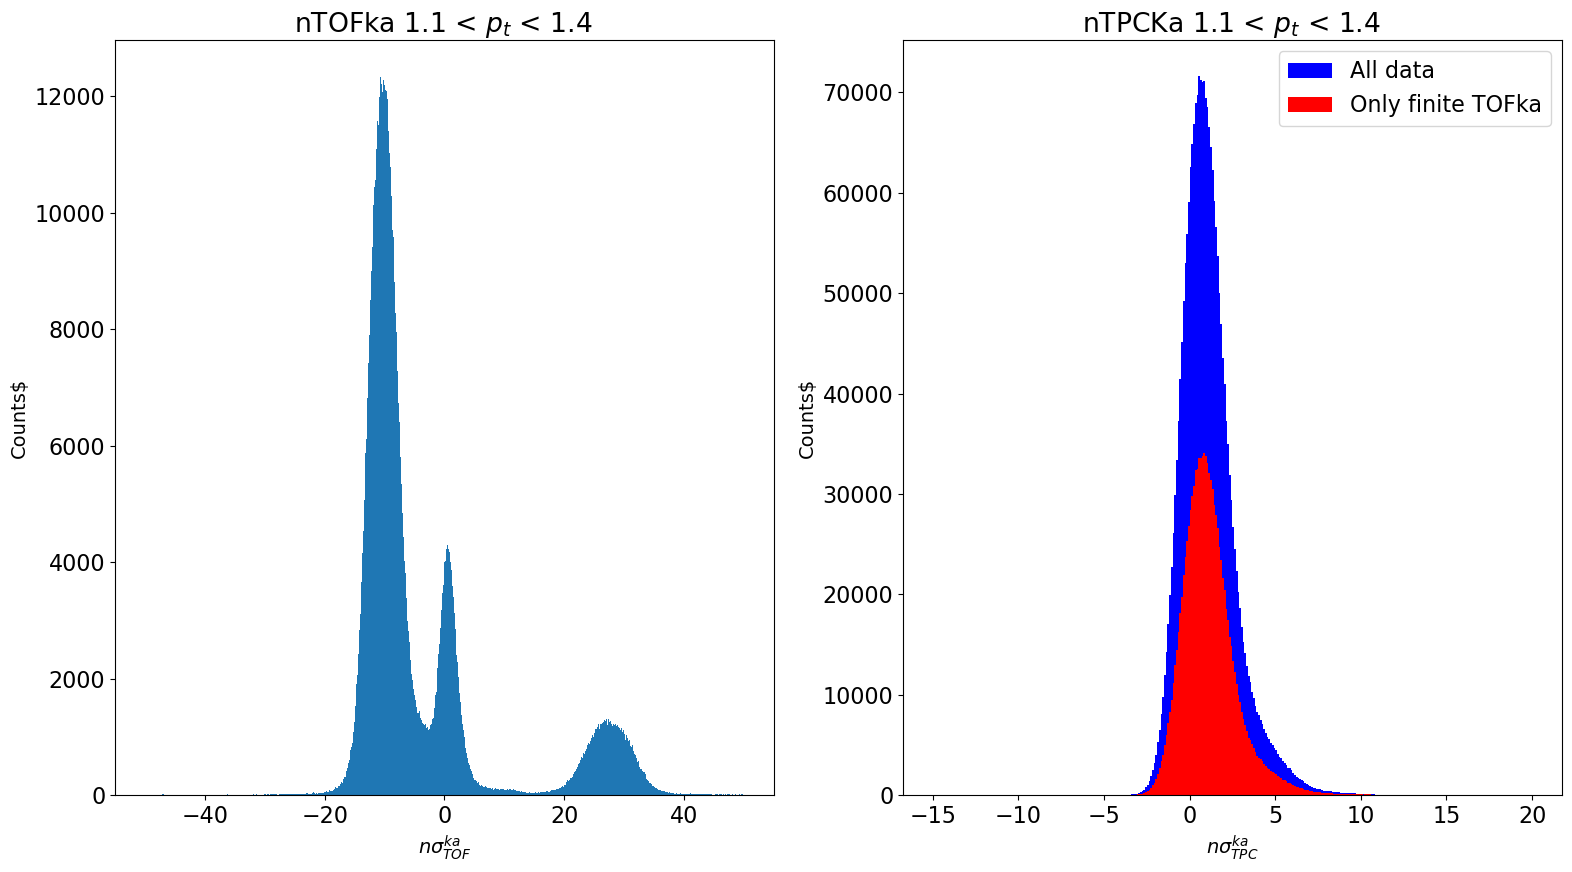

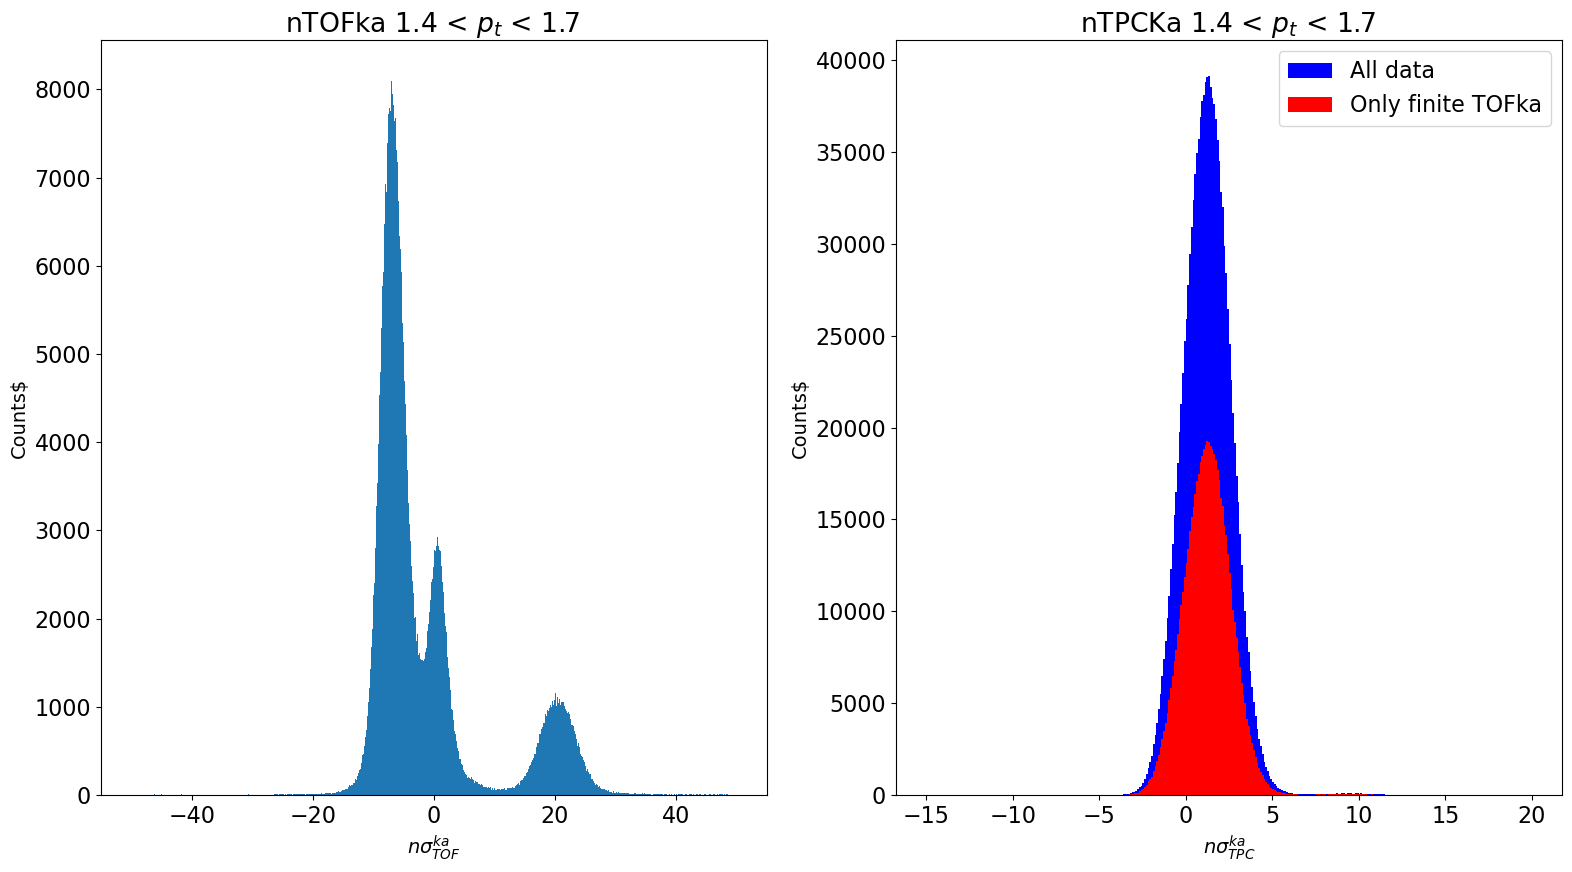

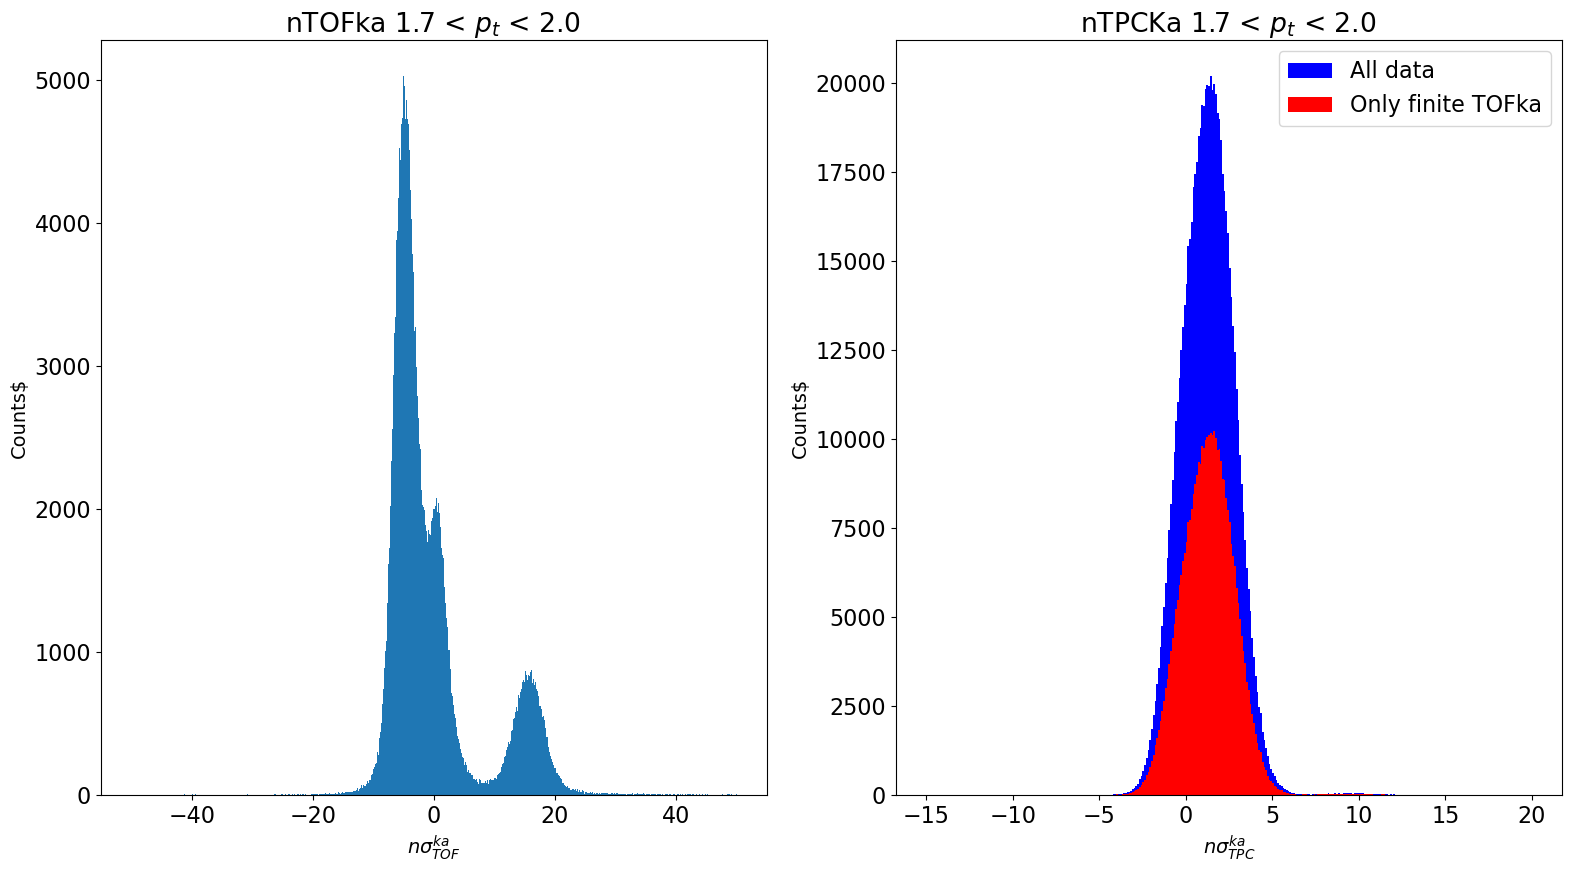

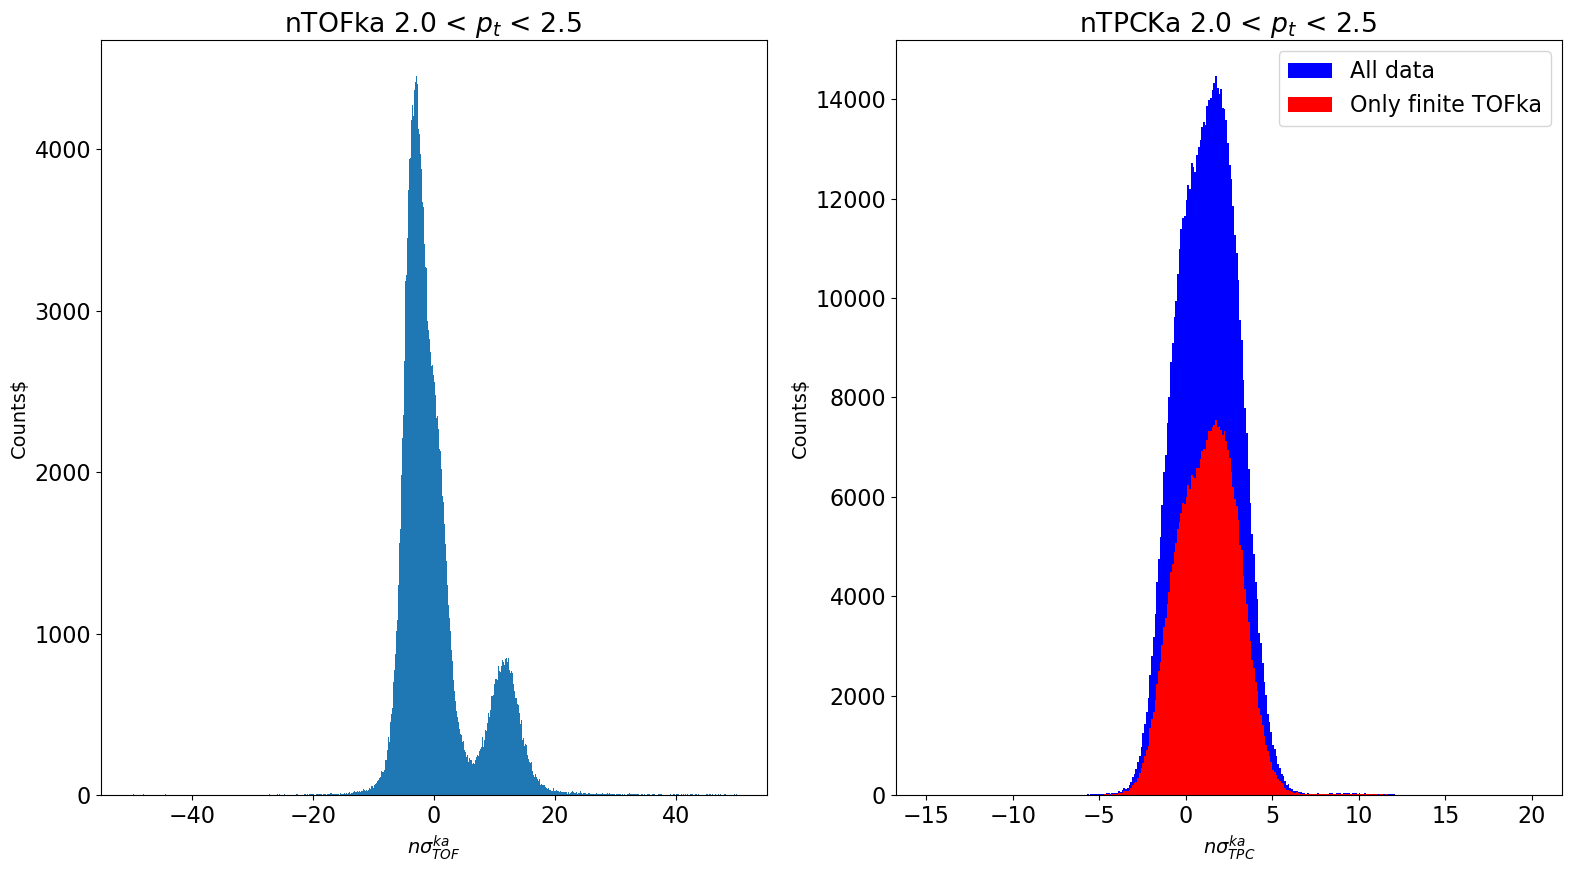

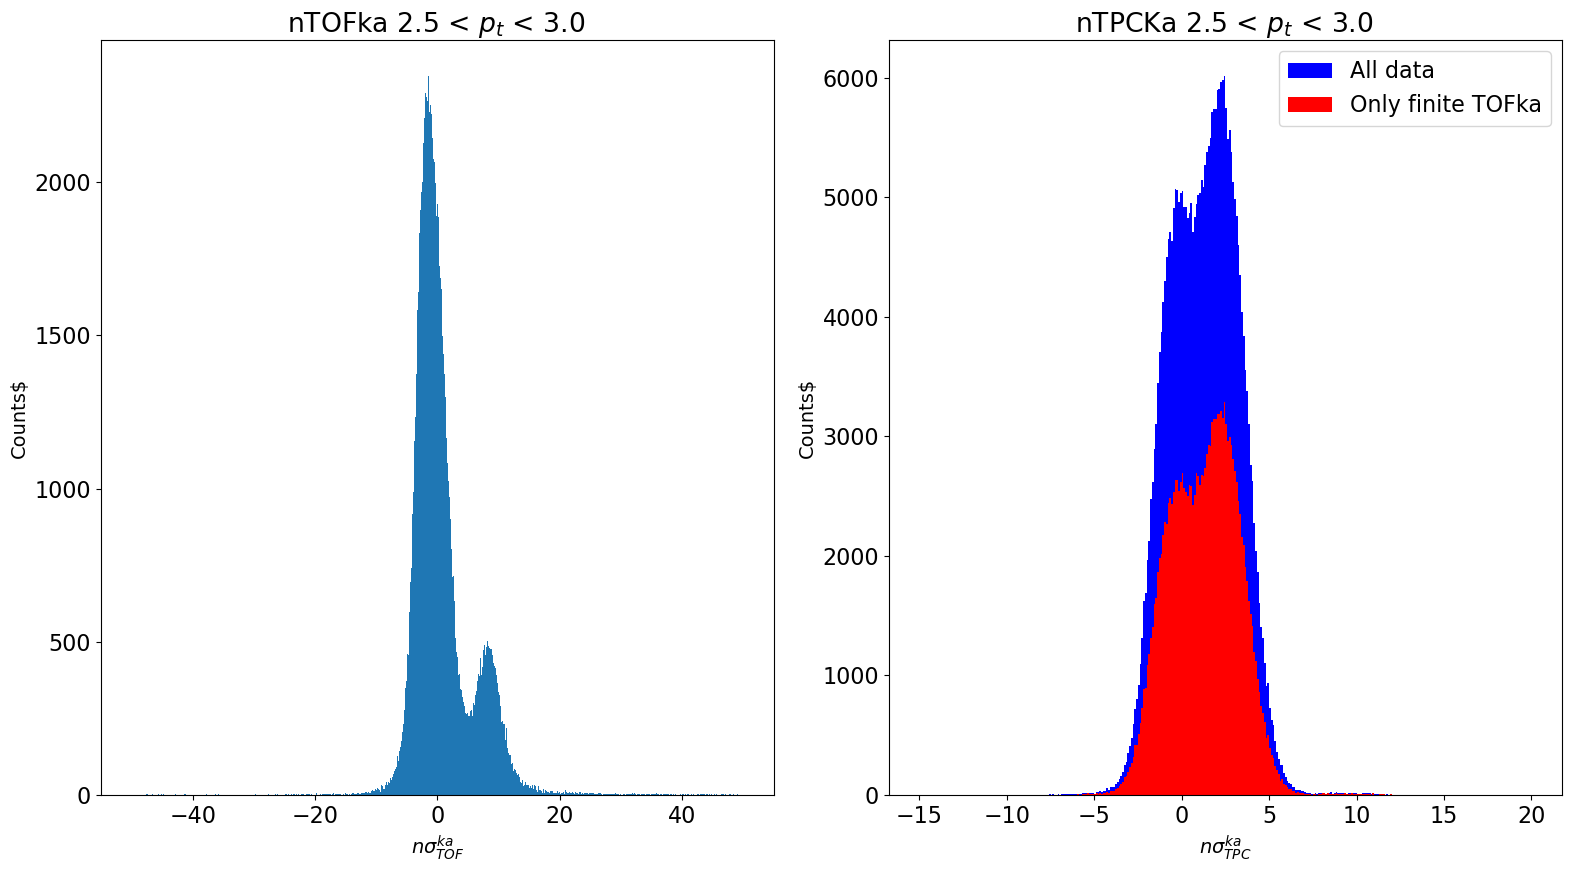

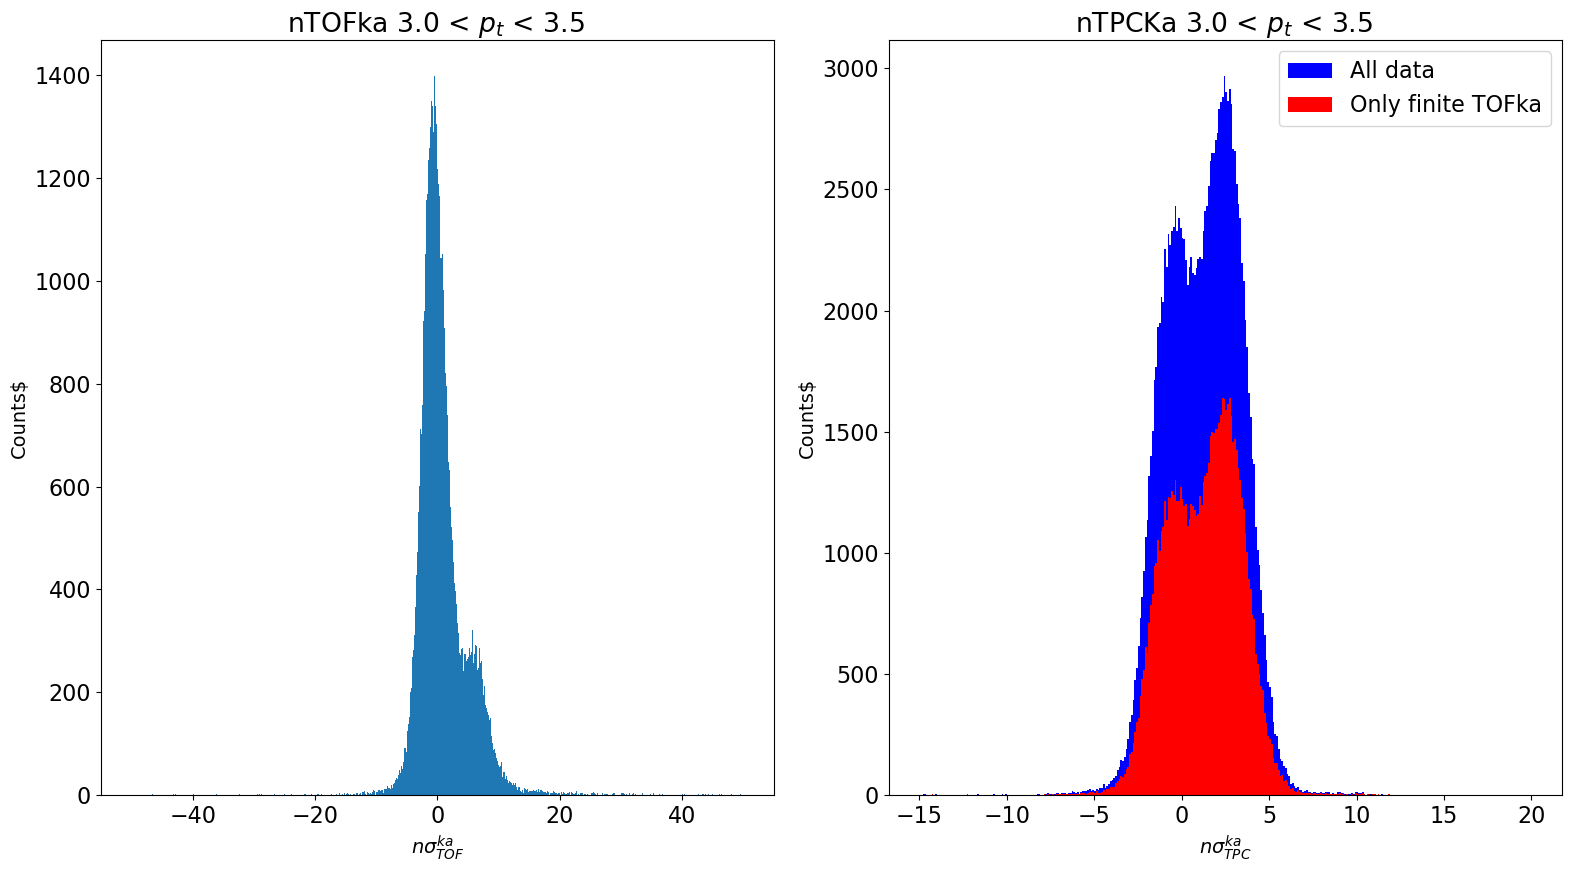

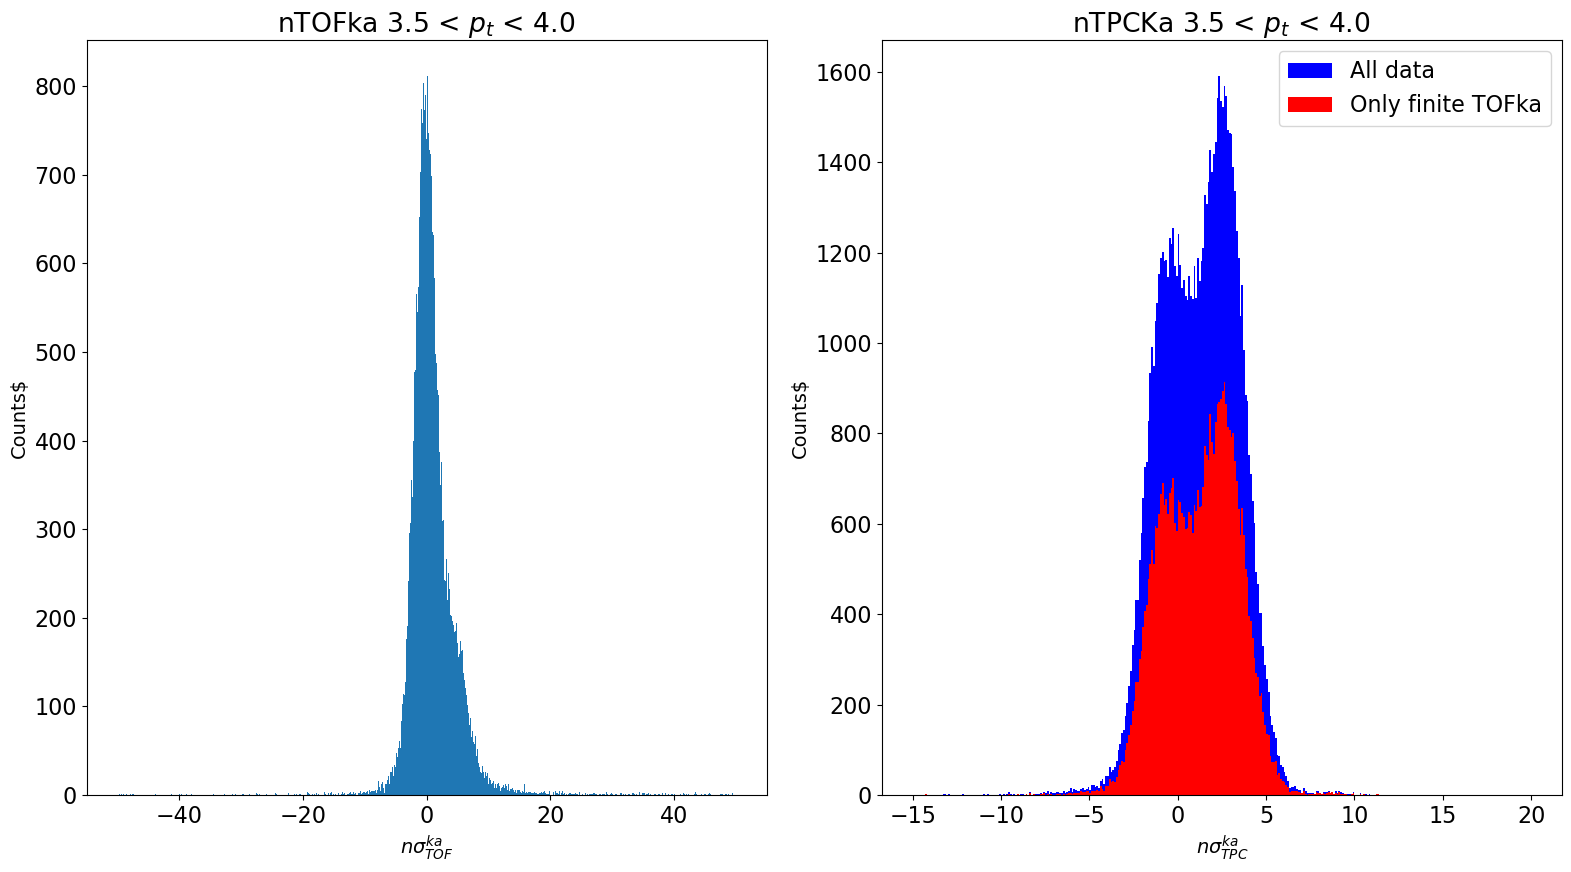

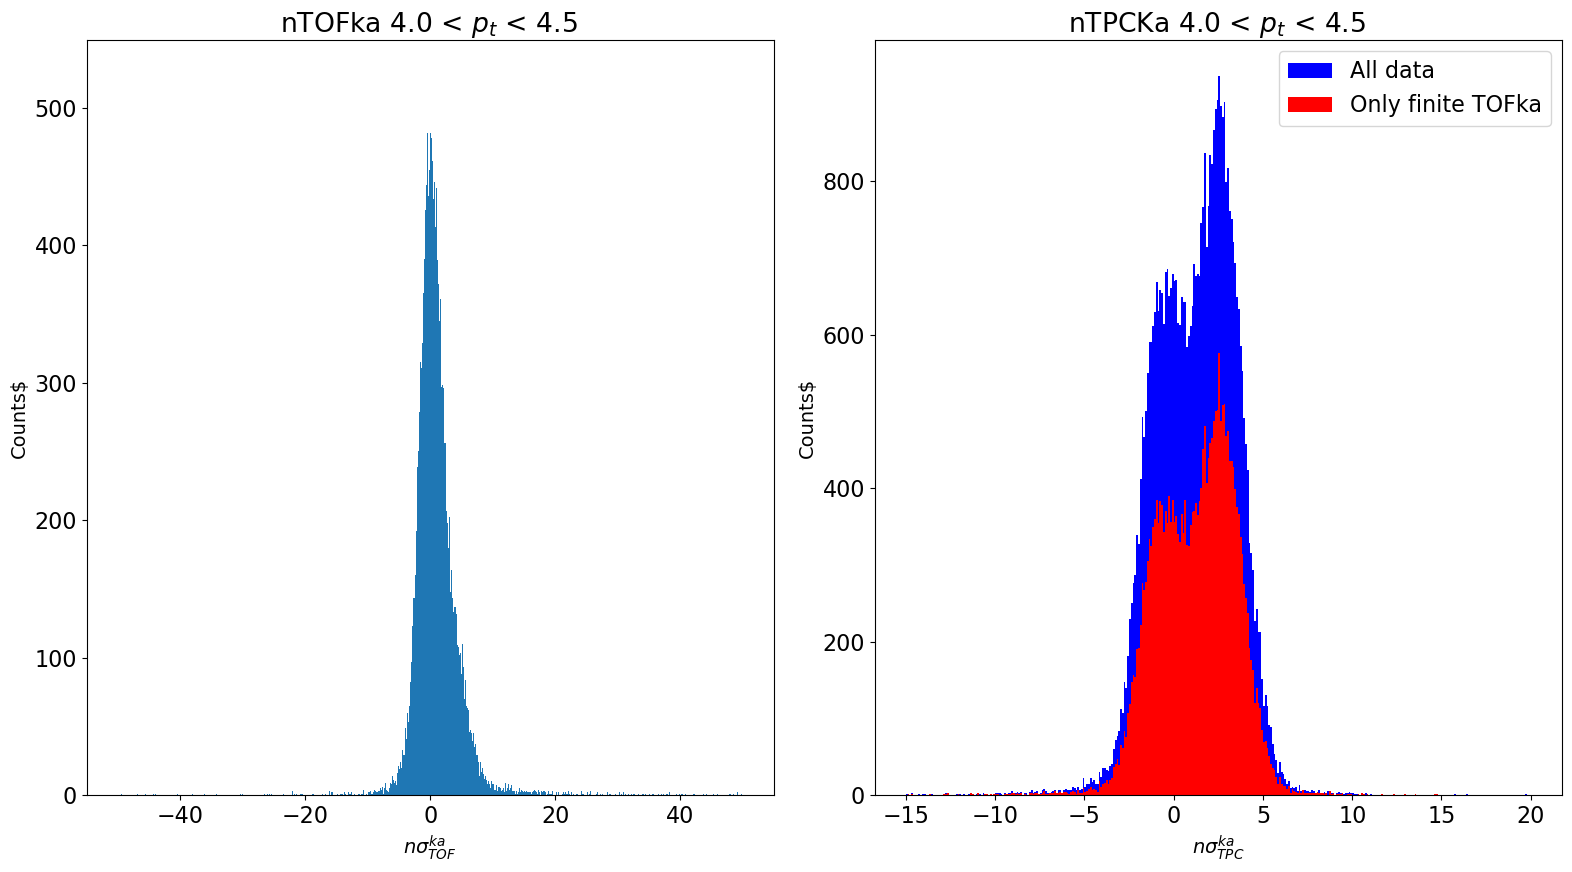

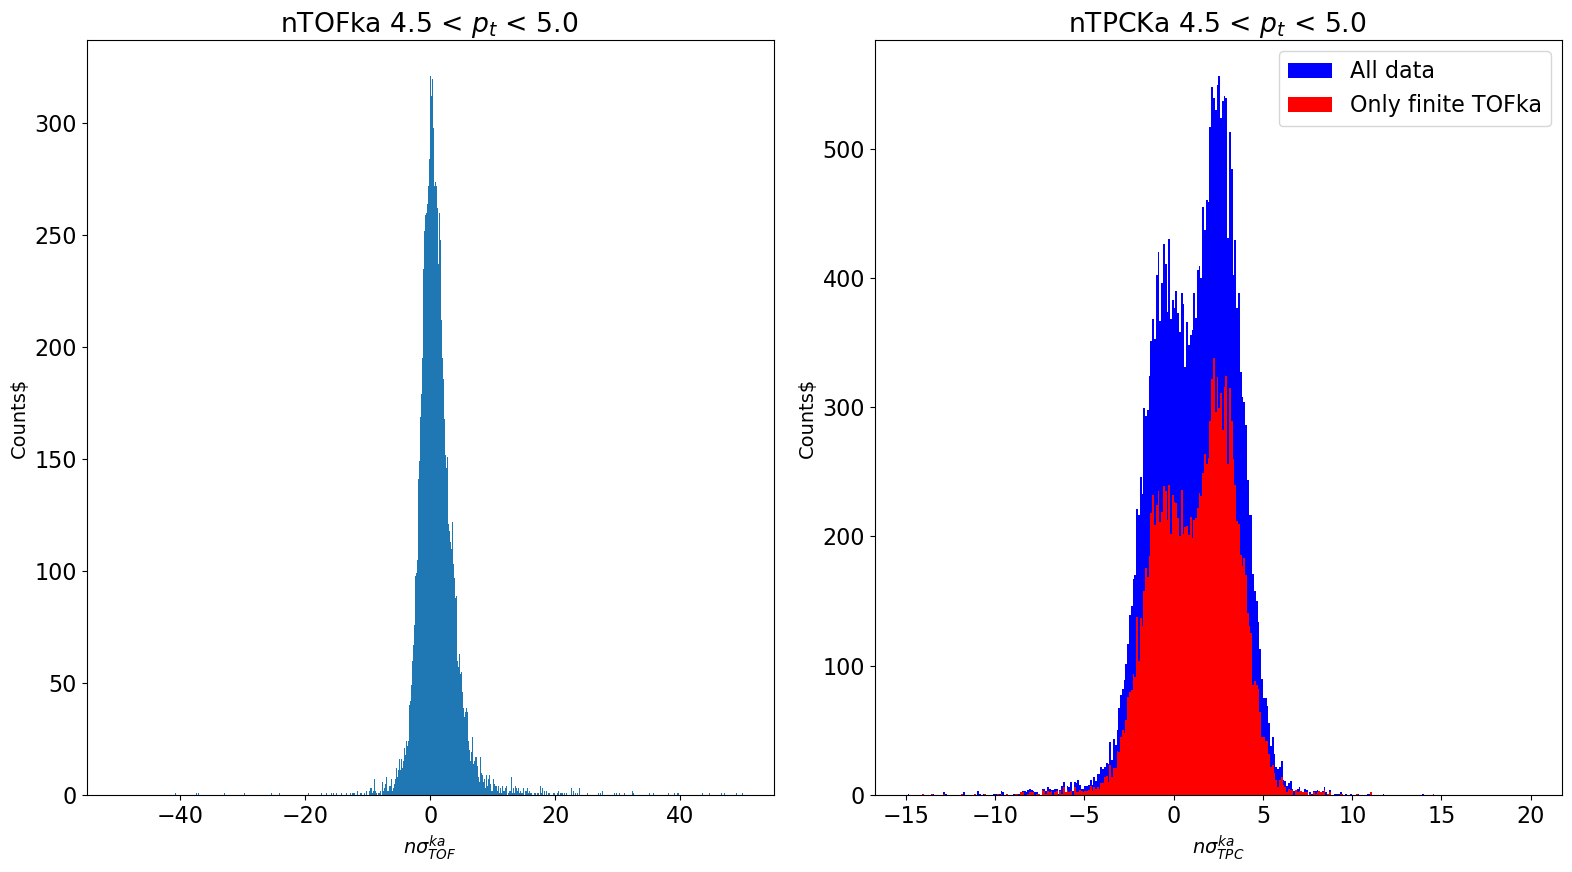

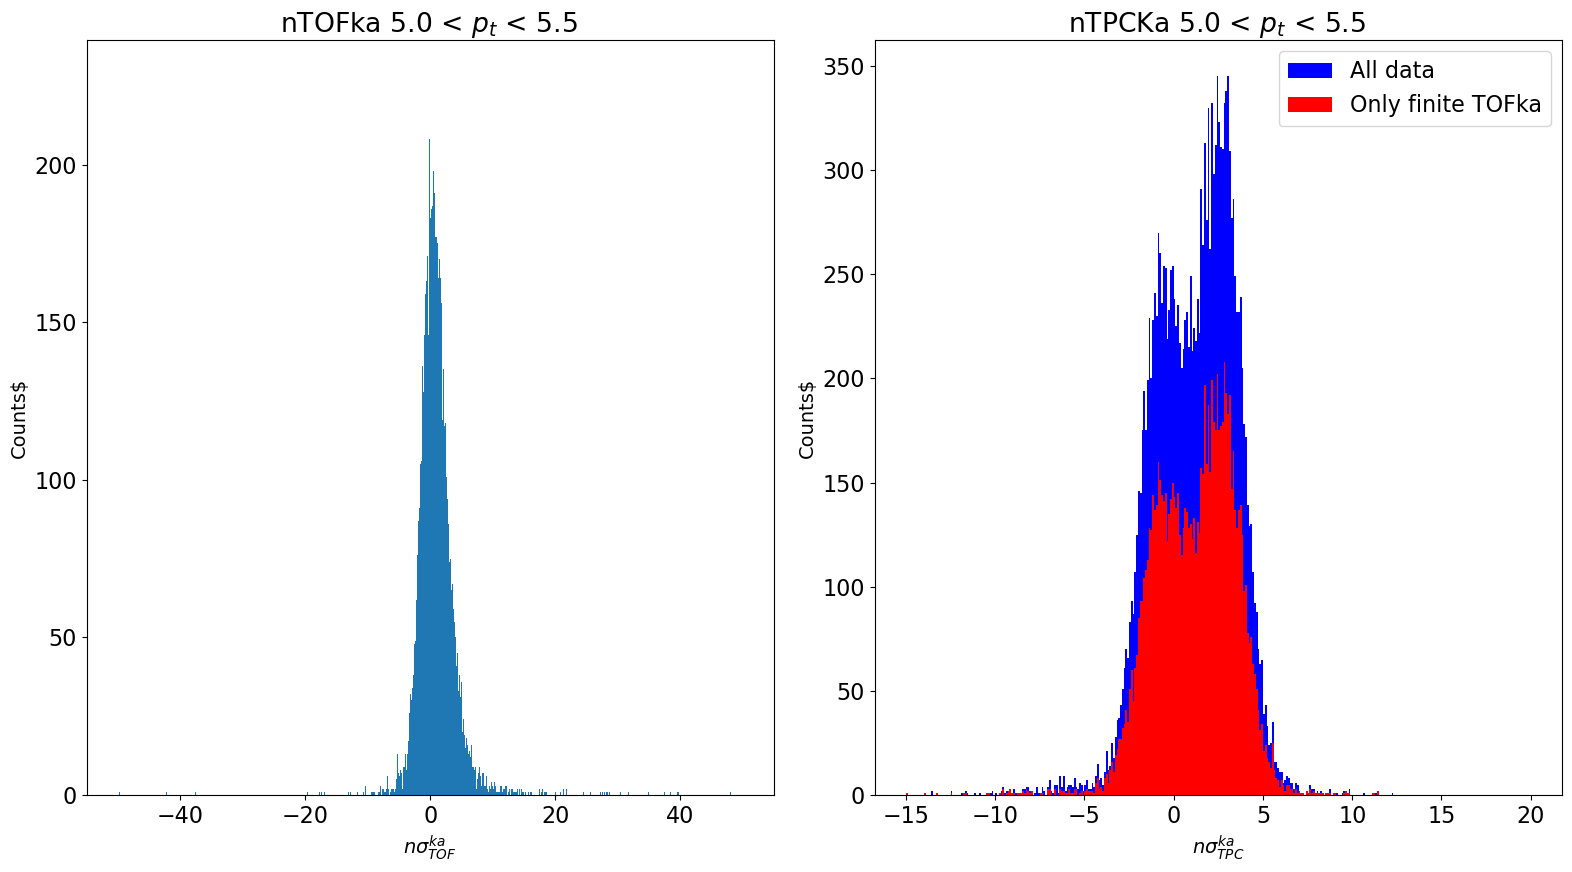

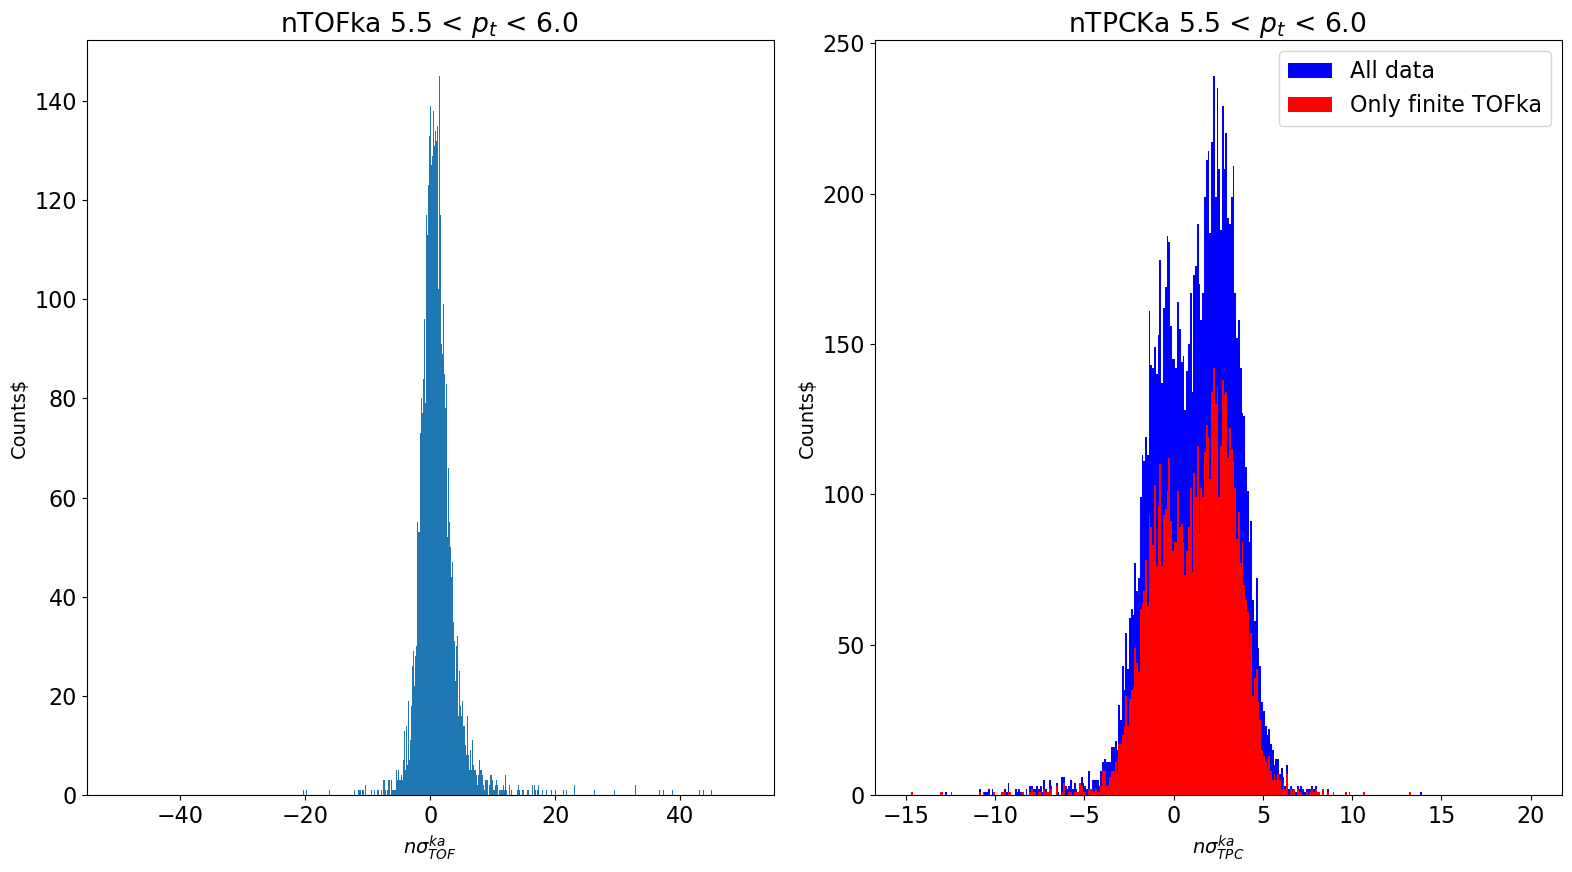

In [83]:
curr_item = 0
bin_width = 0.1
while (curr_item < len(pt_slices) ):
    data = real_data[ real_data["fPt"].between(pt_slices[curr_item][0], pt_slices[curr_item][1]) ][["fNsigmaTOFka", "fNsigmaTPCka"]]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,9))
    ax1.hist(data["fNsigmaTOFka"], range=(-50,50), bins=np.arange(-50,50+bin_width, bin_width) )
    ax1.set_xlabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
    ax1.set_ylabel(r"Counts$", fontsize=fs)
    ax1.set_title(f"nTOFka {pt_slices[curr_item][0]} < $p_t$ < {pt_slices[curr_item][1]} ")
     
    ax2.hist(data["fNsigmaTPCka"], range=(-15,20), bins=np.arange(-15,20+bin_width, bin_width), color="blue", label="All data")
    ax2.set_xlabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
    ax2.set_ylabel(r"Counts$", fontsize=fs)
    ax2.set_title(f"nTPCKa {pt_slices[curr_item][0]} < $p_t$ < {pt_slices[curr_item][1]} ")

    # Does the TPCka change if we only consider those with finite TOFKA?
    ax2.hist(data[data["fNsigmaTOFka"]!=-999]["fNsigmaTPCka"], range=(-15,20), bins=np.arange(-15,20+bin_width, bin_width), color="red", label="Only finite TOFka")
    ax2.legend()
    
    curr_item += 1

    plt.tight_layout()
    plt.show()

## Real data: TOFpi and TPCpi

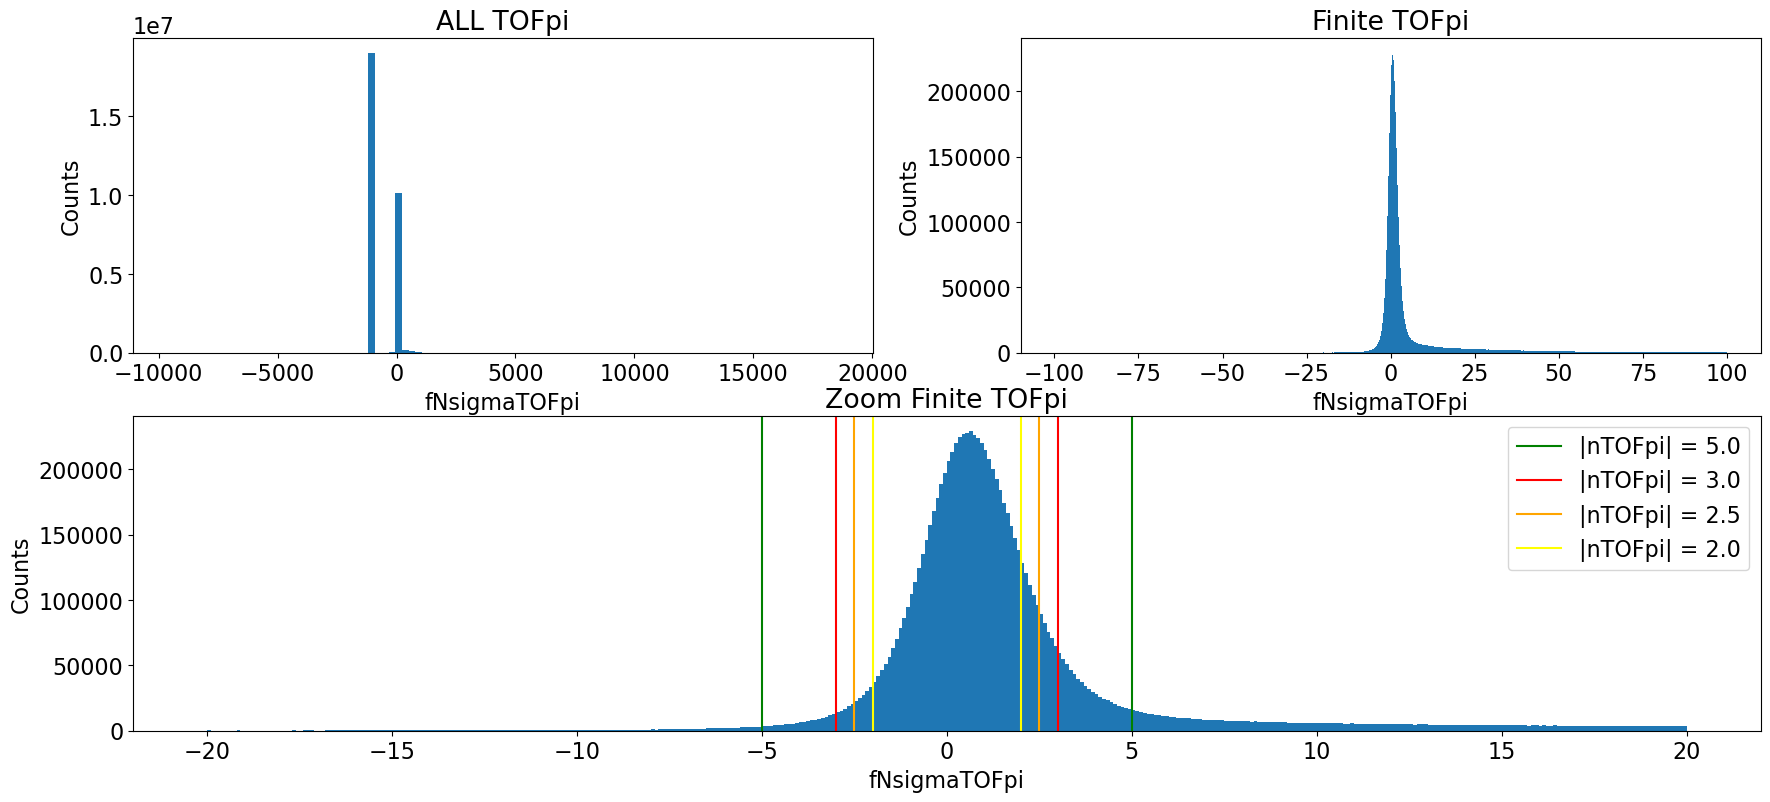

Unavailable TOFpi: 64.42%
TOFpi distribution in % (These are referred to the portion of data whose TOFpi is not -999)


,"[-0.5, 0.5]","[-1, 1]","[-1.5, 1.5]","[-2.0, 2.0]","[-2.5, 2.5]","[-3.0, 3.0]","[-4.0, 4.0]","[-5, 5]","[-7, 7]","[-10, 10]"
% of Finite TOFpi,18.85,35.53,48.79,58.47,65.13,69.58,74.53,77.0,79.56,81.78
% of Total,6.71,12.64,17.36,20.8,23.17,24.76,26.52,27.4,28.31,29.1


In [84]:
N_BINS = 100
bin_width = 0.1

mosaic = [
    ["ALL TOFpi", "Finite TOFpi"],
    ["Finite ZOOM TOFpi", "Finite ZOOM TOFpi"]
]


fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))

NA_TOFpi_mask = real_data["fNsigmaTOFpi"] == -999

axes["ALL TOFpi"].hist(real_data["fNsigmaTOFpi"], bins=N_BINS)
axes["ALL TOFpi"].set_title("ALL TOFpi")
axes["ALL TOFpi"].set_xlabel("fNsigmaTOFpi")
axes["ALL TOFpi"].set_ylabel("Counts")

axes["Finite TOFpi"].hist(real_data[~NA_TOFpi_mask]["fNsigmaTOFpi"], range=(-100,100), bins=np.arange(-100, 100+bin_width, bin_width))
axes["Finite TOFpi"].set_title("Finite TOFpi")
axes["Finite TOFpi"].set_xlabel("fNsigmaTOFpi")
axes["Finite TOFpi"].set_ylabel("Counts")

axes["Finite ZOOM TOFpi"].hist(real_data[~NA_TOFpi_mask]["fNsigmaTOFpi"], range=(-20,20), bins=np.arange(-20,20+bin_width, bin_width))
axes["Finite ZOOM TOFpi"].set_title("Zoom Finite TOFpi")
axes["Finite ZOOM TOFpi"].axvline(x=-5, color="green", label="|nTOFpi| = 5.0")
axes["Finite ZOOM TOFpi"].axvline(x=+5, color="green")
axes["Finite ZOOM TOFpi"].axvline(x=-3, color="red", label="|nTOFpi| = 3.0")
axes["Finite ZOOM TOFpi"].axvline(x=+3, color="red")
axes["Finite ZOOM TOFpi"].axvline(x=-2.5, color="orange", label="|nTOFpi| = 2.5")
axes["Finite ZOOM TOFpi"].axvline(x=+2.5, color="orange")
axes["Finite ZOOM TOFpi"].axvline(x=-2.0, color="yellow", label="|nTOFpi| = 2.0")
axes["Finite ZOOM TOFpi"].axvline(x=+2.0, color="yellow")
axes["Finite ZOOM TOFpi"].set_xlabel("fNsigmaTOFpi")
axes["Finite ZOOM TOFpi"].set_ylabel("Counts")
plt.legend()

plt.show()

tot = len(real_data)
tot_NA_TOFpi = np.sum(NA_TOFpi_mask)
tot_finite_TOFpi = tot - tot_NA_TOFpi
print(f"Unavailable TOFpi: {tot_NA_TOFpi/tot*100:.2f}%")

TOFpi_slice = [ [-0.5,0.5], [-1, 1], [-1.5,1.5], [-2.0,2.0], [-2.5, 2.5], [-3.0, 3.0], [-4.0, 4.0], [-5, 5], [-7,7], [-10,10] ]
TOFpi_bucket = []
for i in range (len(TOFpi_slice)):
    TOFpi_lim = TOFpi_slice[i]
    TOFpi_bucket.append( np.sum(real_data["fNsigmaTOFpi"].between(TOFpi_lim[0], TOFpi_lim[1]))/tot_finite_TOFpi )
TOFpi_recap = pd.DataFrame(columns=[str(item) for item in TOFpi_slice], index=["% of Finite TOFpi", "% of Total"])
TOFpi_recap.loc["% of Finite TOFpi"] = TOFpi_bucket
TOFpi_recap.loc["% of Total"] = np.array(TOFpi_bucket)*tot_finite_TOFpi/tot
pd.set_option("display.precision", 2)
print("TOFpi distribution in % (These are referred to the portion of data whose TOFpi is not -999)")
TOFpi_recap*100

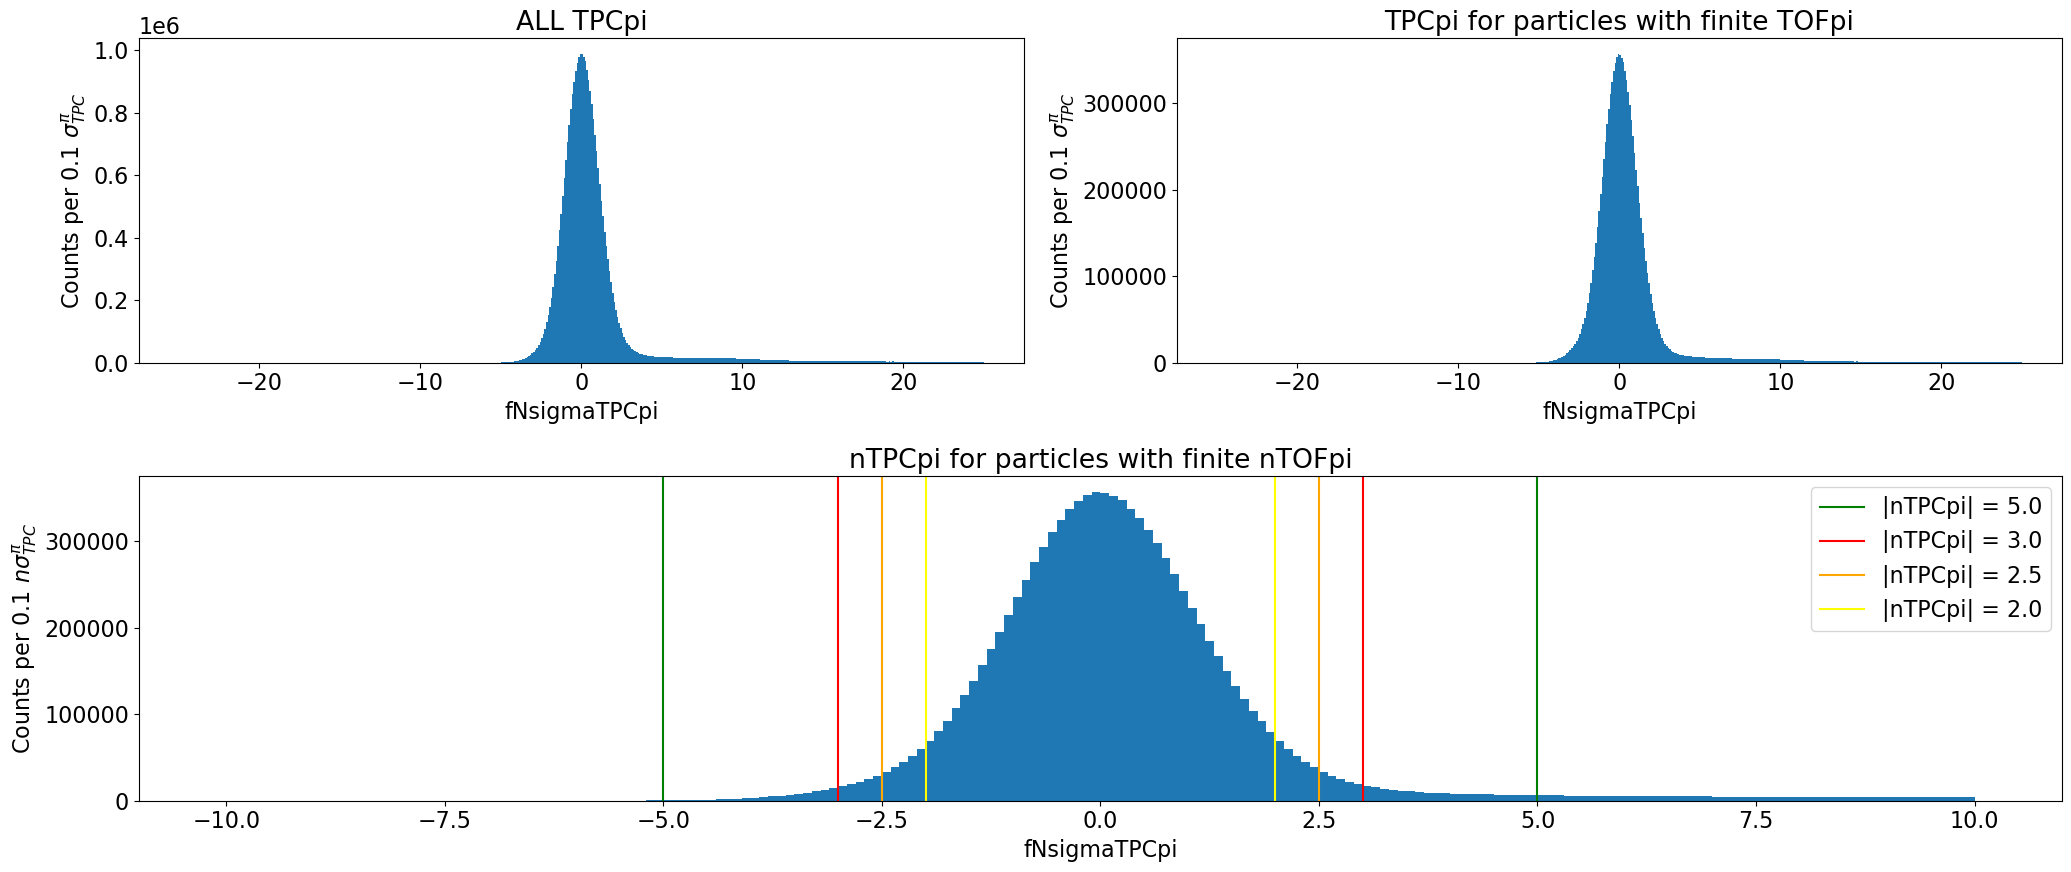

TPCpi distribution in %


,"[-0.5, 0.5]","[-1, 1]","[-1.5, 1.5]","[-2.0, 2.0]","[-2.5, 2.5]","[-3.0, 3.0]","[-4.0, 4.0]","[-5, 5]","[-7, 7]","[-10, 10]"
% of Total,32.27,58.23,75.14,84.35,88.78,90.87,92.56,93.33,94.44,95.89


In [85]:
# I fix the bin width instead of number of bins for an easier comparison between the various graphs
bin_width = 0.1

mosaic = [
    ["ALL TPCpi", "Finite TPCpi"],
    ["ZOOM TPCpi", "ZOOM TPCpi"]
]

fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))

axes["ALL TPCpi"].hist(real_data["fNsigmaTPCpi"],range=(-25,25), bins=np.arange(-25,25+bin_width, bin_width ) )
axes["ALL TPCpi"].set_title("ALL TPCpi")
axes["ALL TPCpi"].set_xlabel("fNsigmaTPCpi")
axes["ALL TPCpi"].set_ylabel(f"Counts per {bin_width} " + r"$\sigma_{TPC}^{\pi}$")

axes["Finite TPCpi"].hist(real_data[~NA_TOFpi_mask]["fNsigmaTPCpi"], range=(-25,25), bins=np.arange(-25,25+bin_width, bin_width ))
axes["Finite TPCpi"].set_title("TPCpi for particles with finite TOFpi")
axes["Finite TPCpi"].set_xlabel("fNsigmaTPCpi")
axes["Finite TPCpi"].set_ylabel(f"Counts per {bin_width} " + r"$\sigma_{TPC}^{\pi}$")

axes["ZOOM TPCpi"].hist(real_data[~NA_TOFpi_mask]["fNsigmaTPCpi"], range=(-10,10), bins=np.arange(-10,10+bin_width, bin_width ))
axes["ZOOM TPCpi"].set_title("nTPCpi for particles with finite nTOFpi")
axes["ZOOM TPCpi"].axvline(x=-5, color="green", label="|nTPCpi| = 5.0")
axes["ZOOM TPCpi"].axvline(x=+5, color="green")
axes["ZOOM TPCpi"].axvline(x=-3, color="red", label="|nTPCpi| = 3.0")
axes["ZOOM TPCpi"].axvline(x=+3, color="red")
axes["ZOOM TPCpi"].axvline(x=-2.5, color="orange", label="|nTPCpi| = 2.5")
axes["ZOOM TPCpi"].axvline(x=+2.5, color="orange")
axes["ZOOM TPCpi"].axvline(x=-2.0, color="yellow", label="|nTPCpi| = 2.0")
axes["ZOOM TPCpi"].axvline(x=+2.0, color="yellow")
axes["ZOOM TPCpi"].set_xlabel("fNsigmaTPCpi")
axes["ZOOM TPCpi"].set_ylabel(f"Counts per {bin_width} " + r"$n\sigma_{TPC}^{\pi}$")
plt.legend()

plt.tight_layout()
plt.show()

TPCpi_slice = [ [-0.5,0.5], [-1, 1], [-1.5,1.5], [-2.0,2.0], [-2.5, 2.5], [-3.0, 3.0], [-4.0, 4.0], [-5, 5], [-7,7], [-10,10] ]
TPCpi_bucket = []
for i in range (len(TPCpi_slice)):
    TPCpi_lim = TPCpi_slice[i]
    TPCpi_bucket.append( np.sum(real_data["fNsigmaTPCpi"].between(TPCpi_lim[0], TPCpi_lim[1]))/tot)
TPCpi_recap = pd.DataFrame(columns=[str(item) for item in TOFpi_slice], index=["% of Total"])
TPCpi_recap.loc["% of Total"] = TPCpi_bucket
pd.set_option("display.precision", 2)
print("TPCpi distribution in %")
TPCpi_recap*100

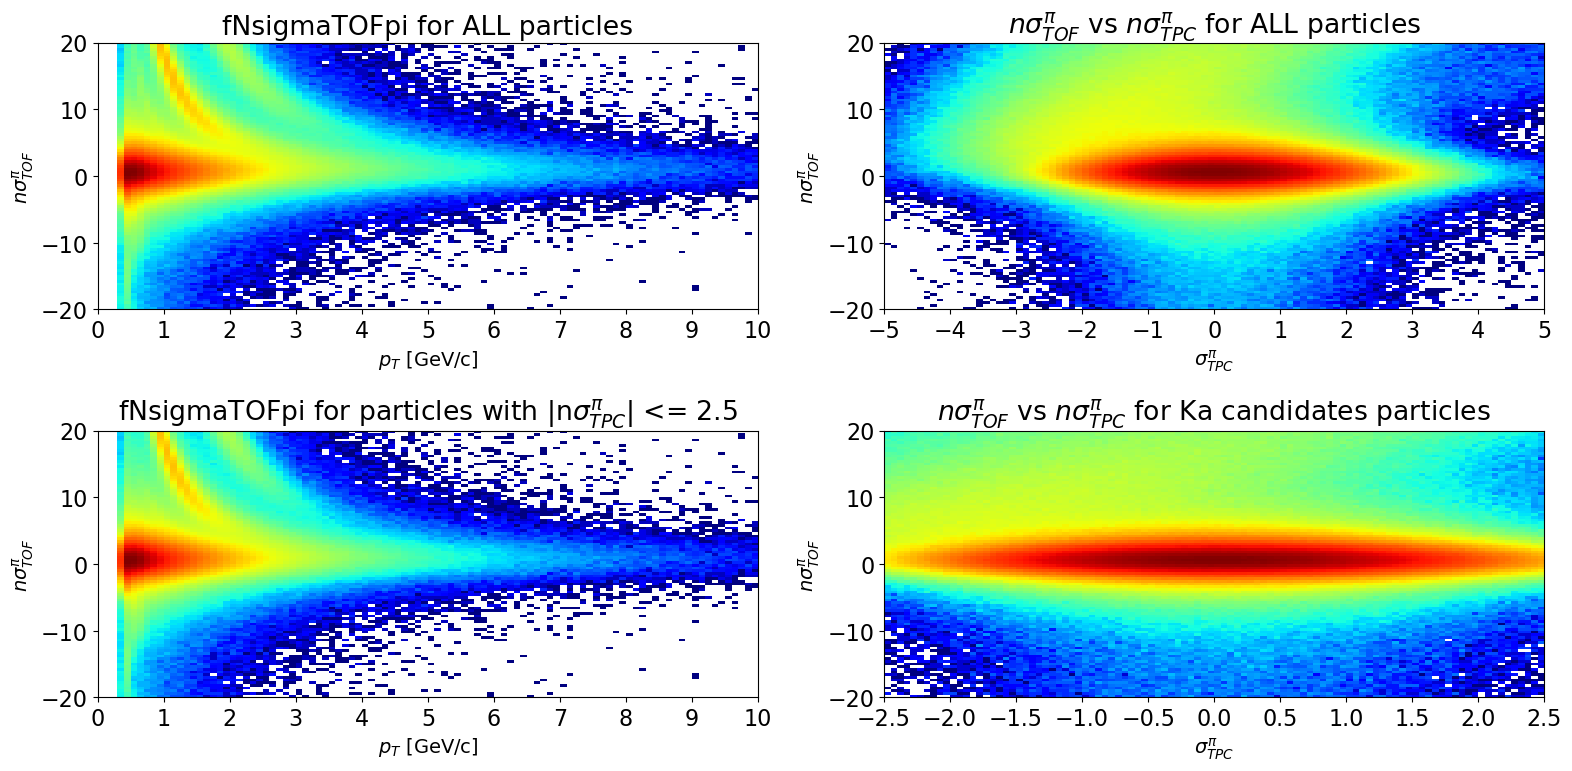

In [87]:
min_cut_TOF_PI, max_cut_TOF_PI = -20.0, 20.0
min_cut_TPC_PI, max_cut_TPC_PI = -5.0, 5.0
p_cut_lower, p_cut_upper = 0, 10

mosaic = [ ["top left", "top right"],
           ["bot left", "bot right"]
         ]

fs = 14
p_cut_lower = 0
p_cut_upper = 10
fig, axes = plt.subplot_mosaic(mosaic, figsize=(16, 8))
axes["top left"].hist2d(real_data["fPt"], real_data["fNsigmaTOFpi"] , (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[min_cut_TOF_PI,max_cut_TOF_PI]]))
# plt.colorbar(ax=axes["top"])
axes["top left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top left"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["top left"].set_xlim(p_cut_lower, p_cut_upper )
axes["top left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top left"].set_title("fNsigmaTOFpi for ALL particles")

axes["top right"].hist2d(real_data["fNsigmaTPCpi"], real_data["fNsigmaTOFpi"] , (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[min_cut_TPC_PI,max_cut_TPC_PI],[min_cut_TOF_PI,max_cut_TOF_PI]]))
# plt.colorbar(ax=axes["top"])
axes["top right"].set_xlabel(r"$\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["top right"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["top right"].set_xlim(min_cut_TPC_PI, max_cut_TPC_PI )
axes["top right"].set_xticks(np.arange(min_cut_TPC_PI, max_cut_TPC_PI+1, 1) )
axes["top right"].set_title(r"$n\sigma^{\pi}_{TOF}$ vs $n\sigma^{\pi}_{TPC}$ for ALL particles")

# Let's see for those that are more likely to be actual Kaons
TPCpi_cut = 2.5
TPC_pi_mask = real_data["fNsigmaTPCpi"].abs() <= TPCpi_cut

axes["bot left"].hist2d(real_data[TPC_pi_mask]["fPt"], real_data[TPC_pi_mask]["fNsigmaTOFpi"] , (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[min_cut_TOF_PI,max_cut_TOF_PI]]))
# plt.colorbar(ax=axes["top"])
axes["bot left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["bot left"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["bot left"].set_xlim(p_cut_lower, p_cut_upper )
axes["bot left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["bot left"].set_title(r"fNsigmaTOFpi for particles with |n$\sigma^{\pi}_{TPC}$| <= " + f"{TPCpi_cut:.1f}")

axes["bot right"].hist2d(real_data[TPC_pi_mask]["fNsigmaTPCpi"], real_data[TPC_pi_mask]["fNsigmaTOFpi"] , (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[-TPCpi_cut,+TPCpi_cut],[min_cut_TOF_PI,max_cut_TOF_PI]]))
# plt.colorbar(ax=axes["top"])
axes["bot right"].set_xlabel(r"$\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["bot right"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["bot right"].set_xlim(-TPCpi_cut, +TPCpi_cut )
axes["bot right"].set_xticks(np.arange(-TPCpi_cut, TPCpi_cut+0.5, 0.5) )
axes["bot right"].set_title(r"$n\sigma^{\pi}_{TOF}$ vs $n\sigma^{\pi}_{TPC}$ for pi candidates particles")
# axes["bot right"].axhline(y=-5, color="green", label="|nTOFpi| = 5.0")
# axes["bot right"].axhline(y=+5, color="green")
# axes["bot right"].axhline(y=-3, color="red", label="|nTOFpi| = 3.0")
# axes["bot right"].axhline(y=+3, color="red", label="|nTOFpi| = 3.0")

plt.tight_layout()
plt.show()

## Real data: TOFpi and TPCpi, now in pt_slice (This is the pt of the unknown daughter particle)

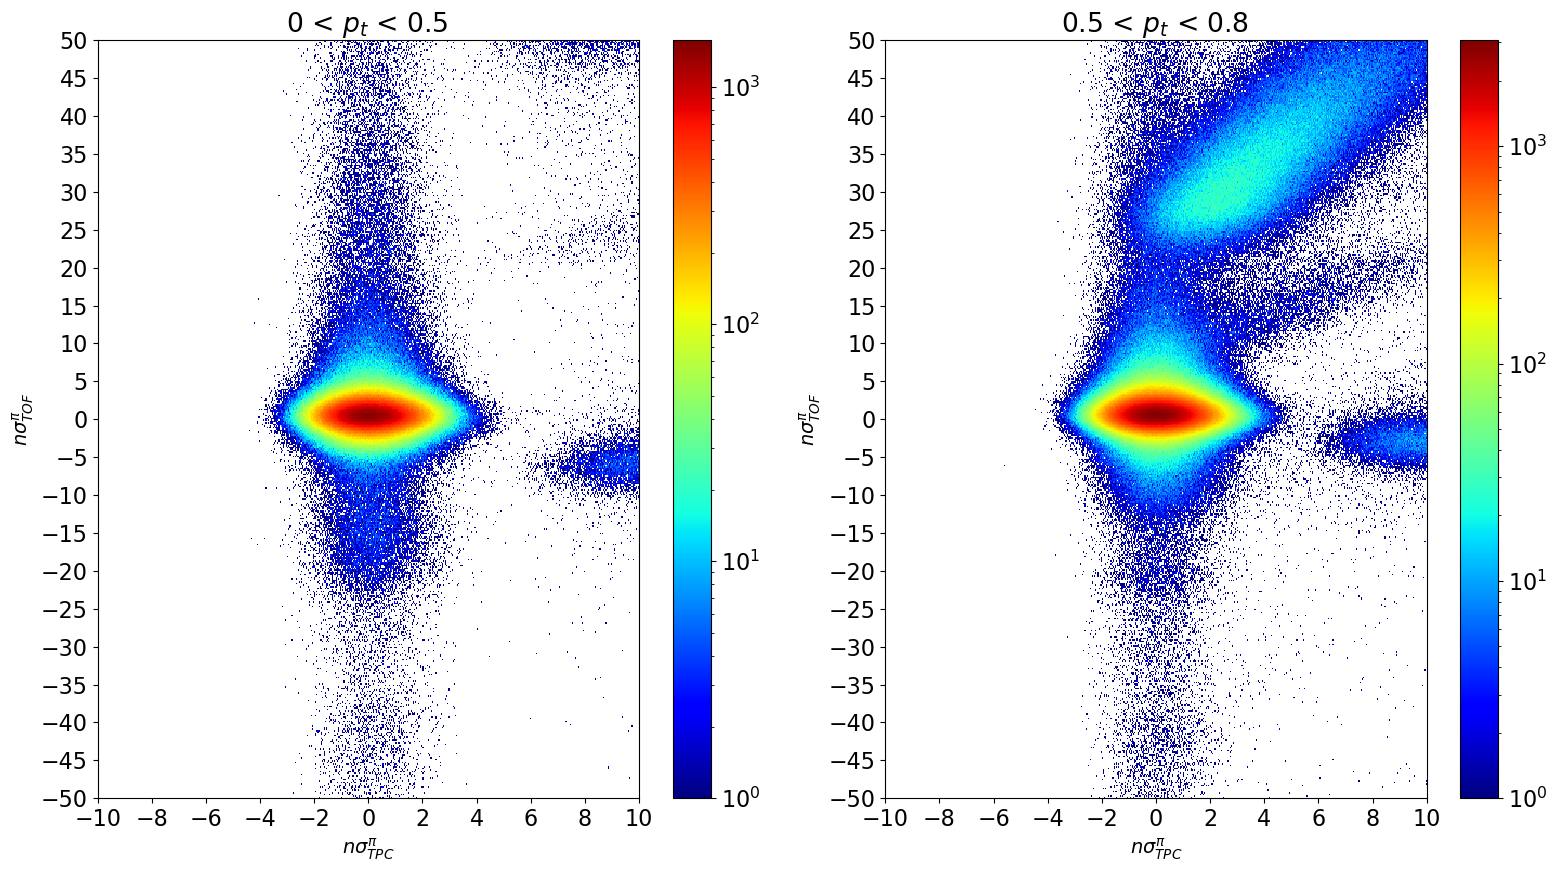

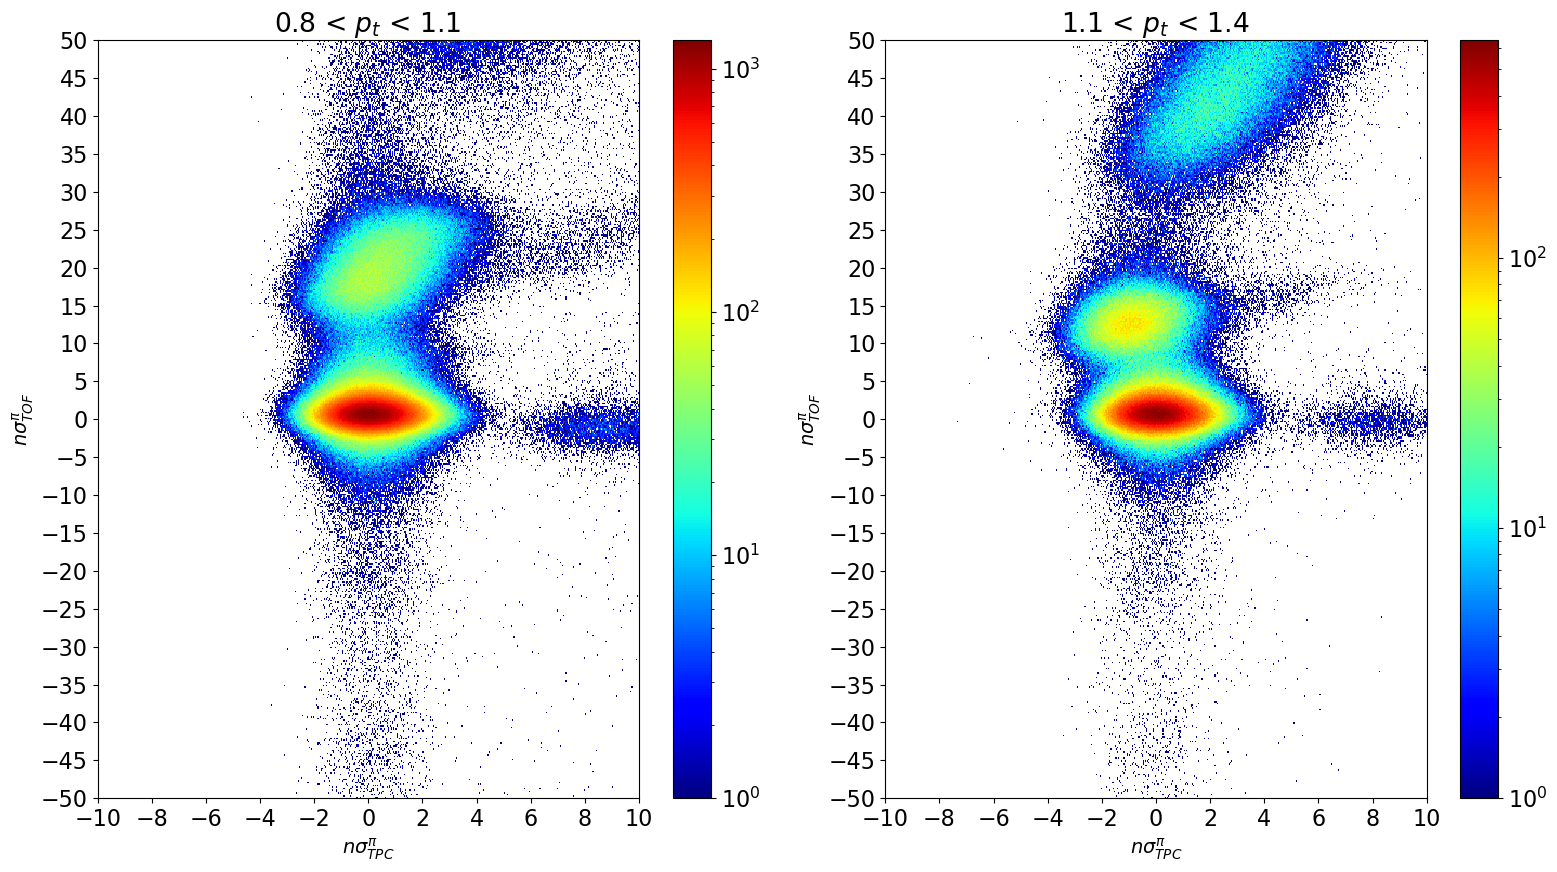

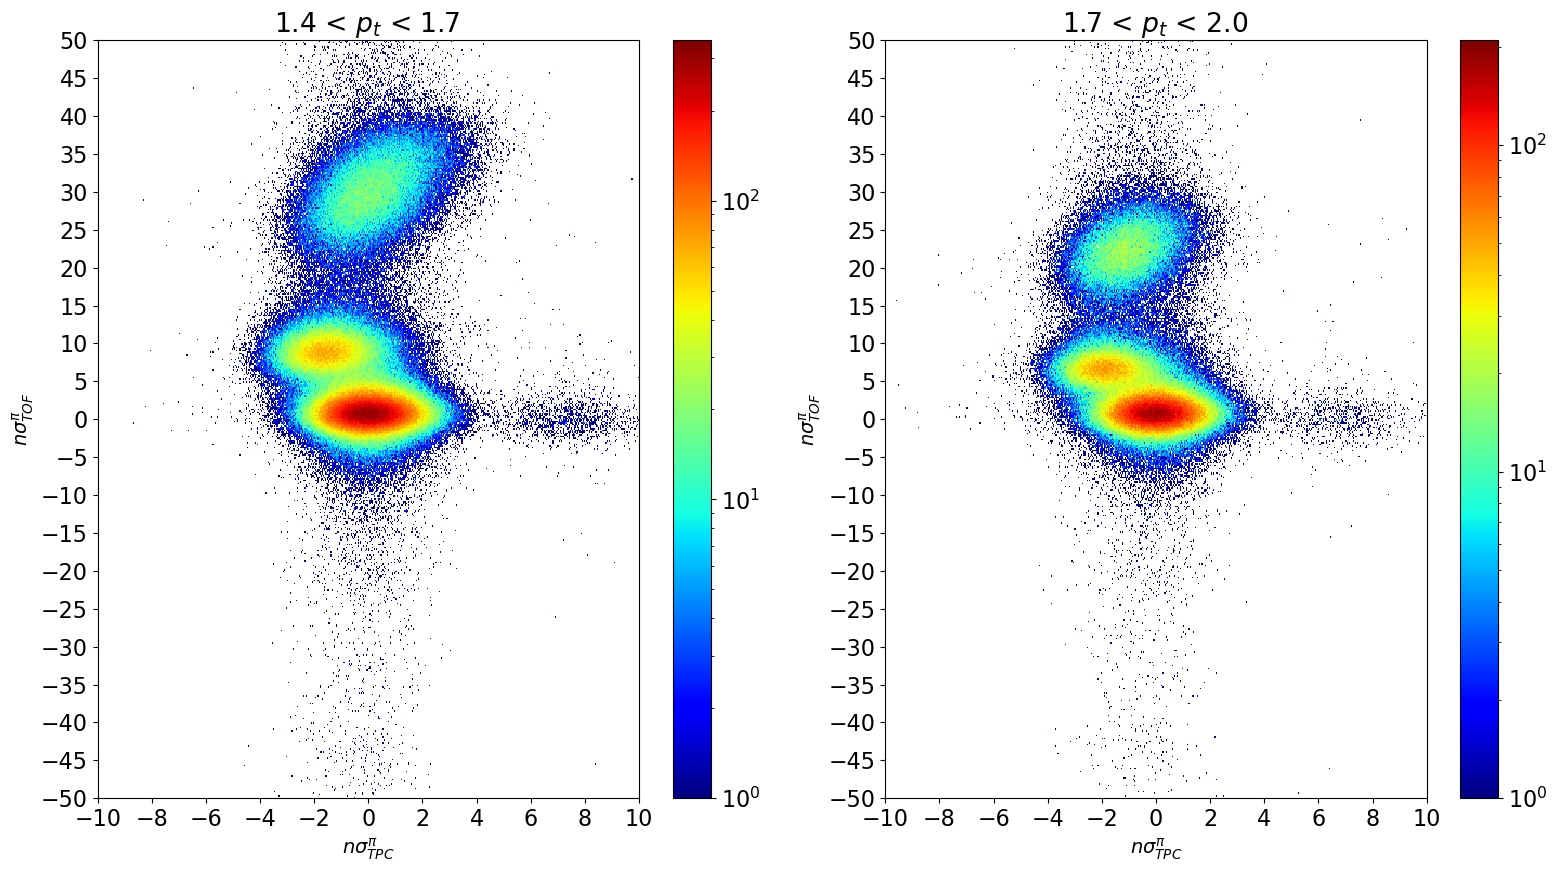

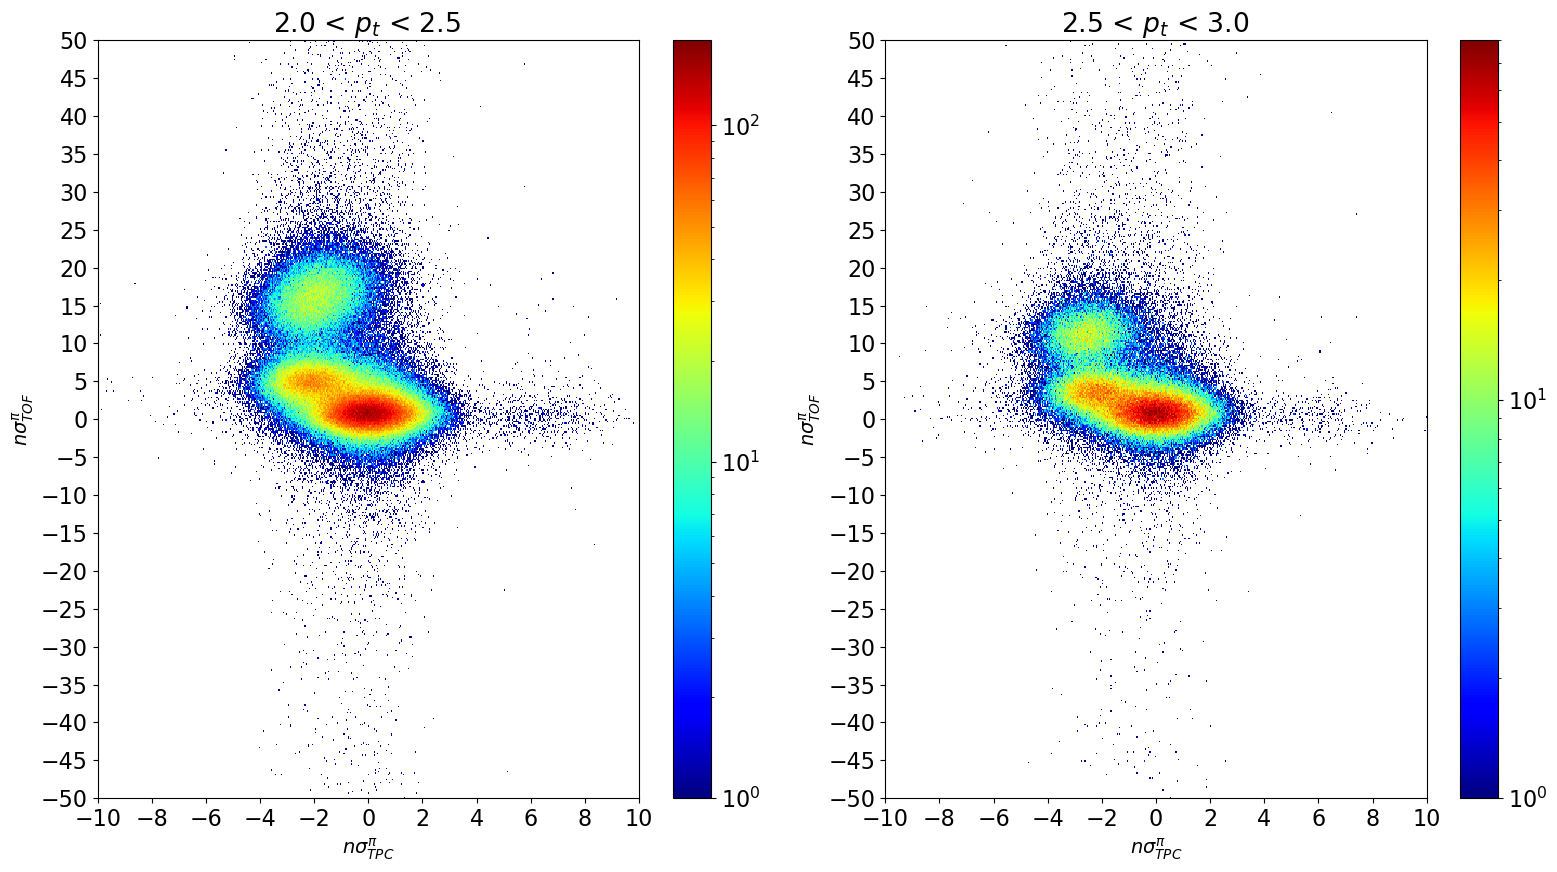

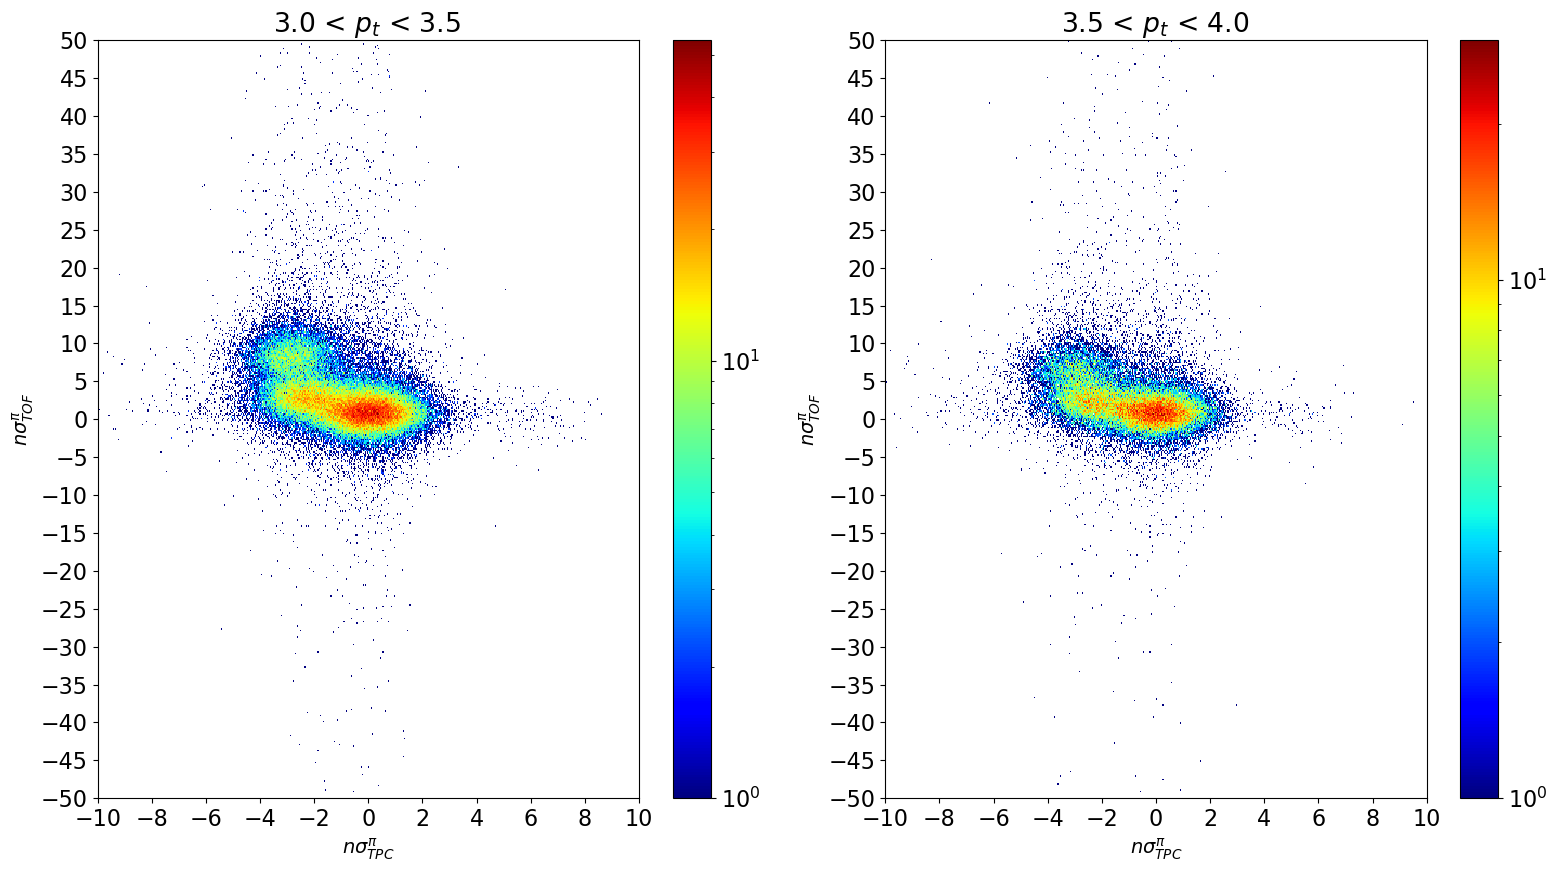

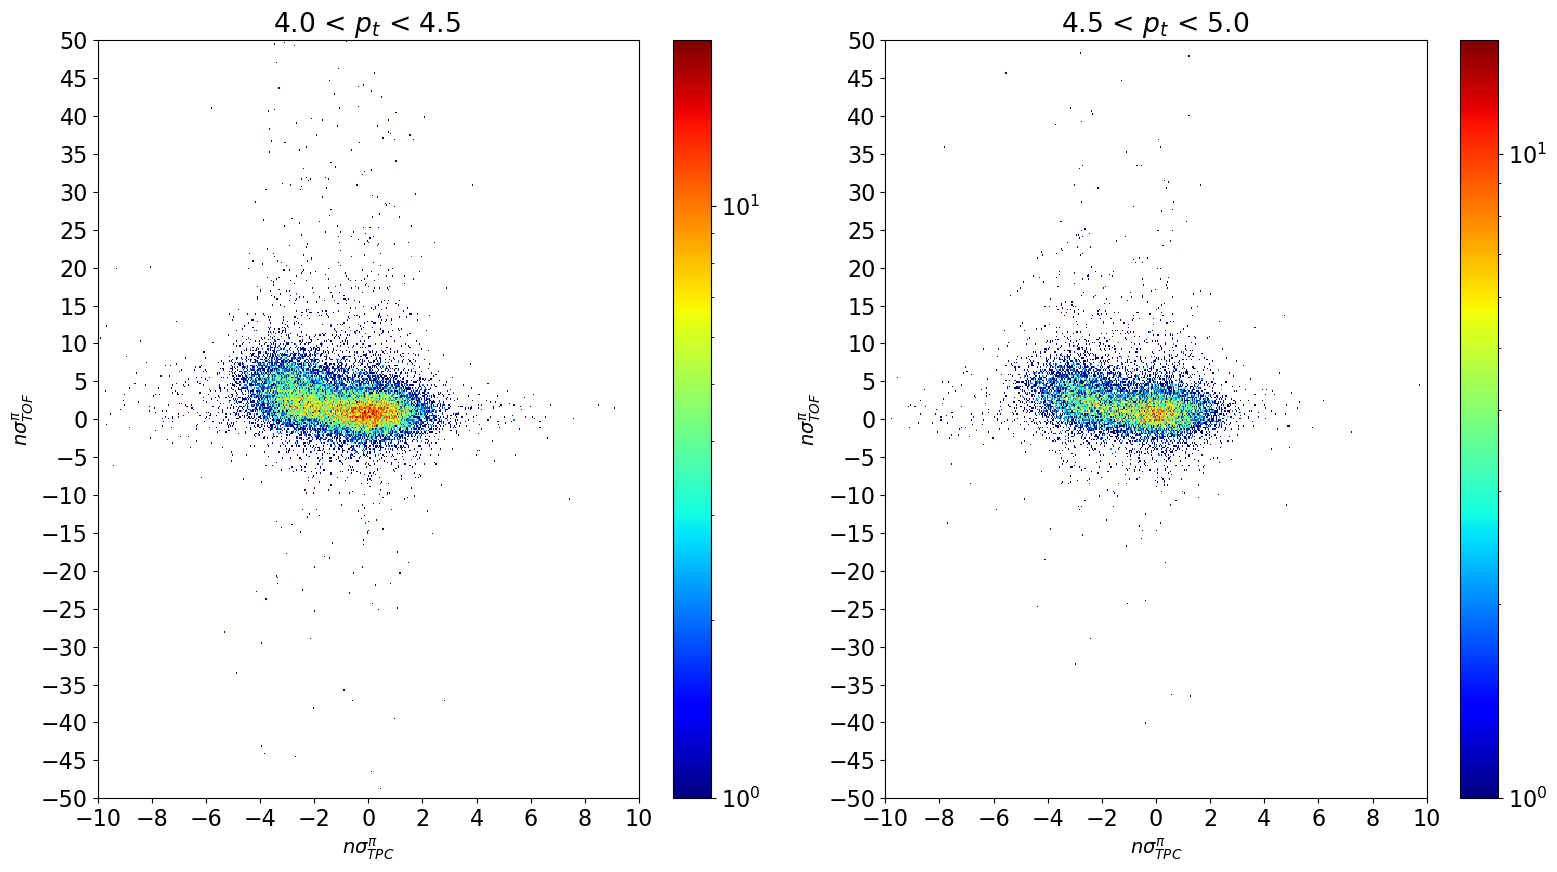

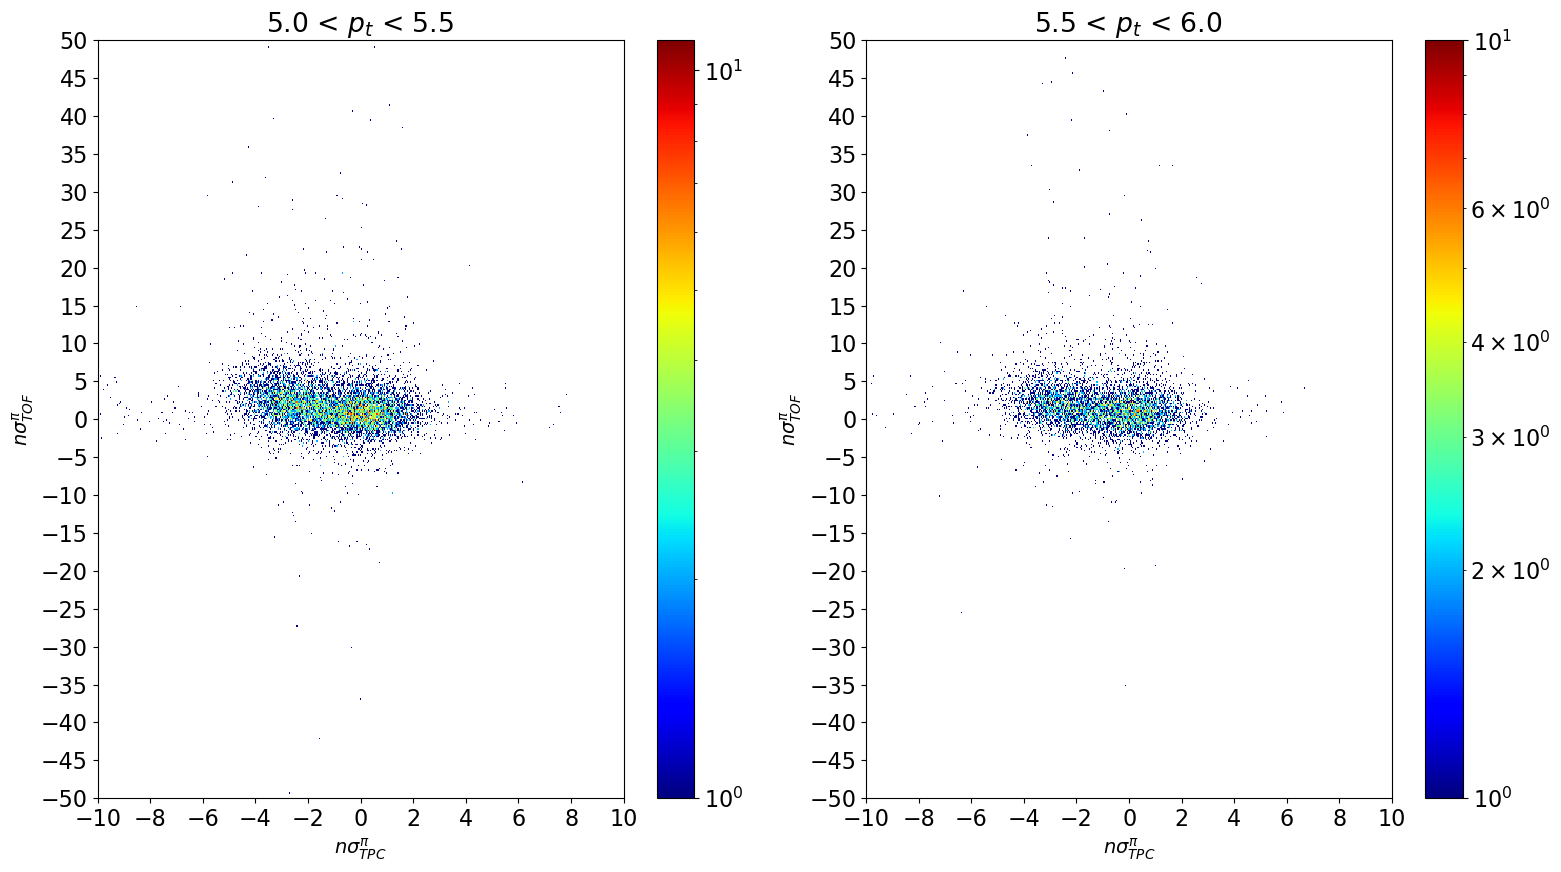

In [88]:
pt_slices = [ [0, 0.5], [0.5, 0.8], [0.8, 1.1], [1.1, 1.4], [1.4, 1.7], [1.7, 2.0], [2.0, 2.5], [2.5, 3.0], [3.0, 3.5], [3.5, 4.0],
              [4.0, 4.5], [4.5, 5.0], [5.0, 5.5], [5.5,6.0]
            ]
curr_item = 0
while (curr_item < len(pt_slices) ):
    data = real_data[ real_data["fPt"].between(pt_slices[curr_item][0], pt_slices[curr_item][1]) ]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,9))
    h = ax1.hist2d(data["fNsigmaTPCpi"],data["fNsigmaTOFpi"], (500, 500), cmap="jet", norm=LogNorm(), range=([[-10,10], [-50,50]]) )
    fig.colorbar(h[3], ax=ax1)
    ax1.set_xlabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
    ax1.set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
    ax1.set_xlim(-10,10)
    ax1.set_xticks(np.arange(-10,10+2,2))
    ax1.set_ylim(-50,50)
    ax1.set_yticks(np.arange(-50,50+5,5))
    ax1.set_title(f"{pt_slices[curr_item][0]} < $p_t$ < {pt_slices[curr_item][1]} ")

    data = real_data[ real_data["fPt"].between(pt_slices[curr_item+1][0], pt_slices[curr_item+1][1]) ]
     
    h2 = ax2.hist2d(data["fNsigmaTPCpi"], data["fNsigmaTOFpi"], (500, 500), cmap="jet", norm=LogNorm(), range=([[-10,10], [-50,50]]))
    fig.colorbar(h2[3], ax=ax2)
    ax2.set_xlabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
    ax2.set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
    ax2.set_xlim(-10,10)
    ax2.set_xticks(np.arange(-10,10+2,2))
    ax2.set_ylim(-50,50)
    ax2.set_yticks(np.arange(-50,50+5,5))
    ax2.set_title(f"{pt_slices[curr_item+1][0]} < $p_t$ < {pt_slices[curr_item+1][1]} ")

    curr_item += 2

    plt.tight_layout()
    plt.show()

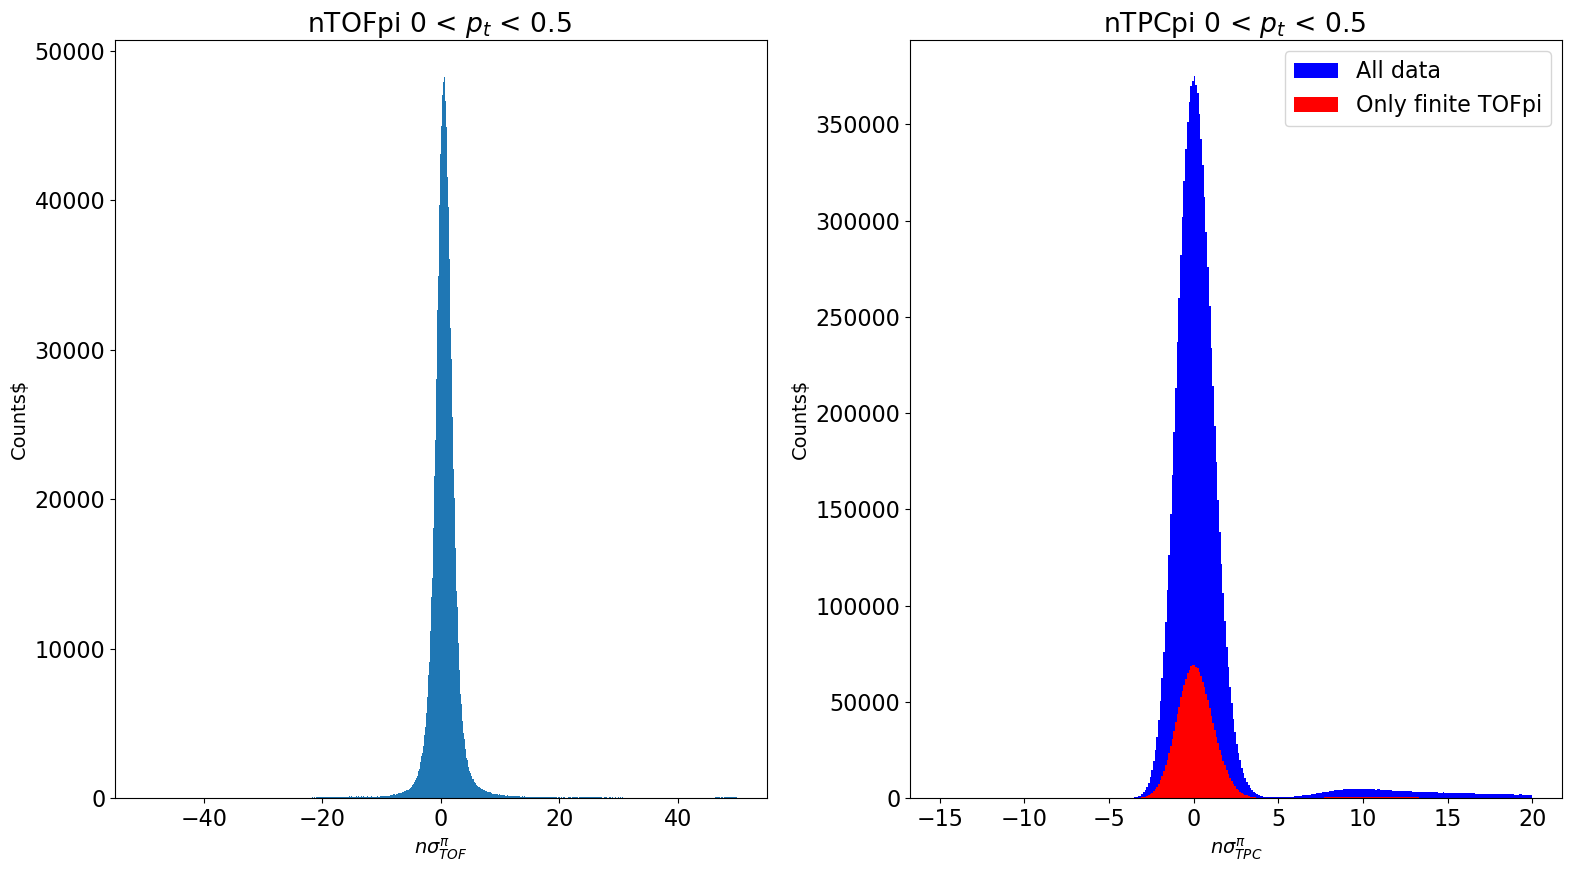

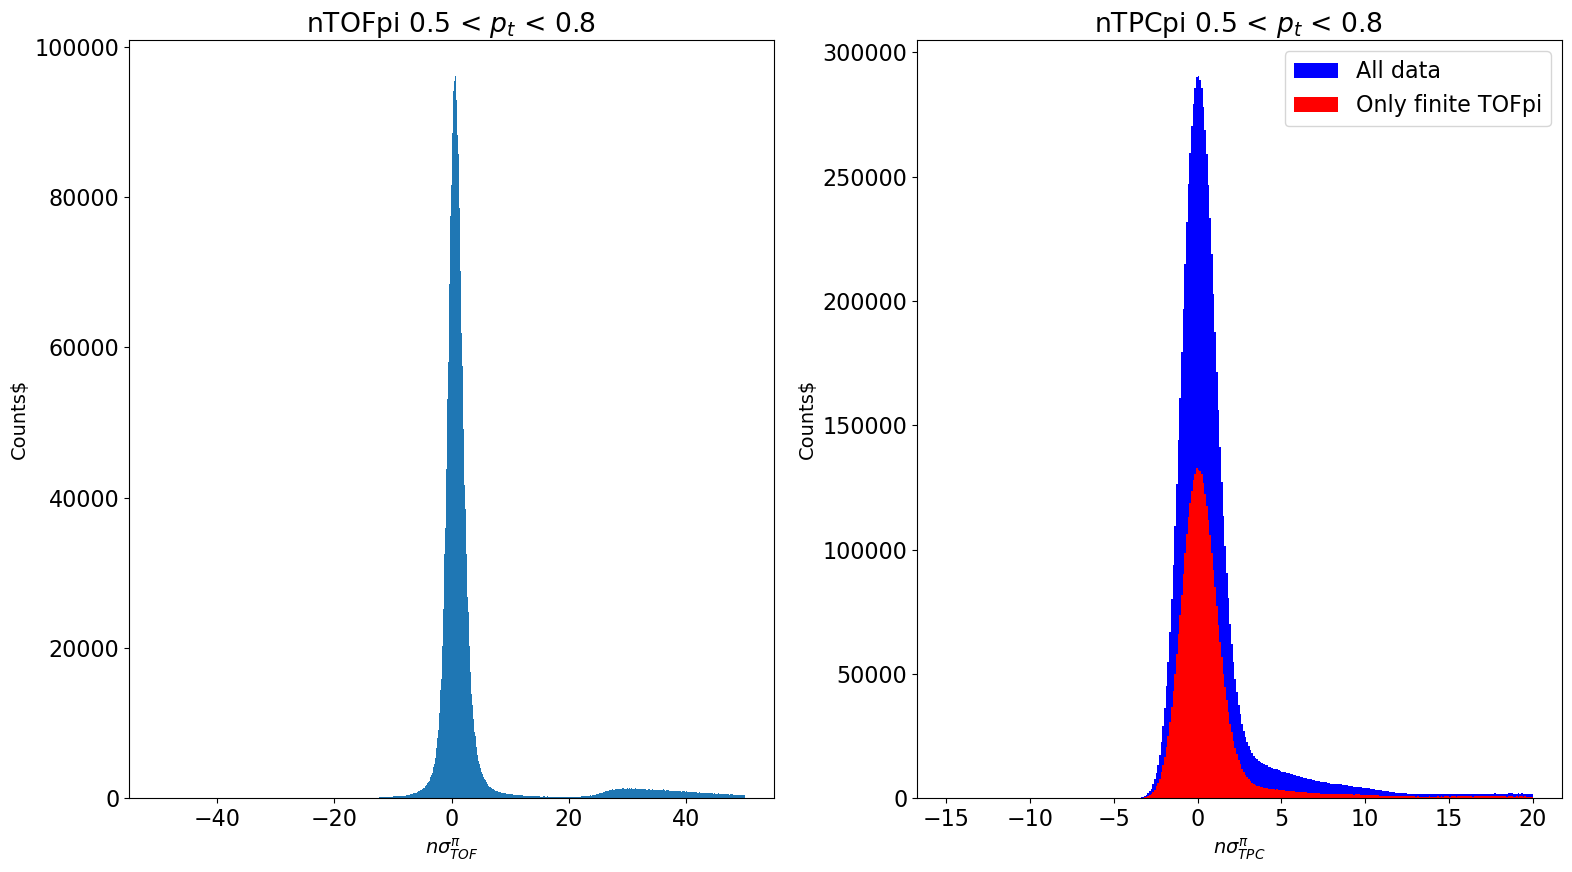

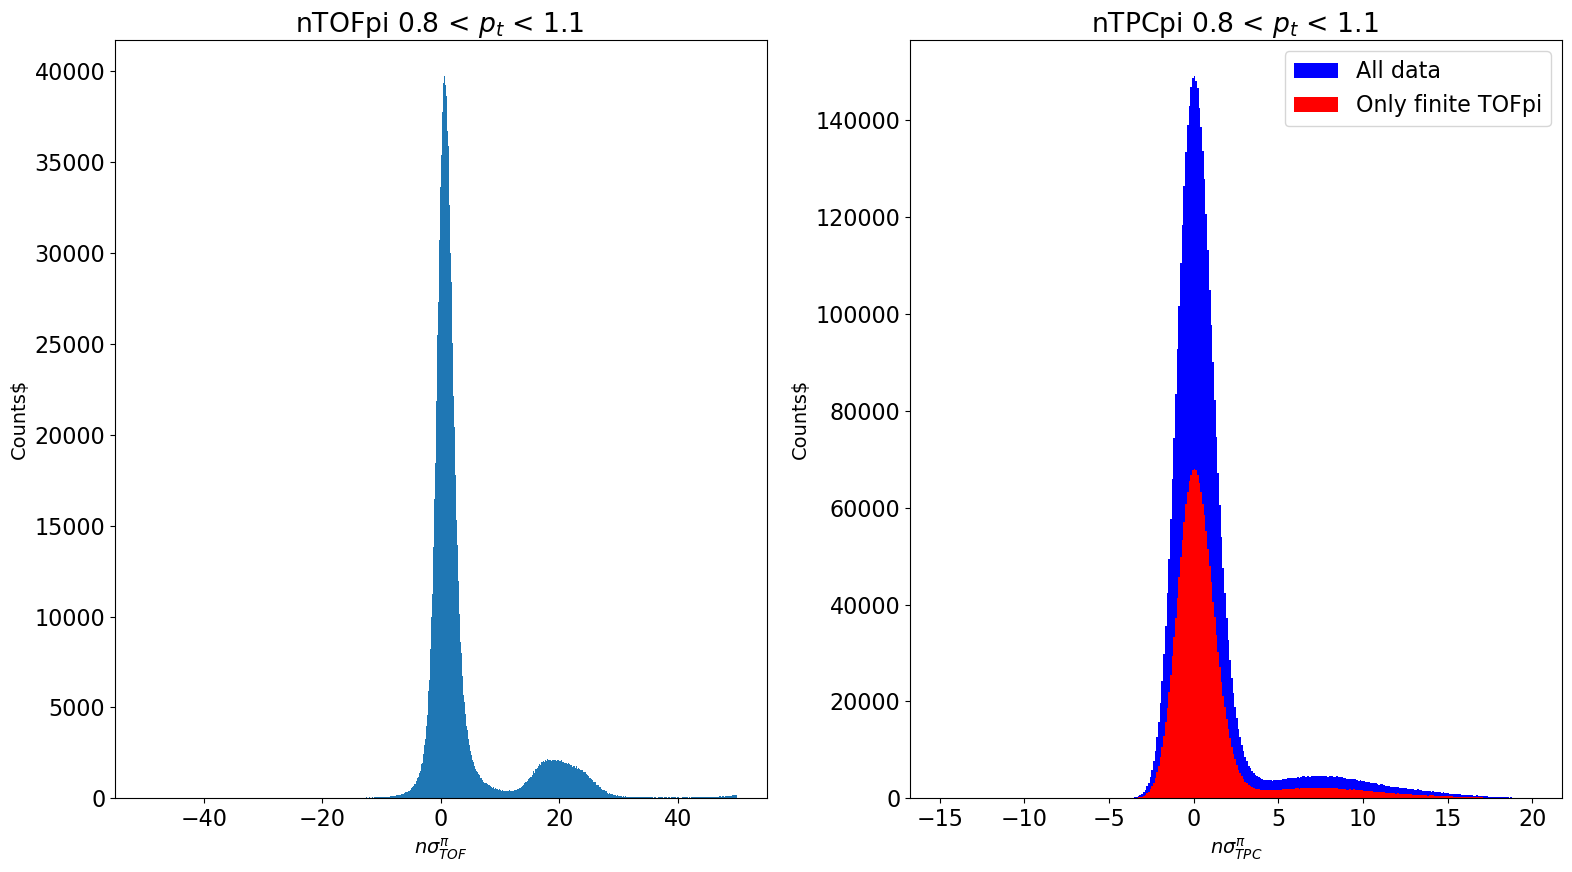

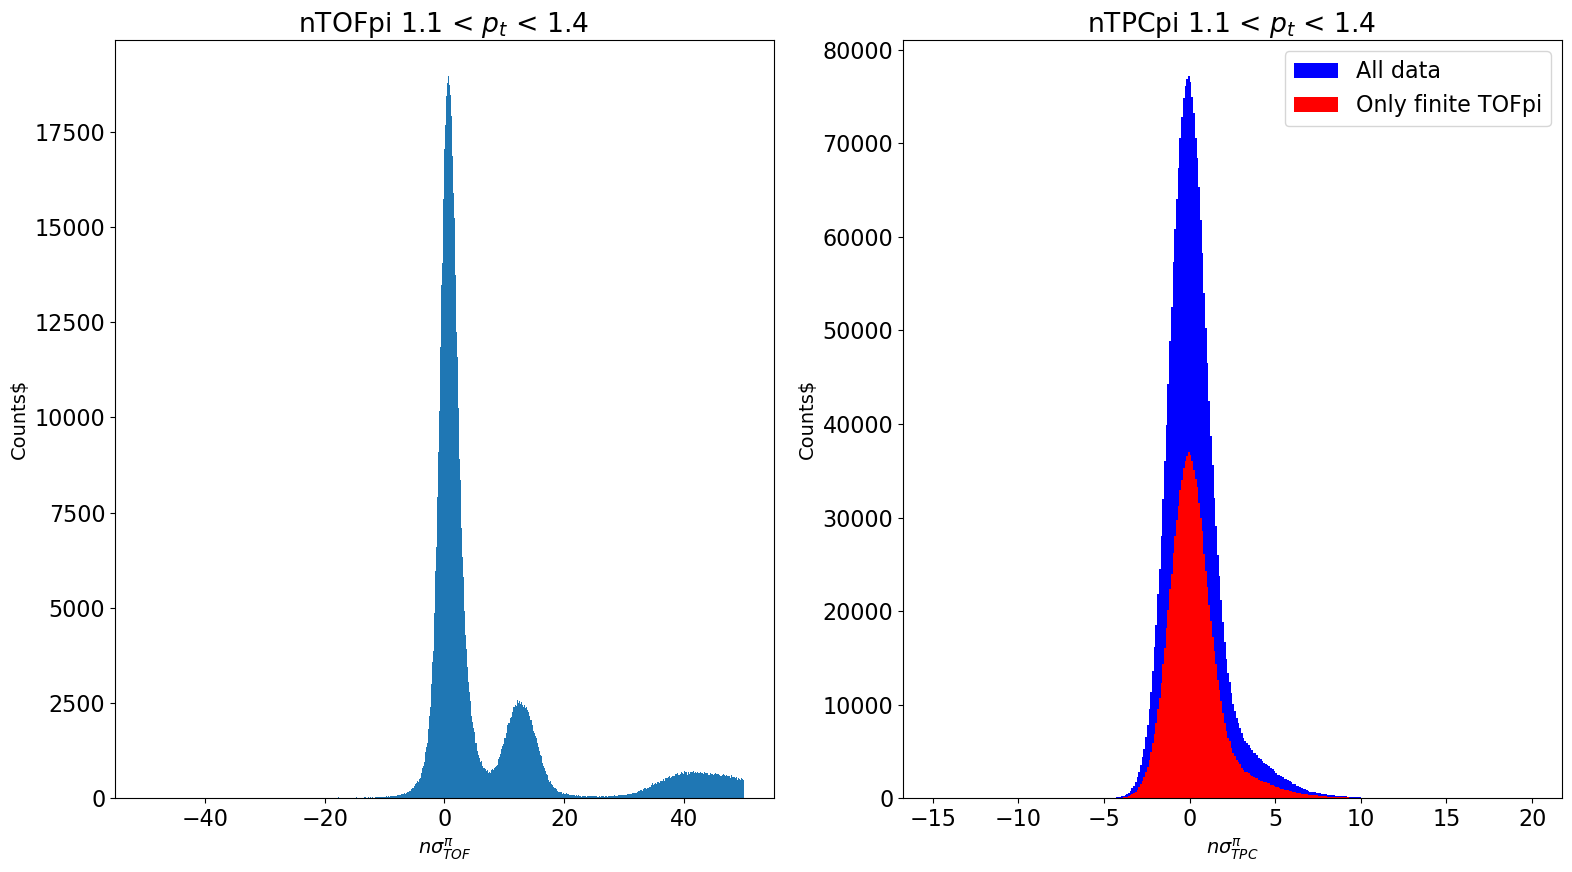

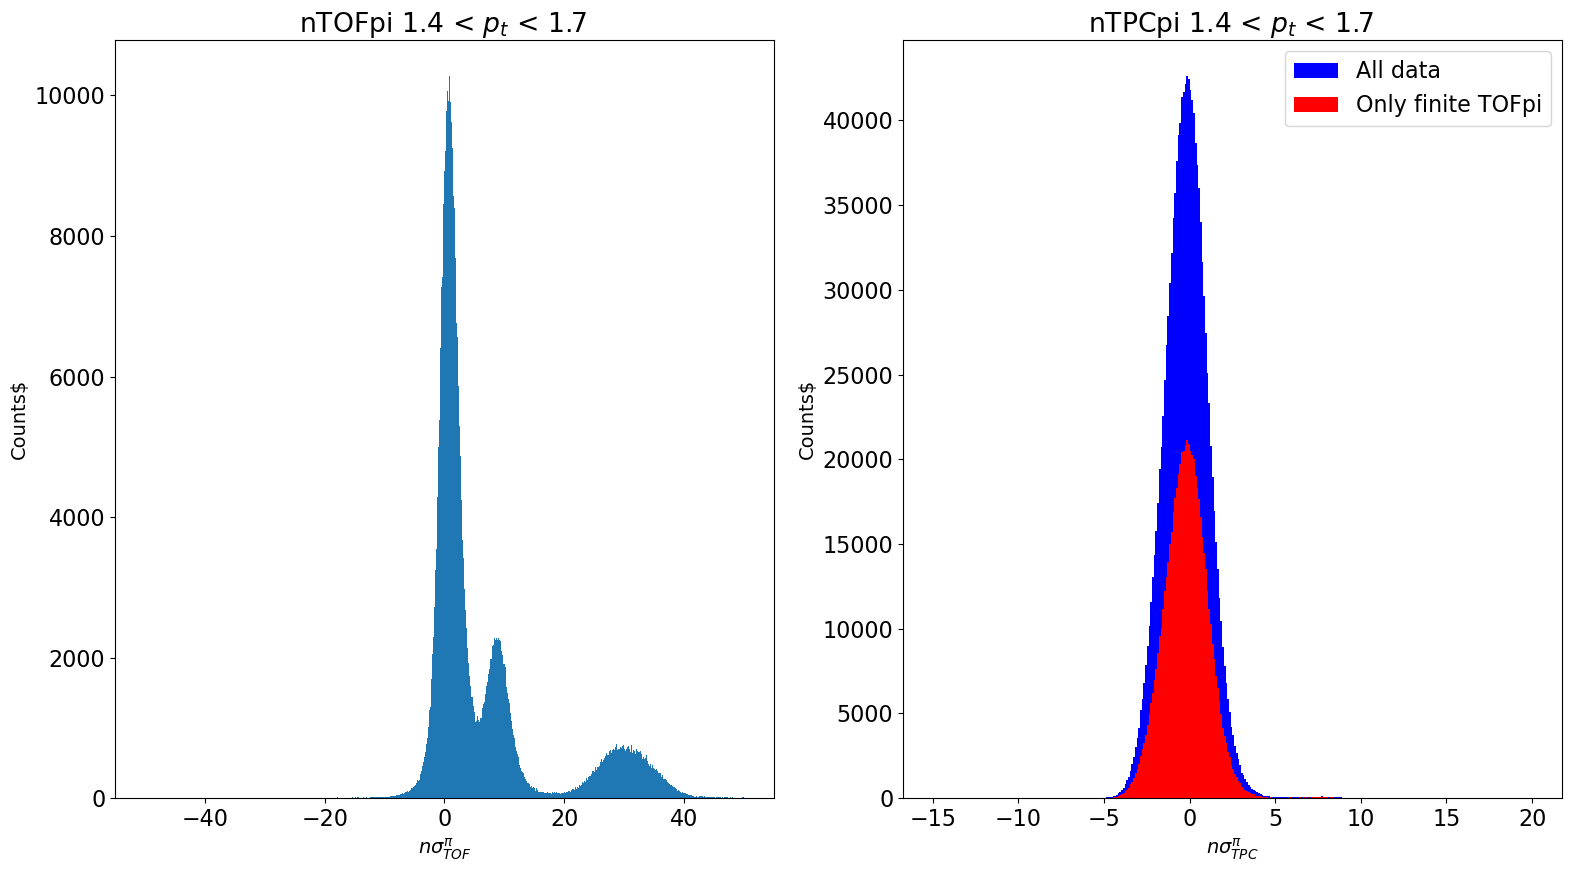

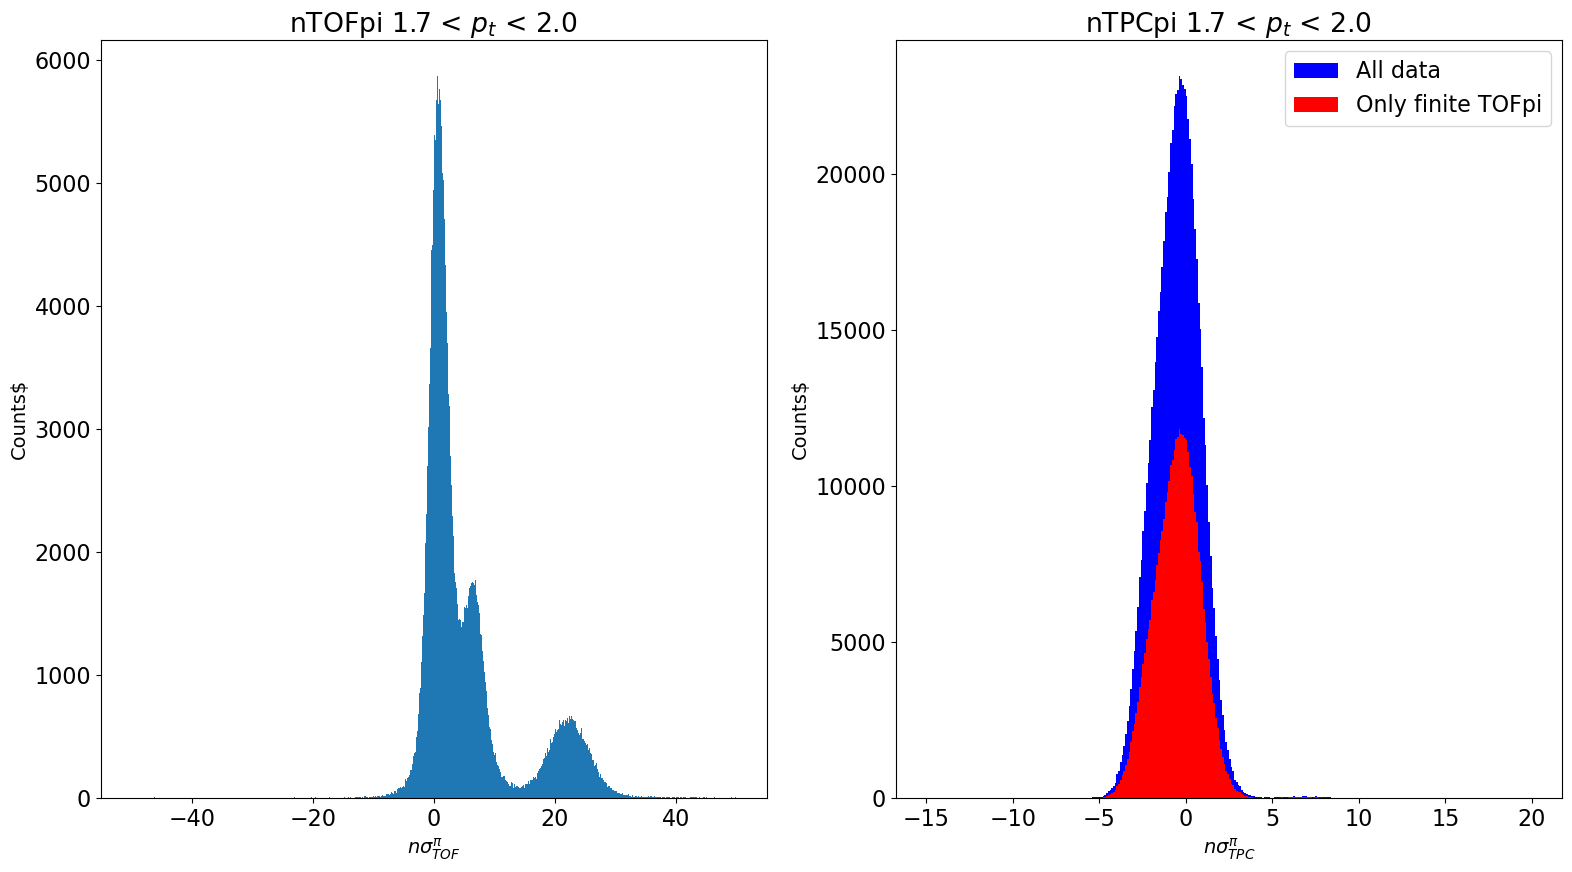

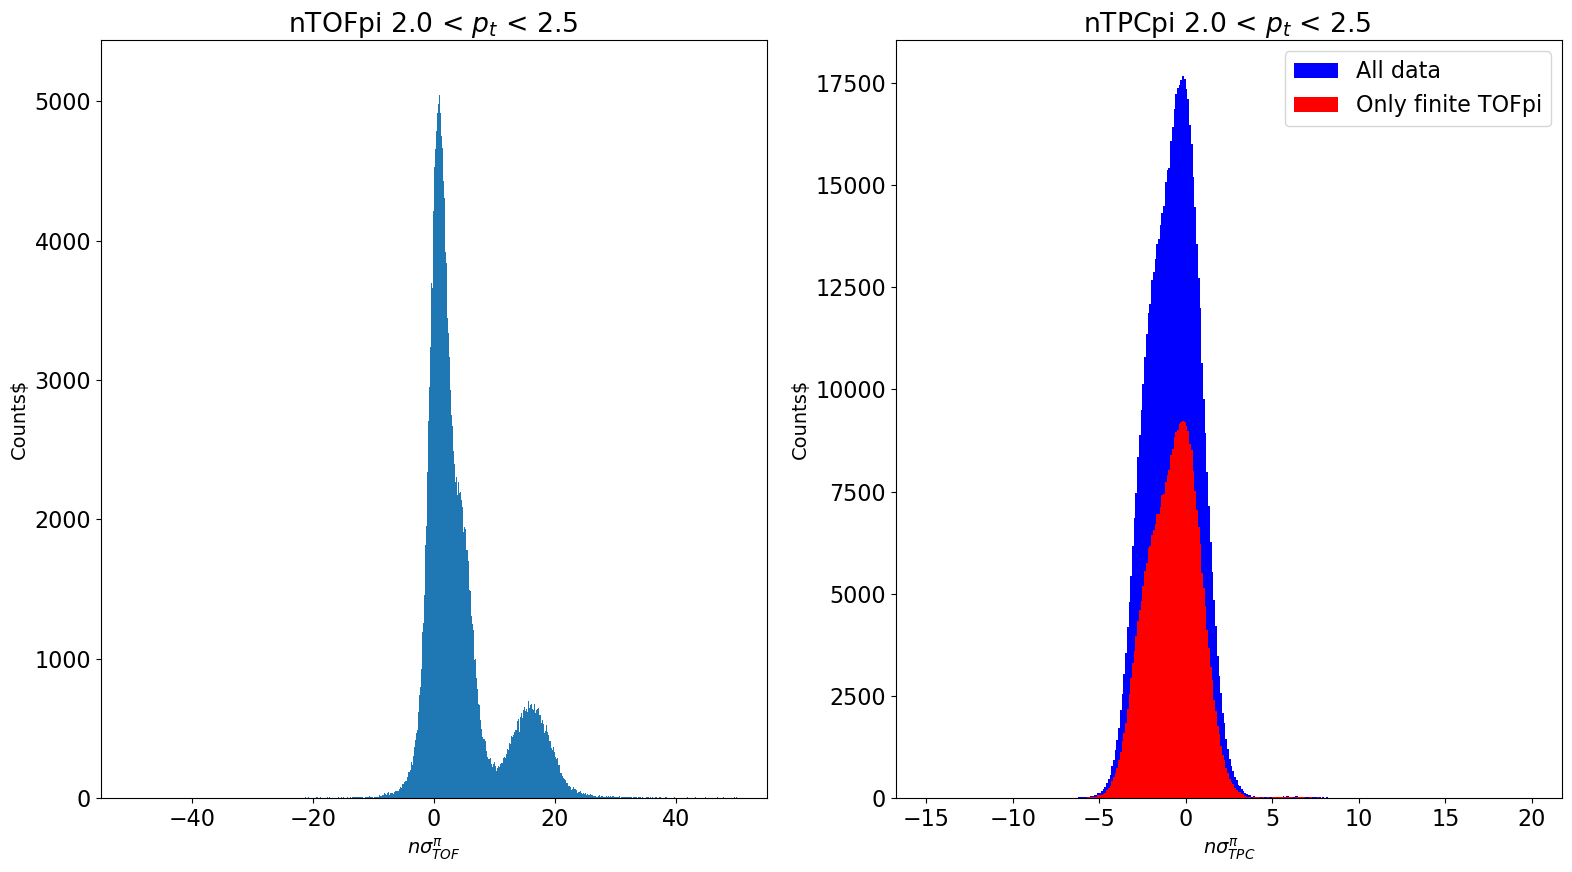

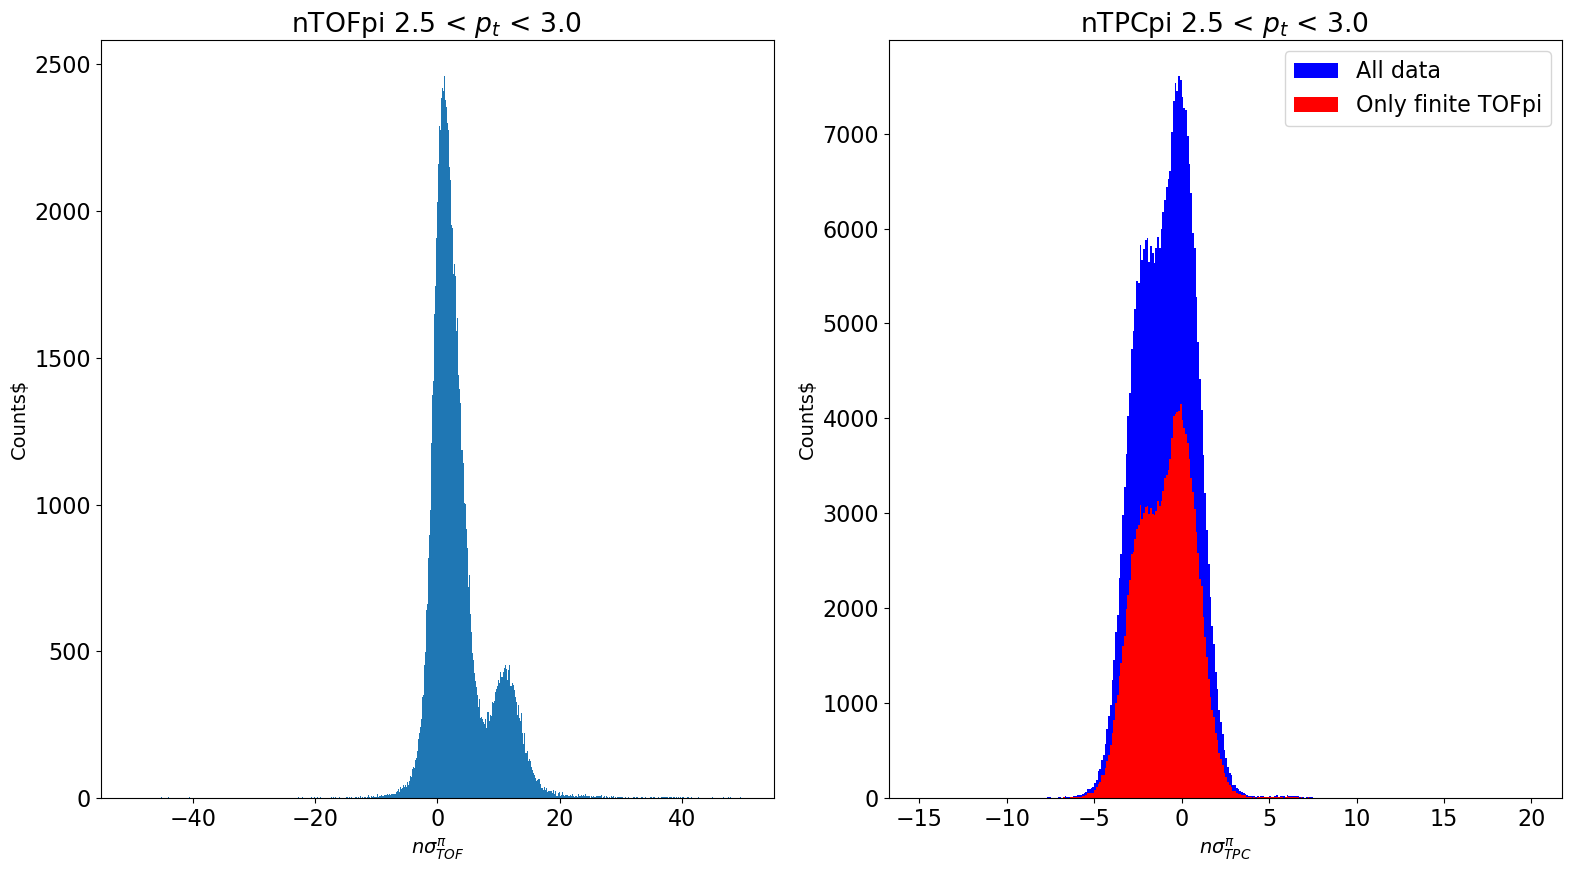

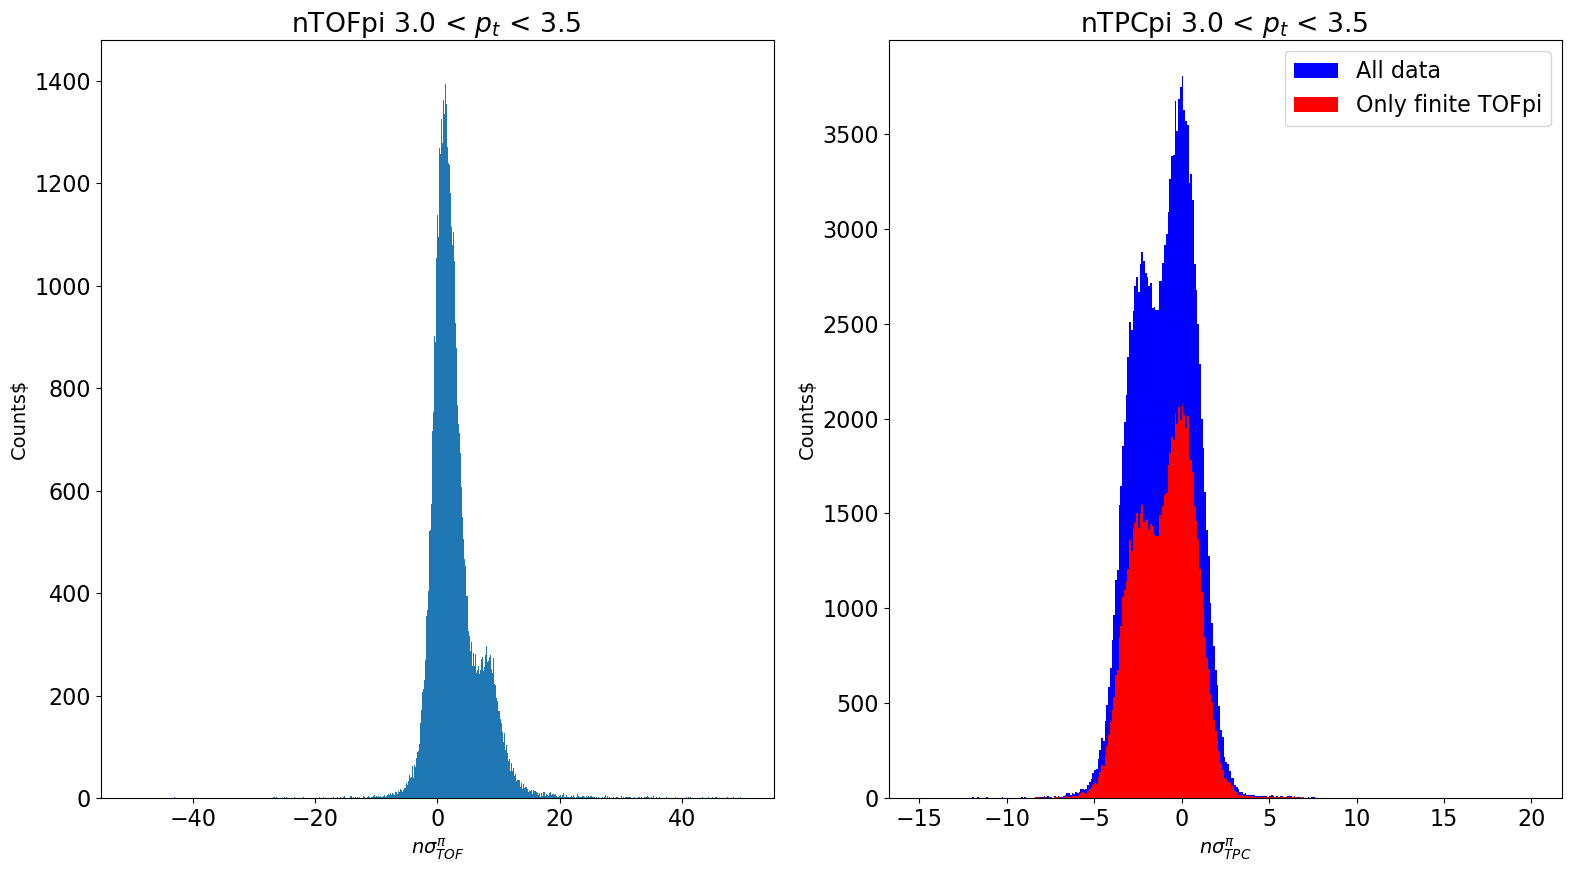

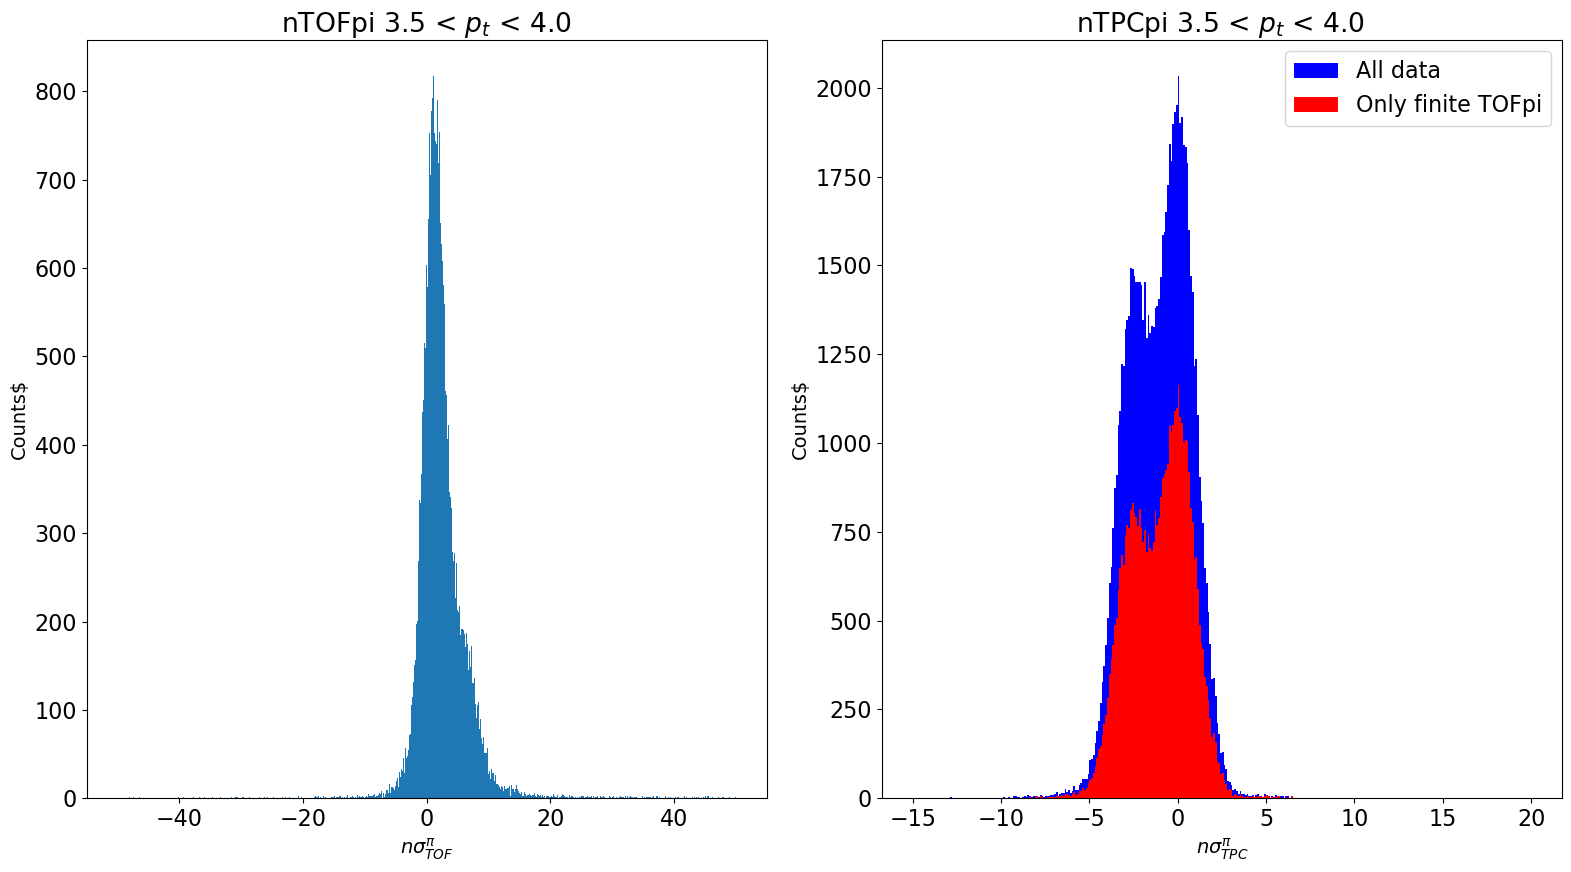

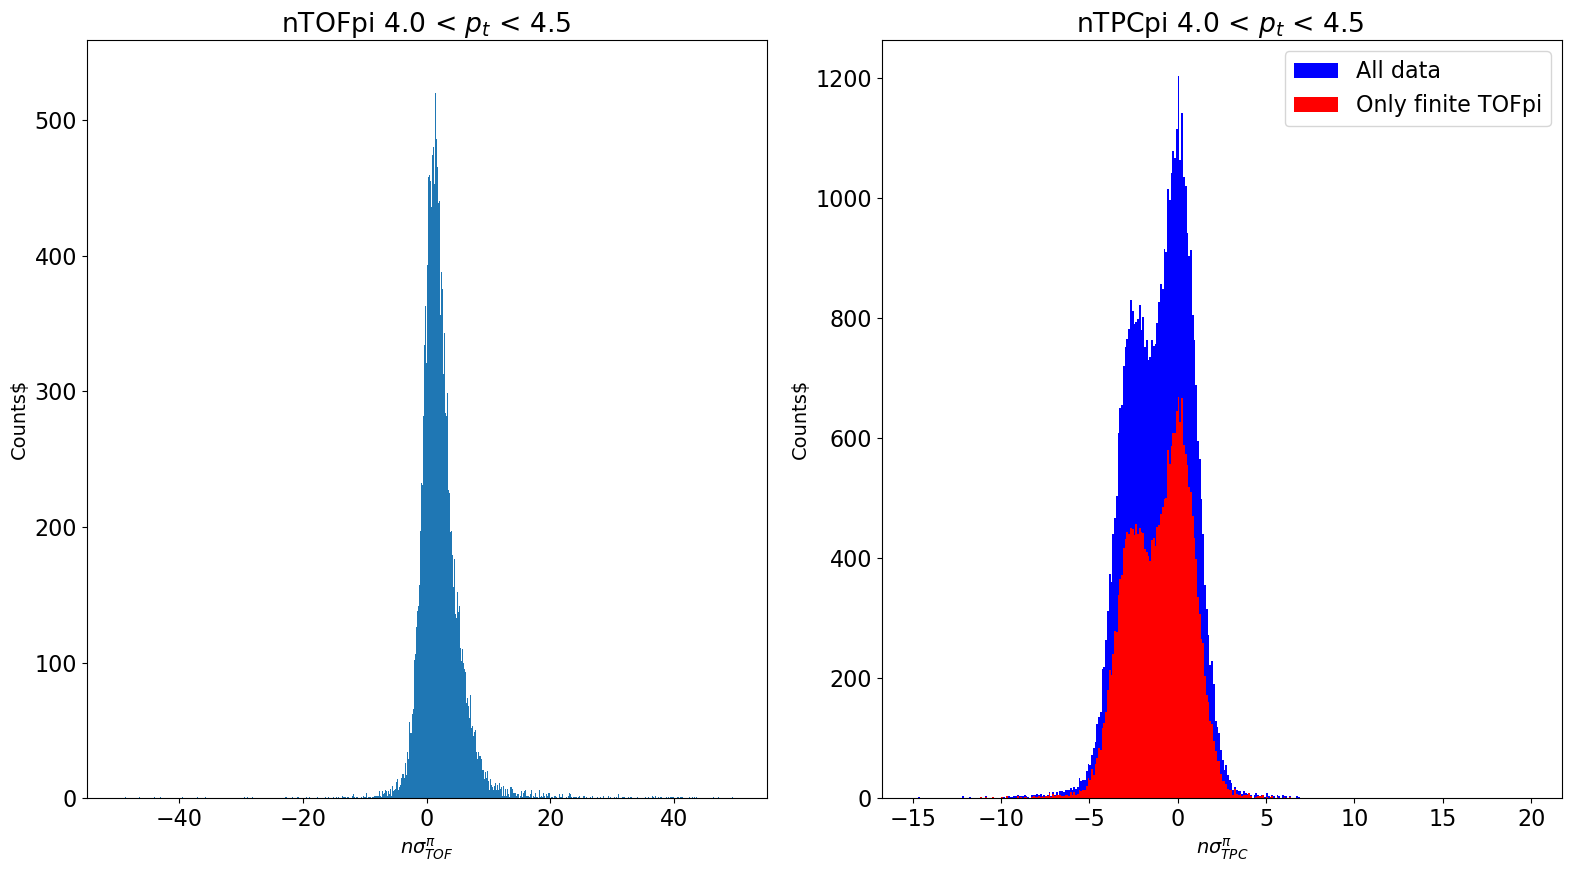

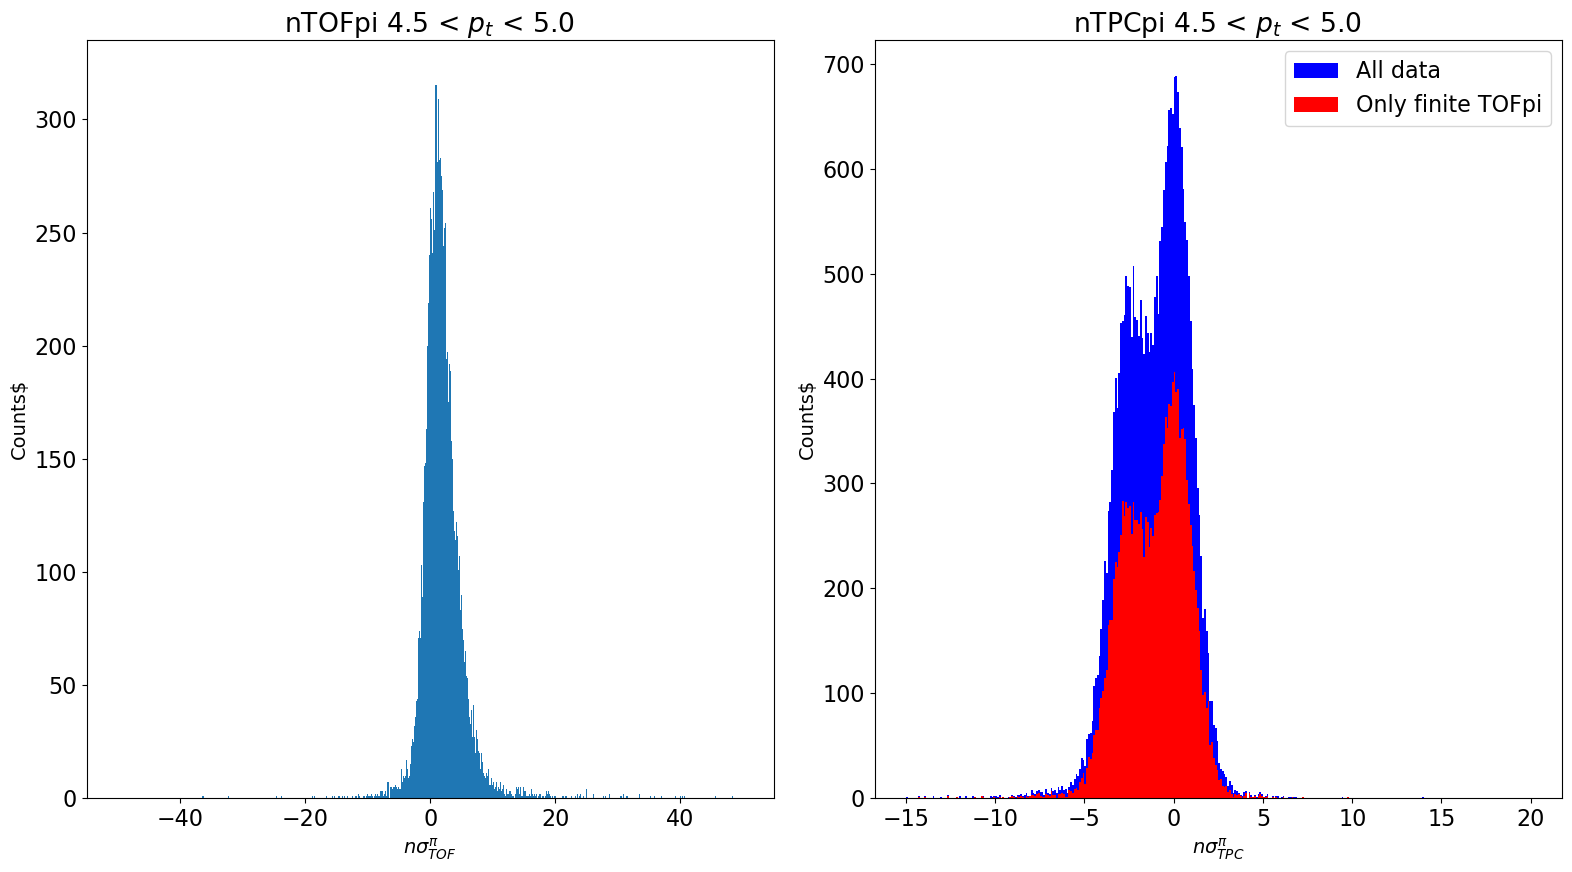

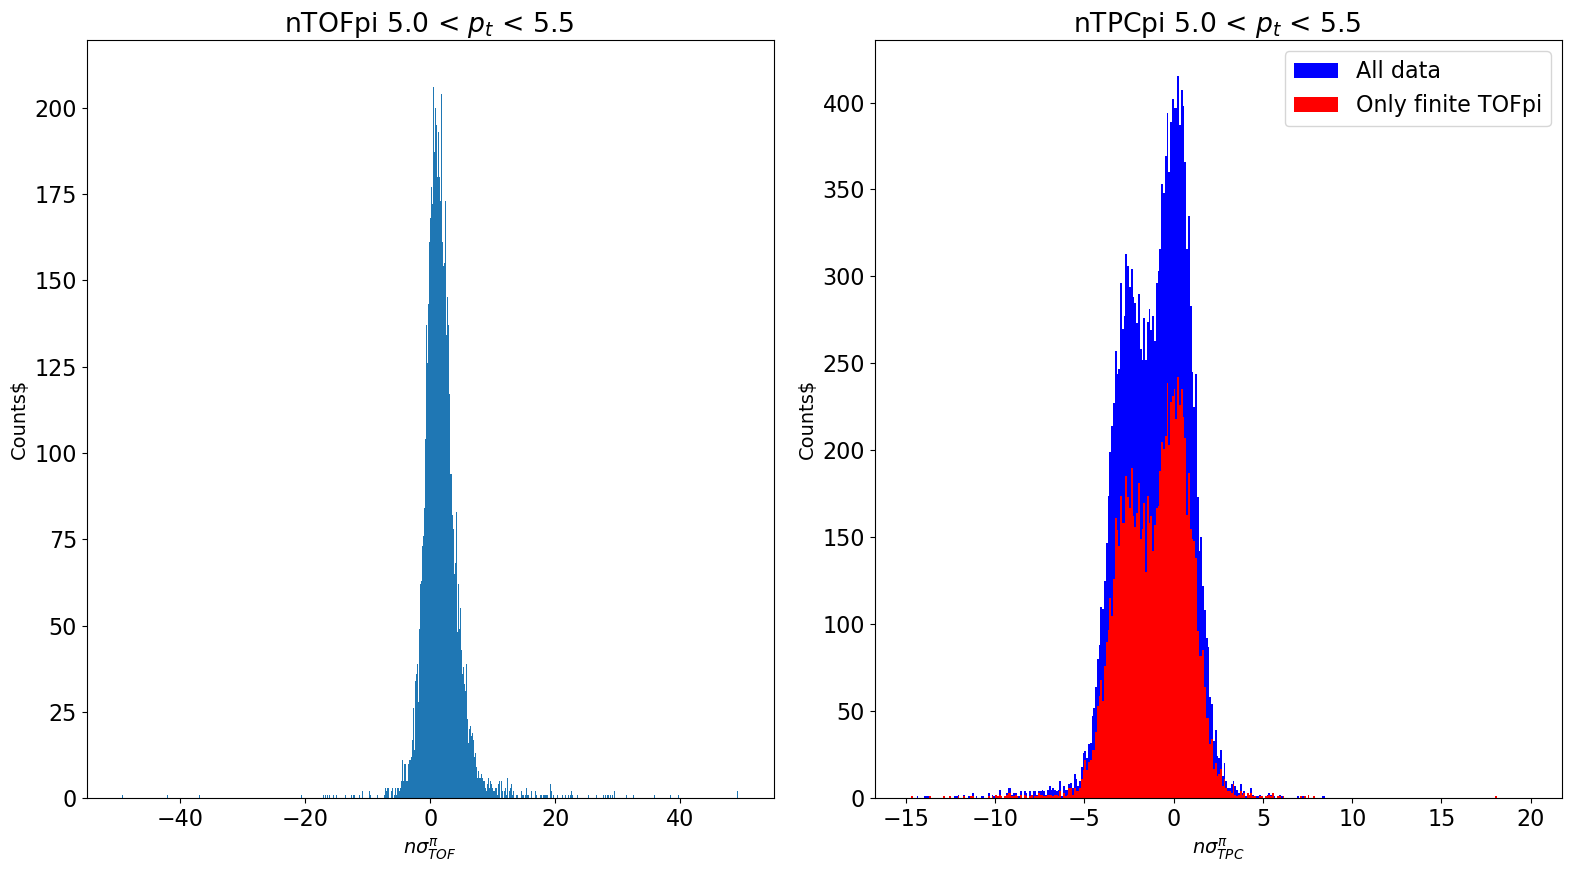

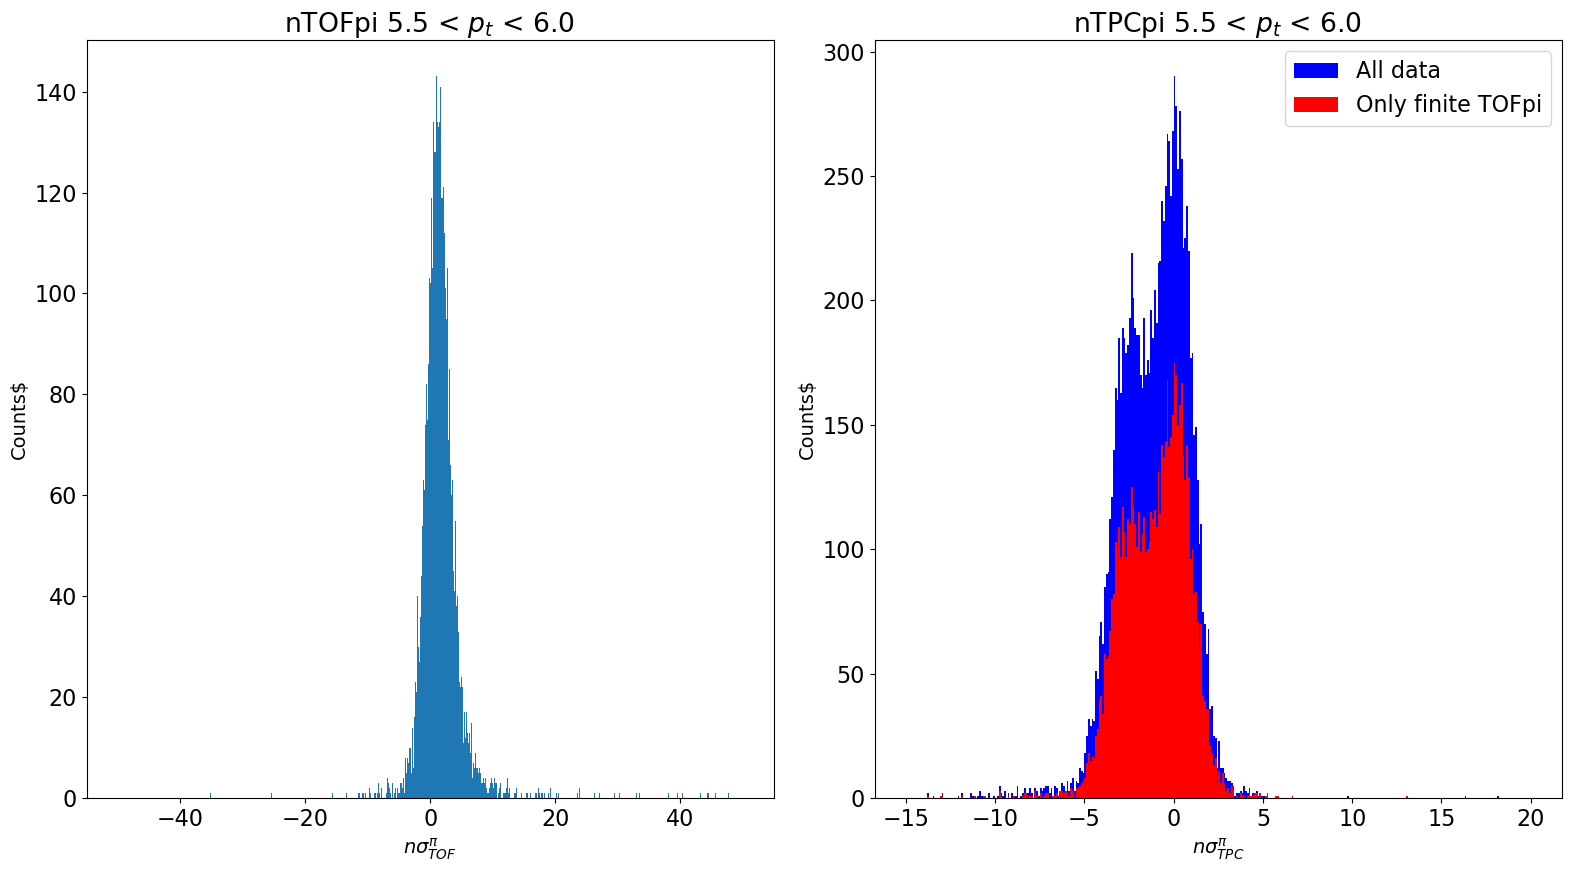

In [89]:
curr_item = 0
bin_width = 0.1
while (curr_item < len(pt_slices) ):
    data = real_data[ real_data["fPt"].between(pt_slices[curr_item][0], pt_slices[curr_item][1]) ][["fNsigmaTOFpi", "fNsigmaTPCpi"]]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,9))
    ax1.hist(data["fNsigmaTOFpi"], range=(-50,50), bins=np.arange(-50,50+bin_width, bin_width) )
    ax1.set_xlabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
    ax1.set_ylabel(r"Counts", fontsize=fs)
    ax1.set_title(f"nTOFpi {pt_slices[curr_item][0]} < $p_t$ < {pt_slices[curr_item][1]} ")
     
    ax2.hist(data["fNsigmaTPCpi"], range=(-15,20), bins=np.arange(-15,20+bin_width, bin_width), color="blue", label="All data")
    ax2.set_xlabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
    ax2.set_ylabel(r"Counts", fontsize=fs)
    ax2.set_title(f"nTPCpi {pt_slices[curr_item][0]} < $p_t$ < {pt_slices[curr_item][1]} ")

    # Does the TPCpi change if we only consider those with finite TOFpi?
    ax2.hist(data[data["fNsigmaTOFpi"]!=-999]["fNsigmaTPCpi"], range=(-15,20), bins=np.arange(-15,20+bin_width, bin_width), color="red", label="Only finite TOFpi")
    ax2.legend()
    
    curr_item += 1

    plt.tight_layout()
    plt.show()